<a href="https://colab.research.google.com/github/Hernandez484/01.01-PROYECTO-KAGGLE/blob/main/02_preprocesado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

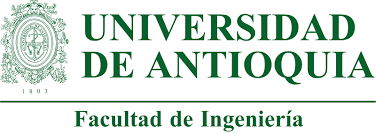

# <font color='056938'> **01.01 - PROYECTO KAGGLE - </font> <font color='8EC044'> Entrega 2** </font>

## <font color='157699'> **Paso 1:** </font>

In [4]:
!wget --no-cache -O init.py -q https://raw.githubusercontent.com/rramosp/ai4eng.v1/main/content/init.py
import init; init.init(force_download=False); init.get_weblink()

## <font color='157699'> **Paso 2: Descargar datos directamente desde Kaggle** </font>

- Se creo un archivo kaggle.jsoncon con mi token de autenticación (en kaggle $\to$ Hago clic en el icono de usuario en la parte superior derecha $\to$
ajustes $\to$ API crea un nuevo token);

- Subirlo a este espacio de trabajo del cuaderno;

- Y ejecutar la siguiente celda.

In [5]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '.'
!chmod 600 ./kaggle.json
!kaggle competitions download --force udea-ai-4-eng-20252-pruebas-saber-pro-colombia

  0% 0.00/29.9M [00:00<?, ?B/s]
100% 29.9M/29.9M [00:00<00:00, 206MB/s]


## <font color='157699'> **Paso 3: Descomprimir e inspeccionar datos** </font>

Se descomprime el fichero.

In [6]:
!unzip udea*.zip > /dev/null

replace submission_example.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


In [7]:
!wc *.csv

   296787    296787   4716673 submission_example.csv
   296787   4565553  59185238 test.csv
   692501  10666231 143732437 train.csv
  1286075  15528571 207634348 total


## <font color='157699'> **Paso 4: Se carga `train.csv` y `test.csv` con la librería `Pandas`** </font>

In [8]:
import pandas as pd
import numpy as np

z = pd.read_csv("train.csv")
print ("shape of loaded dataframe", z.shape)
x = pd.read_csv("test.csv")
print ("shape of loaded dataframe", x.shape)

shape of loaded dataframe (692500, 21)
shape of loaded dataframe (296786, 20)


Se muestran los primeros elementos del archivo de entrenamiento.

In [9]:
z.head()

,ID,PERIODO_ACADEMICO,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,...,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,F_EDUCACIONMADRE,RENDIMIENTO_GLOBAL,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
0,904256,20212,ENFERMERIA,BOGOTÁ,Entre 5.5 millones y menos de 7 millones,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica incompleta,Si,...,N,No,Si,Si,Postgrado,medio-alto,0.322,0.208,0.310,0.267
1,645256,20212,DERECHO,ATLANTICO,Entre 2.5 millones y menos de 4 millones,0,Estrato 3,No,Técnica o tecnológica completa,Si,...,N,No,Si,No,Técnica o tecnológica incompleta,bajo,0.311,0.215,0.292,0.264
2,308367,20203,MERCADEO Y PUBLICIDAD,BOGOTÁ,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Si,...,N,No,No,Si,Secundaria (Bachillerato) completa,bajo,0.297,0.214,0.305,0.264
3,470353,20195,ADMINISTRACION DE EMPRESAS,SANTANDER,Entre 4 millones y menos de 5.5 millones,0,Estrato 4,Si,No sabe,Si,...,N,No,Si,Si,Secundaria (Bachillerato) completa,alto,0.485,0.172,0.252,0.190
4,989032,20212,PSICOLOGIA,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 3,Si,Primaria completa,Si,...,N,No,Si,Si,Primaria completa,medio-bajo,0.316,0.232,0.285,0.294


Se muestran los primeros elementos del archivo de prueba.

In [10]:
x.head()

,ID,PERIODO_ACADEMICO,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,F_EDUCACIONMADRE,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
0,550236,20183,TRABAJO SOCIAL,BOLIVAR,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Si,No,N,Si,Si,Si,Primaria completa,0.328,0.219,0.317,0.247
1,98545,20203,ADMINISTRACION COMERCIAL Y DE MERCADEO,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Si,Técnica o tecnológica completa,0.227,0.283,0.296,0.324
2,499179,20212,INGENIERIA MECATRONICA,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Si,No,N,No,Si,Si,Secundaria (Bachillerato) completa,0.285,0.228,0.294,0.247
3,782980,20195,CONTADURIA PUBLICA,SUCRE,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Si,No,N,No,No,No,Primaria incompleta,0.160,0.408,0.217,0.294
4,785185,20212,ADMINISTRACION DE EMPRESAS,ATLANTICO,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Si,Secundaria (Bachillerato) completa,0.209,0.283,0.306,0.286


Se miran que datos faltantes hay por columna.

In [11]:
 z.isna().sum()
 x.isna().sum()

,0
ID,0
PERIODO_ACADEMICO,0
E_PRGM_ACADEMICO,0
E_PRGM_DEPARTAMENTO,0
E_VALORMATRICULAUNIVERSIDAD,2723
E_HORASSEMANATRABAJA,13379
F_ESTRATOVIVIENDA,13795
F_TIENEINTERNET,11539
F_EDUCACIONPADRE,9993
F_TIENELAVADORA,17259


Se reemplazan los datos faltantes por valores dependiendo de cada columna, así:

E_VALORMATRICULAUNIVERSIDAD = 'No sabe, No responde'

E_HORASSEMANATRABAJA = 'No sabe, No responde'

F_ESTRATOVIVIENDA = 'Sin Estrato'

F_TIENEINTERNET = 'No'

F_EDUCACIONPADRE = 'No Aplica'

F_TIENELAVADORA = 'No'

F_TIENEAUTOMOVIL = 'No'

E_PAGOMATRICULAPROPIO = 'No sabe, No responde'

F_TIENECOMPUTADOR = 'No'

F_TIENEINTERNET.1 = 'No'

F_EDUCACIONMADRE = 'No Aplica'

In [12]:
z['E_VALORMATRICULAUNIVERSIDAD'] = z['E_VALORMATRICULAUNIVERSIDAD'].fillna(value='No sabe, No responde')
z['E_HORASSEMANATRABAJA'] = z['E_HORASSEMANATRABAJA'].fillna(value='No sabe, No responde')
z['F_ESTRATOVIVIENDA'] = z['F_ESTRATOVIVIENDA'].fillna(value='Sin Estrato')
z['F_TIENEINTERNET'] = z['F_TIENEINTERNET'].fillna(value='No')
z['F_EDUCACIONPADRE'] = z['F_EDUCACIONPADRE'].fillna(value='No sabe')
z['F_TIENELAVADORA'] = z['F_TIENELAVADORA'].fillna(value='No')
z['F_TIENEAUTOMOVIL'] = z['F_TIENEAUTOMOVIL'].fillna(value='No')
z['E_PAGOMATRICULAPROPIO'] = z['E_PAGOMATRICULAPROPIO'].fillna(value='No sabe, No responde')
z['F_TIENECOMPUTADOR'] = z['F_TIENECOMPUTADOR'].fillna(value='No')
z['F_TIENEINTERNET.1'] = z['F_TIENEINTERNET.1'].fillna(value='No')
z['F_EDUCACIONMADRE'] = z['F_EDUCACIONMADRE'].fillna(value='No sabe')

x['E_VALORMATRICULAUNIVERSIDAD'] = x['E_VALORMATRICULAUNIVERSIDAD'].fillna(value='No sabe, No responde')
x['E_HORASSEMANATRABAJA'] = x['E_HORASSEMANATRABAJA'].fillna(value='No sabe, No responde')
x['F_ESTRATOVIVIENDA'] = x['F_ESTRATOVIVIENDA'].fillna(value='Sin Estrato')
x['F_TIENEINTERNET'] = x['F_TIENEINTERNET'].fillna(value='No')
x['F_EDUCACIONPADRE'] = x['F_EDUCACIONPADRE'].fillna(value='No sabe')
x['F_TIENELAVADORA'] = x['F_TIENELAVADORA'].fillna(value='No')
x['F_TIENEAUTOMOVIL'] = x['F_TIENEAUTOMOVIL'].fillna(value='No')
x['E_PAGOMATRICULAPROPIO'] = x['E_PAGOMATRICULAPROPIO'].fillna(value='No sabe, No responde')
x['F_TIENECOMPUTADOR'] = x['F_TIENECOMPUTADOR'].fillna(value='No')
x['F_TIENEINTERNET.1'] = x['F_TIENEINTERNET.1'].fillna(value='No')
x['F_EDUCACIONMADRE'] = x['F_EDUCACIONMADRE'].fillna(value='No sabe')

In [13]:
z.head()

,ID,PERIODO_ACADEMICO,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,...,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,F_EDUCACIONMADRE,RENDIMIENTO_GLOBAL,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
0,904256,20212,ENFERMERIA,BOGOTÁ,Entre 5.5 millones y menos de 7 millones,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica incompleta,Si,...,N,No,Si,Si,Postgrado,medio-alto,0.322,0.208,0.310,0.267
1,645256,20212,DERECHO,ATLANTICO,Entre 2.5 millones y menos de 4 millones,0,Estrato 3,No,Técnica o tecnológica completa,Si,...,N,No,Si,No,Técnica o tecnológica incompleta,bajo,0.311,0.215,0.292,0.264
2,308367,20203,MERCADEO Y PUBLICIDAD,BOGOTÁ,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Si,...,N,No,No,Si,Secundaria (Bachillerato) completa,bajo,0.297,0.214,0.305,0.264
3,470353,20195,ADMINISTRACION DE EMPRESAS,SANTANDER,Entre 4 millones y menos de 5.5 millones,0,Estrato 4,Si,No sabe,Si,...,N,No,Si,Si,Secundaria (Bachillerato) completa,alto,0.485,0.172,0.252,0.190
4,989032,20212,PSICOLOGIA,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 3,Si,Primaria completa,Si,...,N,No,Si,Si,Primaria completa,medio-bajo,0.316,0.232,0.285,0.294


In [14]:
z ['PERIODO_ACADEMICO'].unique()

array([20212, 20203, 20195, 20183, 20194, 20213, 20184, 20202, 20196])

Como en los dataframes se manejaron datos de tipo object, no pueden ser tratados estadisticamente como los datos tipo int, este ha sido un problema que he venido observando desde la Entrega #1. Por lo tanto, se ha decidido cambiar los tipos de datos, por ejemplo: estrato 3, cambiarlo por 3; en la columna "tiene internet" cambiar los SI por 1 y los NO por 0.

In [15]:
replace_map = {"Si": 1, "S": 1, "No": 0, "N": 0, "Estrato 1": 1, "Estrato 2": 2, "Estrato 3": 3, "Estrato 4": 4, "Estrato 5": 5, "Estrato 6": 6, "Sin Estrato":0,
                  "Menos de 10 horas": 1, "Entre 11 y 20 horas": 2, "Entre 21 y 30 horas": 3, "Más de 30 horas": 4, "No sabe, No responde": 0,
                  "No pagó matrícula": 0, "No Aplica": 0, "Menos de 500 mil": 1, "Entre 500 mil y menos de 1 millón": 2,
                  "Entre 1 millón y menos de 2.5 millones": 3,"Entre 2.5 millones y menos de 4 millones": 4, "Entre 4 millones y menos de 5.5 millones": 5,
                  "Entre 5.5 millones y menos de 7 millones": 6,"Más de 7 millones": 7, "Ninguno": 0, "No sabe": 0, "Primaria incompleta": 1,
                  "Primaria completa": 2, "Secundaria (Bachillerato) incompleta":3,"Secundaria (Bachillerato) completa": 4, "Técnica o tecnológica incompleta": 5,
                  "Técnica o tecnológica completa": 6,"Educación profesional incompleta": 7, "Educación professional completa": 8, "Postgrado": 9,
                  "bajo": 0, "medio-bajo": 1, "medio-alto": 2, "alto":3}

z = z.replace(replace_map)
x = x.replace(replace_map)

/tmp/ipython-input-955206924.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z = z.replace(replace_map)
/tmp/ipython-input-955206924.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x = x.replace(replace_map)


In [16]:
z ["RENDIMIENTO_GLOBAL"].unique()

array([2, 0, 3, 1])

In [17]:
z.head()

,ID,PERIODO_ACADEMICO,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,...,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,F_EDUCACIONMADRE,RENDIMIENTO_GLOBAL,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
0,904256,20212,ENFERMERIA,BOGOTÁ,6,1,3,1,5,1,...,0,0,1,1,9,2,0.322,0.208,0.310,0.267
1,645256,20212,DERECHO,ATLANTICO,4,0,3,0,6,1,...,0,0,1,0,5,0,0.311,0.215,0.292,0.264
2,308367,20203,MERCADEO Y PUBLICIDAD,BOGOTÁ,4,4,3,1,4,1,...,0,0,0,1,4,0,0.297,0.214,0.305,0.264
3,470353,20195,ADMINISTRACION DE EMPRESAS,SANTANDER,5,0,4,1,0,1,...,0,0,1,1,4,3,0.485,0.172,0.252,0.190
4,989032,20212,PSICOLOGIA,ANTIOQUIA,4,3,3,1,2,1,...,0,0,1,1,2,1,0.316,0.232,0.285,0.294


In [18]:
z.dtypes

,0
ID,int64
PERIODO_ACADEMICO,int64
E_PRGM_ACADEMICO,object
E_PRGM_DEPARTAMENTO,object
E_VALORMATRICULAUNIVERSIDAD,int64
E_HORASSEMANATRABAJA,object
F_ESTRATOVIVIENDA,int64
F_TIENEINTERNET,int64
F_EDUCACIONPADRE,object
F_TIENELAVADORA,int64


In [19]:
for i in range(0,len(z ['E_PRGM_DEPARTAMENTO'].unique())):
   z ['E_PRGM_DEPARTAMENTO'].replace({z ['E_PRGM_DEPARTAMENTO'].unique()[i]: i}, inplace=True)

/tmp/ipython-input-567469333.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  z ['E_PRGM_DEPARTAMENTO'].replace({z ['E_PRGM_DEPARTAMENTO'].unique()[i]: i}, inplace=True)
/tmp/ipython-input-567469333.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z ['E_PRGM_DEPARTAMENTO'].replace({z ['E_PRGM_

In [20]:
for i in range(0,len(x ['E_PRGM_DEPARTAMENTO'].unique())):
   x ['E_PRGM_DEPARTAMENTO'].replace({x ['E_PRGM_DEPARTAMENTO'].unique()[i]: i}, inplace=True)

/tmp/ipython-input-3341313663.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x ['E_PRGM_DEPARTAMENTO'].replace({x ['E_PRGM_DEPARTAMENTO'].unique()[i]: i}, inplace=True)
/tmp/ipython-input-3341313663.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x ['E_PRGM_DEPARTAMENTO'].replace({x ['E_PRG

In [21]:
for i in range(0,len(z ['E_PRGM_ACADEMICO'].unique())):
   z ['E_PRGM_ACADEMICO'].replace({z ['E_PRGM_ACADEMICO'].unique()[i]: i}, inplace=True)

/tmp/ipython-input-3833488150.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  z ['E_PRGM_ACADEMICO'].replace({z ['E_PRGM_ACADEMICO'].unique()[i]: i}, inplace=True)
/tmp/ipython-input-3833488150.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z ['E_PRGM_ACADEMICO'].replace({z ['E_PRGM_ACADEMI

In [22]:
for i in range(0,len(x ['E_PRGM_ACADEMICO'].unique())):
   x ['E_PRGM_ACADEMICO'].replace({x ['E_PRGM_ACADEMICO'].unique()[i]: i}, inplace=True)

/tmp/ipython-input-3717958580.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x ['E_PRGM_ACADEMICO'].replace({x ['E_PRGM_ACADEMICO'].unique()[i]: i}, inplace=True)
/tmp/ipython-input-3717958580.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x ['E_PRGM_ACADEMICO'].replace({x ['E_PRGM_ACADEMI

In [23]:
z.head(10)

,ID,PERIODO_ACADEMICO,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,...,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,F_EDUCACIONMADRE,RENDIMIENTO_GLOBAL,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
0,904256,20212,0,0,6,1,3,1,5,1,...,0,0,1,1,9,2,0.322,0.208,0.310,0.267
1,645256,20212,1,1,4,0,3,0,6,1,...,0,0,1,0,5,0,0.311,0.215,0.292,0.264
2,308367,20203,2,0,4,4,3,1,4,1,...,0,0,0,1,4,0,0.297,0.214,0.305,0.264
3,470353,20195,3,2,5,0,4,1,0,1,...,0,0,1,1,4,3,0.485,0.172,0.252,0.190
4,989032,20212,4,3,4,3,3,1,2,1,...,0,0,1,1,2,1,0.316,0.232,0.285,0.294
5,659872,20203,5,3,7,1,5,1,Educación profesional completa,1,...,0,0,1,1,4,2,0.553,0.142,0.248,0.175
6,47159,20183,6,4,4,3,2,1,7,1,...,0,1,1,1,6,3,0.242,0.299,0.267,0.308
7,11829,20183,7,0,3,2,2,1,1,1,...,0,1,0,1,3,1,0.238,0.316,0.286,0.290
8,257869,20212,8,1,6,1,1,1,4,1,...,0,1,1,1,7,1,0.147,0.407,0.212,0.328
9,465511,20183,3,3,4,4,5,1,9,1,...,0,1,1,1,9,3,0.535,0.122,0.257,0.167


In [24]:
x.head(10)

,ID,PERIODO_ACADEMICO,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,F_EDUCACIONMADRE,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
0,550236,20183,0,0,1,1,3,1,6,1,0,0,1,1,1,2,0.328,0.219,0.317,0.247
1,98545,20203,1,1,4,3,2,1,4,1,0,0,0,1,1,6,0.227,0.283,0.296,0.324
2,499179,20212,2,2,3,0,3,1,3,1,0,0,0,1,1,4,0.285,0.228,0.294,0.247
3,782980,20195,3,3,3,3,1,0,1,1,0,0,0,0,0,1,0.160,0.408,0.217,0.294
4,785185,20212,4,4,4,2,2,1,4,1,0,0,0,1,1,4,0.209,0.283,0.306,0.286
5,58495,20183,5,5,2,4,1,1,0,1,0,0,1,1,1,4,0.132,0.396,0.239,0.297
6,705444,20195,6,6,1,0,3,1,2,1,1,0,0,1,1,6,0.307,0.229,0.275,0.276
7,557548,20183,7,2,7,1,4,1,9,1,1,0,0,1,1,9,0.469,0.169,0.298,0.214
8,519909,20195,8,4,3,3,2,0,4,1,0,0,0,1,0,4,0.202,0.298,0.290,0.281
9,832058,20183,9,2,2,3,2,1,6,1,0,0,0,1,1,3,0.212,0.272,0.302,0.309


In [25]:
for col in ['E_PRGM_ACADEMICO', 'E_PRGM_DEPARTAMENTO', 'E_VALORMATRICULAUNIVERSIDAD', 'E_HORASSEMANATRABAJA', 'F_ESTRATOVIVIENDA', 'F_TIENEINTERNET', 'F_EDUCACIONPADRE', 'F_TIENELAVADORA', 'F_TIENEAUTOMOVIL', 'E_PAGOMATRICULAPROPIO', 'F_TIENECOMPUTADOR', 'F_TIENEINTERNET.1', 'F_EDUCACIONMADRE']:
    z[col] = pd.to_numeric(z[col], errors='coerce')
    x[col] = pd.to_numeric(x[col], errors='coerce')

Se importan las librerías necesarias para realizar el algoritmo de clasificación.

In [26]:
from sklearn.naive_bayes import MultinomialNB,GaussianNB,BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

Se realizan diferentes modelos con las librerías previamente incluídas para conocer su exactitud, precisión, memoria y la puntuación.

In [27]:
def classification_(X,y):
    g=GaussianNB()
    b=BernoulliNB()
    k=KNeighborsClassifier()
    svc=SVC()
    d=DecisionTreeClassifier()
    log=LogisticRegression()
    gbc=GradientBoostingClassifier()
    rf=RandomForestClassifier()
    ab=AdaBoostClassifier()

    x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)
    algos=[g,b,k,svc,d,log,gbc,rf,ab]
    algos_name=['Gaussian','Bernoulli','KNeigbors','SVC','DecisionTree','LogisticRegr','GradientBoosting','RandomForest','AdaBoost']
    accuracy = []
    precision = []
    recall = []
    f1 = []
    result=pd.DataFrame(columns=['AccuracyScore','PrecisionScore','RecallScore','f1_Score'],index=algos_name)
    for i in algos:
        predict=i.fit(x_train,y_train).predict(x_test)
        accuracy.append(accuracy_score(y_test,predict))
        precision.append(precision_score(y_test,predict,average='micro'))
        recall.append(recall_score(y_test,predict,average='micro'))
        f1.append(f1_score(y_test,predict,average='micro'))
    result.AccuracyScore=accuracy
    result.PrecisionScore=precision
    result.RecallScore=recall
    result.f1_Score=f1
    return result.sort_values('f1_Score',ascending=False)

Para evitar errores, cada que se haga un algoritmo de clasificación se leerá de nuevo el archivo, esto no consume memoria considerable y ayudar a que el algoritmo sea más preciso a la hora de dar sus resultados.

In [28]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

# 0) Relee el archivo (como querías)
z = pd.read_csv("train.csv")
x = z.drop(["ID","RENDIMIENTO_GLOBAL"], axis=1)
y = z["RENDIMIENTO_GLOBAL"]

# 1) Replace de etiquetas → numérico donde aplica
replace_map = {
    "Si":1, "S":1, "No":0, "N":0,
    "Estrato 1":1,"Estrato 2":2,"Estrato 3":3,"Estrato 4":4,"Estrato 5":5,"Estrato 6":6,"Sin Estrato":0,
    "Menos de 10 horas":1,"Entre 11 y 20 horas":2,"Entre 21 y 30 horas":3,"Más de 30 horas":4,"No sabe, No responde":0,
    "No pagó matrícula":0,"No Aplica":0,"Menos de 500 mil":1,"Entre 500 mil y menos de 1 millón":2,
    "Entre 1 millón y menos de 2.5 millones":3,"Entre 2.5 millones y menos de 4 millones":4,"Entre 4 millones y menos de 5.5 millones":5,
    "Entre 5.5 millones y menos de 7 millones":6,"Más de 7 millones":7,"Ninguno":0,"No sabe":0,
    "Primaria incompleta":1,"Primaria completa":2,"Secundaria (Bachillerato) incompleta":3,"Secundaria (Bachillerato) completa":4,
    "Técnica o tecnológica incompleta":5,"Técnica o tecnológica completa":6,
    "Educación profesional incompleta":7,"Educación professional completa":8,"Postgrado":9,
    "bajo":0,"medio-bajo":1,"medio-alto":2,"alto":3
}

x = x.replace(replace_map).infer_objects(copy=False)
y = y.replace(replace_map).infer_objects(copy=False)

# 2) Convierte a numérico solo donde procede y exista
maybe_numeric = [
    'E_PRGM_ACADEMICO','E_PRGM_DEPARTAMENTO','E_VALORMATRICULAUNIVERSIDAD',
    'E_HORASSEMANATRABAJA','F_ESTRATOVIVIENDA','F_TIENEINTERNET','F_EDUCACIONPADRE',
    'F_TIENELAVADORA','F_TIENEAUTOMOVIL','E_PAGOMATRICULAPROPIO','F_TIENECOMPUTADOR',
    'F_TIENEINTERNET.1','F_EDUCACIONMADRE'
]
for col in maybe_numeric:
    if col in x.columns:
        x[col] = pd.to_numeric(x[col], errors='coerce')

# 3) Parche anti-“skip”: columnas totalmente NaN → codifícalas como 0 (missing)
all_nan_cols = x.columns[x.isna().all()]
if len(all_nan_cols) > 0:
    # puedes usar otro código (p.ej., -1) si te conviene más
    x[all_nan_cols] = 0

# 4) Imputa “most_frequent” sin cambiar el nº de columnas
imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
x.loc[:, :] = imputer.fit_transform(x)

# Confirmar integridad:
print(x.shape, "← columnas:", list(x.columns))

/tmp/ipython-input-2897350757.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x = x.replace(replace_map).infer_objects(copy=False)
/tmp/ipython-input-2897350757.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace(replace_map).infer_objects(copy=False)


(692500, 19) ← columnas: ['PERIODO_ACADEMICO', 'E_PRGM_ACADEMICO', 'E_PRGM_DEPARTAMENTO', 'E_VALORMATRICULAUNIVERSIDAD', 'E_HORASSEMANATRABAJA', 'F_ESTRATOVIVIENDA', 'F_TIENEINTERNET', 'F_EDUCACIONPADRE', 'F_TIENELAVADORA', 'F_TIENEAUTOMOVIL', 'E_PRIVADO_LIBERTAD', 'E_PAGOMATRICULAPROPIO', 'F_TIENECOMPUTADOR', 'F_TIENEINTERNET.1', 'F_EDUCACIONMADRE', 'INDICADOR_1', 'INDICADOR_2', 'INDICADOR_3', 'INDICADOR_4']


Se imprime un dataframe con los 9 tipos de clasificadores y sus caracteríasticas.

In [29]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def _safe_encode_y(y):
    y_series = pd.Series(y).copy()
    # Si no es numérica, la codificamos
    if not np.issubdtype(y_series.dtype, np.number):
        le = LabelEncoder()
        y_enc = le.fit_transform(y_series.astype(str).str.strip())
        return y_enc, le
    return y_series.to_numpy(), None

def classification_(X, y, test_size=0.2, random_state=42, cv=5, verbose=True):
    # Asegura DataFrame/Series
    X = pd.DataFrame(X).copy()
    # Normaliza espacios en columnas categóricas para evitar tokens duplicados por espacios
    for col in X.select_dtypes(include=['object', 'string']).columns:
        X[col] = X[col].astype(str).str.strip()

    y_enc, y_encoder = _safe_encode_y(y)

    # Selectores por tipo
    num_selector = selector(dtype_include=np.number)
    cat_selector = selector(dtype_exclude=np.number)

    # Preprocesamiento
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
    pre = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, num_selector),
            ("cat", categorical_pipeline, cat_selector),
        ],
        remainder="drop"
    )

    # Clasificadores (9)
    models = {
        "LogisticRegression": LogisticRegression(max_iter=2000, n_jobs=None),
        "LinearSVC": LinearSVC(),
        "SVC_RBF": SVC(kernel="rbf", probability=True),
        "KNeighbors": KNeighborsClassifier(),
        "DecisionTree": DecisionTreeClassifier(random_state=random_state),
        "RandomForest": RandomForestClassifier(n_estimators=300, random_state=random_state, n_jobs=-1),
        "GradientBoosting": GradientBoostingClassifier(random_state=random_state),
        "AdaBoost": AdaBoostClassifier(random_state=random_state),
        "GaussianNB": GaussianNB(),  # requiere denso: OK porque OHE es denso
        # Si prefieres MLP en lugar de alguno, sustituye:
        # "MLP": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300, random_state=random_state)
    }

    rows = []
    fitted = {}

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=test_size, random_state=random_state, stratify=y_enc
    )

    # Para GaussianNB necesitamos forzar denso también en numéricas (ya lo es)
    for name, clf in models.items():
        pipe = Pipeline([
            ("pre", pre),
            ("clf", clf)
        ])

        pipe.fit(X_train, y_train)
        fitted[name] = pipe

        # Predicciones y probabilidades si aplica
        y_pred = pipe.predict(X_test)

        # proba/decision
        proba_ok = hasattr(pipe.named_steps["clf"], "predict_proba")
        decision_ok = hasattr(pipe.named_steps["clf"], "decision_function")

        acc = accuracy_score(y_test, y_pred)
        f1m = f1_score(y_test, y_pred, average="macro")

        # AUC solo si binario y tenemos proba o decision_function
        try:
            if len(np.unique(y_enc)) == 2:
                if proba_ok:
                    auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
                elif decision_ok:
                    scores = pipe.decision_function(X_test)
                    # si devuelve una sola dimensión en binario, listo
                    auc = roc_auc_score(y_test, scores)
                else:
                    auc = np.nan
            else:
                auc = np.nan
        except Exception:
            auc = np.nan

        # CV rápido (accuracy) para estabilidad
        try:
            cv_acc = cross_val_score(pipe, X, y_enc, cv=cv, scoring="accuracy", n_jobs=-1).mean()
        except Exception:
            cv_acc = np.nan

        # “Características” high-level
        characteristics = []
        if name in ("LogisticRegression", "LinearSVC"):
            characteristics += ["lineal", "rápido"]
        if name in ("SVC_RBF", "KNeighbors", "DecisionTree", "RandomForest", "GradientBoosting", "AdaBoost", "MLPClassifier"):
            characteristics += ["no lineal"]
        if name in ("RandomForest", "GradientBoosting", "AdaBoost"):
            characteristics += ["ensemble"]
        if proba_ok:
            characteristics += ["probabilidades"]
        if name in ("DecisionTree", "RandomForest", "GradientBoosting", "AdaBoost"):
            characteristics += ["importancias"]
        if name == "GaussianNB":
            characteristics += ["ingenua", "rápido", "probabilidades"]
        char_str = ", ".join(characteristics) if characteristics else "-"

        rows.append({
            "Modelo": name,
            "Accuracy(Test)": round(acc, 4),
            "F1-macro(Test)": round(f1m, 4),
            "ROC-AUC(Test)": (round(auc, 4) if not np.isnan(auc) else np.nan),
            f"CV{cv}-Acc": (round(cv_acc, 4) if not np.isnan(cv_acc) else np.nan),
            "Características": char_str
        })

    df = pd.DataFrame(rows).sort_values(by=["Accuracy(Test)"], ascending=False).reset_index(drop=True)

    if verbose:
        print(df)

    return df, fitted, y_encoder

Hasta ahora no hay nada nuevo respecto al código 01 Lectura y analisis de datos.ipynb. Se realiza una serie de gráficas para algunos de los clasificadores que permitirán analizar su comportamiento y el porqué del orden de la tabla anterior. Por practicidad se toman el primer y último clasificador de la tabla y algunos entre medio para conocer dicho comportamiento.

Se importan matplotlib.

In [30]:
import matplotlib.pyplot as plt

In [31]:
z = pd.read_csv("train.csv")
x = z.drop(["ID","RENDIMIENTO_GLOBAL"],axis=1)
y = z ['RENDIMIENTO_GLOBAL']
X_train, x_test, y_train, y_test = train_test_split (x,y,test_size=.2,random_state=42)

El primer clasificador es RandomForest. Es el algoritmocon mayor puntaje y se va a mirar su comportamiento.

In [32]:
z = pd.read_csv("train.csv")
X = z.drop(["ID","RENDIMIENTO_GLOBAL"],axis=1)
y = z ['RENDIMIENTO_GLOBAL']
X_train, x_test, y_train, y_test = train_test_split (X,y,test_size=.2,random_state=42)

Se crea una instancia del clasificador Random Forest, luego se entrena el modelo, se obtienen datos con caracterísitcas, importancia, nombres y se ordenan dependiendo de la importancia que tenga en el modelo.

Se grafican las 10 características más importantes.

/tmp/ipython-input-3664490844.py:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  Xt[cat_cols] = Xt[cat_cols].applymap(lambda v: v.strip() if isinstance(v, str) else v)


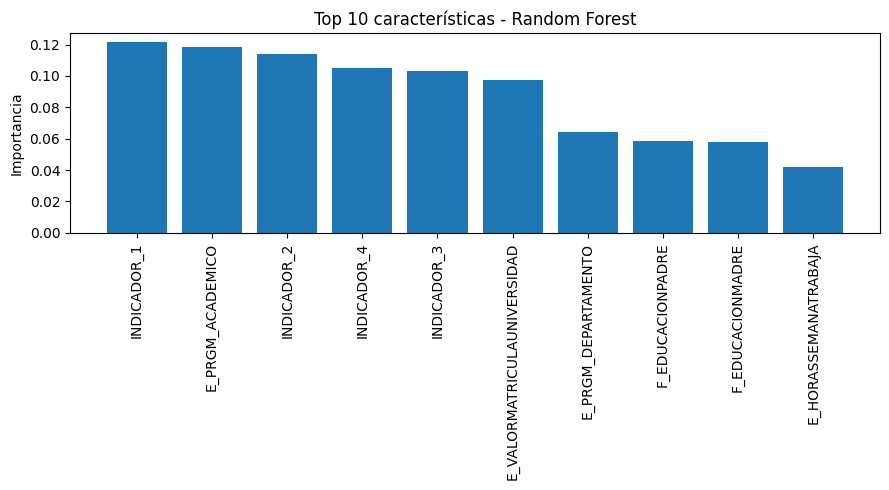

In [35]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# === 1) Copias y saneo mínimo ===
Xt = X_train.copy()
yt = pd.Series(y_train)

# y en numérico si viene en texto
if not np.issubdtype(yt.dtype, np.number):
    yt = LabelEncoder().fit_transform(yt.astype(str).str.strip())

# split de columnas
num_cols = Xt.select_dtypes(include=np.number).columns
cat_cols = Xt.columns.difference(num_cols)

# === 2) Numéricas: to_numeric + imputación median ===
if len(num_cols) > 0:
    Xt[num_cols] = Xt[num_cols].apply(pd.to_numeric, errors='coerce')
    Xt[num_cols] = SimpleImputer(strategy='median').fit_transform(Xt[num_cols])

# === 3) Categóricas: trim, missing -> 'MISSING', OrdinalEncoder ligero ===
if len(cat_cols) > 0:
    Xt[cat_cols] = Xt[cat_cols].applymap(lambda v: v.strip() if isinstance(v, str) else v)
    Xt[cat_cols] = Xt[cat_cols].fillna('MISSING')
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    Xt[cat_cols] = enc.fit_transform(Xt[cat_cols])

# === 4) Random Forest compacto ===
rf = RandomForestClassifier(
    n_estimators=200, max_features="sqrt", min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
rf.fit(Xt, yt)

# === 5) Importancias y gráfico Top-10 ===
imp = pd.Series(rf.feature_importances_, index=Xt.columns).sort_values(ascending=False)
topk = imp.head(10)

plt.figure(figsize=(9,5))
plt.bar(range(len(topk)), topk.values)
plt.xticks(range(len(topk)), topk.index, rotation=90)
plt.ylabel("Importancia"); plt.title("Top 10 características - Random Forest")
plt.tight_layout(); plt.show()

Ahora se hace una matriz de confusión que permitirá observar las diferentes predicciones que realizó el clasificador.

Primero se realizan predicciones en el conjunto de prueba, luego se calcula la matriz de confusión y finalmente se grafica.

Se muestran los nombres de los resultados correspondientes a los números de la gráfica.

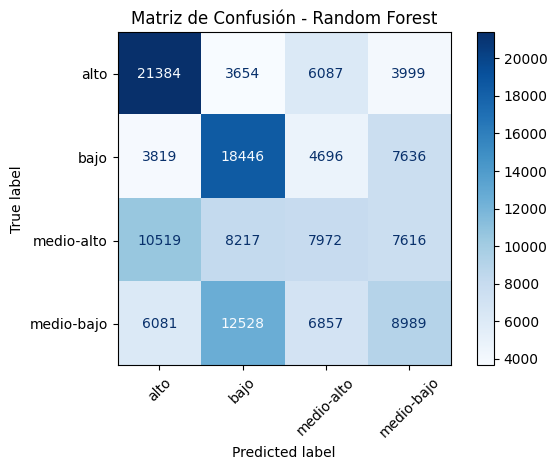

In [37]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# === 1) Datos
z = pd.read_csv("train.csv")
y = z["RENDIMIENTO_GLOBAL"]
X = z.drop(columns=["ID","RENDIMIENTO_GLOBAL"], errors="ignore")

# y → numérico si viene en texto (guardamos el encoder para mostrar nombres)
le_y = None
if not np.issubdtype(y.dtype, np.number):
    le_y = LabelEncoder().fit(y.astype(str).str.strip())
    y = le_y.transform(y.astype(str).str.strip())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# === 2) Preprocesamiento compacto y consistente
num_sel = selector(dtype_include=np.number)
cat_sel = selector(dtype_exclude=np.number)

pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_sel),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]), cat_sel)
], remainder="drop")

# === 3) Modelo + pipeline
rf = RandomForestClassifier(n_estimators=200, max_features="sqrt", min_samples_leaf=5,
                            random_state=42, n_jobs=-1)
pipe = Pipeline([("pre", pre), ("rf", rf)]).fit(X_train, y_train)

# === 4) Predicción + matriz de confusión
y_pred = pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Etiquetas legibles para el eje
if le_y is not None:
    display_labels = le_y.classes_
elif len(np.unique(y)) == 4:
    display_labels = np.array(["bajo","medio-bajo","medio-alto","alto"])
else:
    display_labels = None

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(values_format="d", cmap="Blues")
plt.title("Matriz de Confusión - Random Forest")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

El siguiente es KNeigbors.

Se grafica la matriz de confusión para K vecinos.

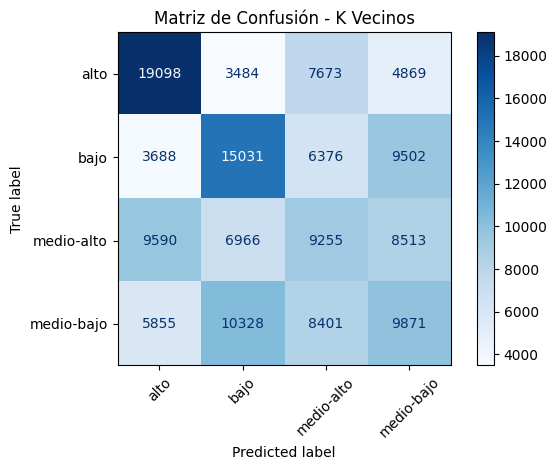

In [40]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1) Carga y split
z = pd.read_csv("train.csv")
y = z["RENDIMIENTO_GLOBAL"]
X = z.drop(columns=["ID","RENDIMIENTO_GLOBAL"], errors="ignore")

# y -> numérica si viene en texto (guardamos encoder para mostrar nombres en la gráfica)
le_y = None
if not np.issubdtype(y.dtype, np.number):
    le_y = LabelEncoder().fit(y.astype(str).str.strip())
    y = le_y.transform(y.astype(str).str.strip())

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2) Preprocesamiento único y consistente (sin caer columnas 100% NaN)
num_sel = selector(dtype_include=np.number)
cat_sel = selector(dtype_exclude=np.number)

pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_sel),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]), cat_sel)
], remainder="drop")

# 3) KNN compacto (ligero para Colab)
knn = KNeighborsClassifier(n_neighbors=11, weights="distance", n_jobs=-1)

pipe = Pipeline([("pre", pre), ("knn", knn)])
pipe.fit(Xtr, ytr)

# 4) Matriz de confusión
yp = pipe.predict(Xte)
cm = confusion_matrix(yte, yp)

labels = le_y.classes_ if le_y is not None else None
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d", cmap="Blues")
plt.title("Matriz de Confusión - K Vecinos")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

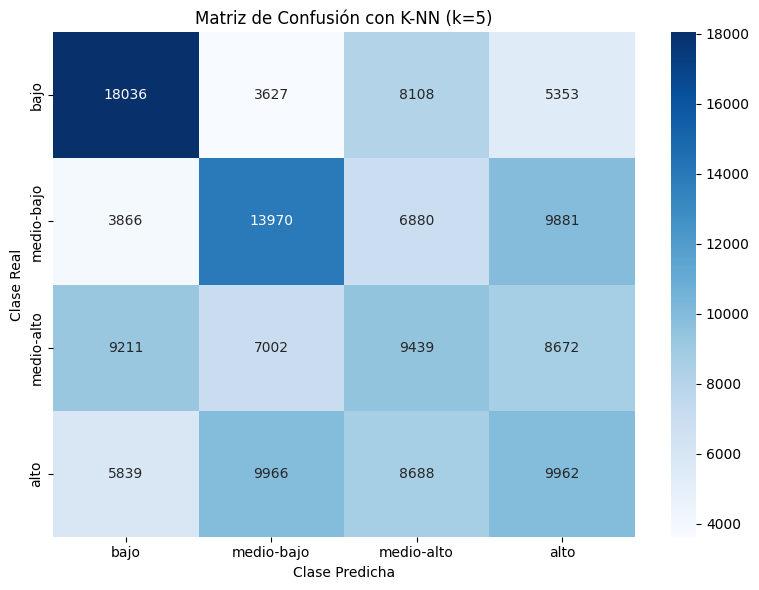

In [42]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix

# Usa tus splits si existen; si no, créalos desde train.csv
if not {'X_train','X_test','y_train','y_test'}.issubset(globals()):
    from sklearn.model_selection import train_test_split
    z = pd.read_csv("train.csv")
    y_raw = z["RENDIMIENTO_GLOBAL"]
    X_raw = z.drop(columns=["ID","RENDIMIENTO_GLOBAL"], errors="ignore")
    # y → numérica si viene en texto
    le_y = LabelEncoder().fit(y_raw.astype(str).str.strip())
    y = le_y.transform(y_raw.astype(str).str.strip())
    X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)
else:
    # Si ya tienes y_train como texto:
    if not np.issubdtype(pd.Series(y_train).dtype, np.number):
        le_y = LabelEncoder().fit(pd.concat([pd.Series(y_train), pd.Series(y_test)], axis=0).astype(str).str.strip())
        y_train = le_y.transform(pd.Series(y_train).astype(str).str.strip())
        y_test  = le_y.transform(pd.Series(y_test ).astype(str).str.strip())
    else:
        le_y = None

# Preprocesamiento único (idéntico para train y test)
num_sel = selector(dtype_include=np.number)
cat_sel = selector(dtype_exclude=np.number)
pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_sel),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]), cat_sel)
], remainder="drop")

# Modelo KNN (ligero)
k = 5
knn = KNeighborsClassifier(n_neighbors=k, weights="distance", n_jobs=-1)
pipe = Pipeline([("pre", pre), ("knn", knn)]).fit(X_train, y_train)

# Predicción + matriz de confusión
y_pred = pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Labels legibles
if le_y is not None:
    labels = le_y.classes_
else:
    # Si ya es numérico y son 4 clases conocidas:
    labels = np.array(["bajo","medio-bajo","medio-alto","alto"]) if len(np.unique(y_test))==4 else np.unique(y_test)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Clase Predicha'); plt.ylabel('Clase Real')
plt.title(f'Matriz de Confusión con K-NN (k={k})')
plt.tight_layout(); plt.show()

Ahora se grafica la curva de aprendizaje. Al ser un archivo tan grande puede tardar un minuto en ejecutarse.

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['E_PRGM_ACADEMICO' 'E_PRGM_DEPARTAMENTO' 'E_VALORMATRICULAUNIVERSIDAD'
 'F_ESTRATOVIVIENDA' 'F_TIENEINTERNET' 'F_EDUCACIONPADRE'
 'F_TIENELAVADORA' 'F_TIENEAUTOMOVIL' 'E_PAGOMATRICULAPROPIO'
 'F_TIENECOMPUTADOR' 'F_TIENEINTERNET.1' 'F_EDUCACIONMADRE']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['E_PRGM_ACADEMICO' 'E_PRGM_DEPARTAMENTO' 'E_VALORMATRICULAUNIVERSIDAD'
 'F_ESTRATOVIVIENDA' 'F_TIENEINTERNET' 'F_EDUCACIONPADRE'
 'F_TIENELAVADORA' 'F_TIENEAUTOMOVIL' 'E_PAGOMATRICULAPROPIO'
 'F_TIENECOMPUTADOR' 'F_TIENEINTERNET.1' 'F_EDUCACIONMADRE']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


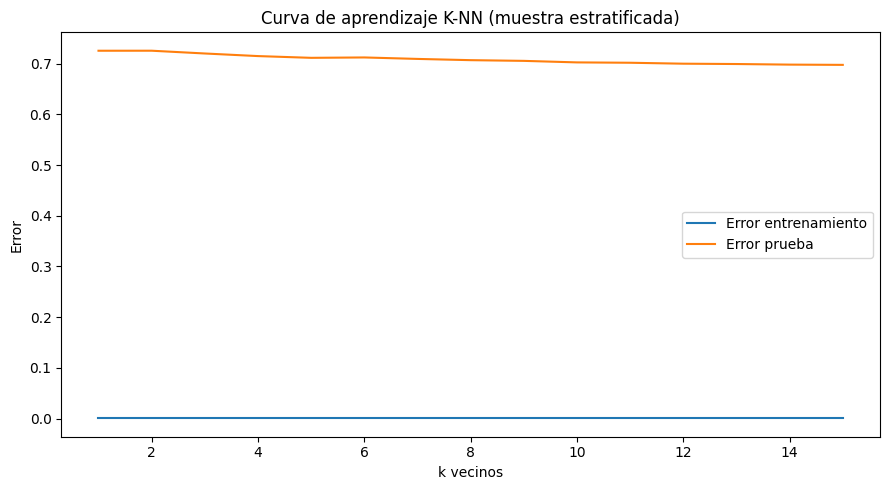

In [47]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.neighbors import KNeighborsClassifier

y_tr = pd.Series(y_train); y_te = pd.Series(y_test)
if not np.issubdtype(y_tr.dtype, np.number):
    le_y = LabelEncoder().fit(pd.concat([y_tr, y_te]).astype(str).str.strip())
    y_tr = le_y.transform(y_tr.astype(str).str.strip())
    y_te = le_y.transform(y_te.astype(str).str.strip())
else:
    le_y = None
    y_tr, y_te = y_tr.to_numpy(), y_te.to_numpy()

num_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = [c for c in X_train.columns if c not in num_cols]

pre = ColumnTransformer([
    ("num", Pipeline([
        ("to_num", FunctionTransformer(lambda df: pd.DataFrame(df).apply(pd.to_numeric, errors='coerce'),
                                       validate=False)),
        ("imp", SimpleImputer(strategy="median"))
    ]), num_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]), cat_cols)
], remainder="drop")

# 1) Transforma UNA vez
Xtr_t = pre.fit_transform(X_train).astype(np.float32)
Xte_t = pre.transform(X_test).astype(np.float32)

# 2) Submuestra estratificada para acelerar (ajusta a tu RAM)
N_target = min(150_000, Xtr_t.shape[0])
if N_target < Xtr_t.shape[0]:
    sss = StratifiedShuffleSplit(n_splits=1, train_size=N_target, random_state=42)
    idx = next(sss.split(Xtr_t, y_tr))[0]
    Xtr_sub, ytr_sub = Xtr_t[idx], y_tr[idx]
else:
    Xtr_sub, ytr_sub = Xtr_t, y_tr

# 3) Curva de error vs k (rápida)
neighbors = np.arange(1, 16)  # limita k para velocidad
train_err, test_err = [], []
for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k, weights="distance", n_jobs=-1)
    knn.fit(Xtr_sub, ytr_sub)
    train_err.append(1 - knn.score(Xtr_sub, ytr_sub))
    test_err.append(1 - knn.score(Xte_t, y_te))

plt.figure(figsize=(9,5))
plt.plot(neighbors, train_err, label='Error entrenamiento')
plt.plot(neighbors, test_err,  label='Error prueba')
plt.xlabel('k vecinos'); plt.ylabel('Error')
plt.title('Curva de aprendizaje K-NN (muestra estratificada)')
plt.legend(); plt.tight_layout(); plt.show()

El siguiente clasificador es Bernoulli.

Se crea grafica una matriz de probabilidades. Primero se crea una instancia del clasificador, luego se ajusta a los datos, se obtiene la matriz de probabilidades estimadas y por último se grafica la matriz.

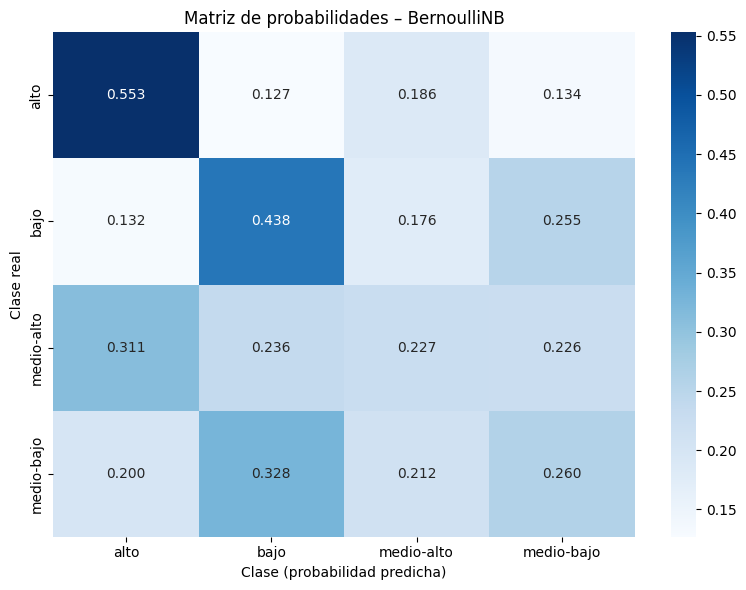

In [49]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, Binarizer
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import BernoulliNB
from sklearn.pipeline import Pipeline
from scipy import sparse

# 1) Carga y split
z = pd.read_csv("train.csv")
y_raw = z["RENDIMIENTO_GLOBAL"]
X_raw = z.drop(columns=["ID","RENDIMIENTO_GLOBAL"], errors="ignore")

# y → numérica si viene en texto (guardamos labels para ejes)
le_y = LabelEncoder().fit(y_raw.astype(str).str.strip())
y = le_y.transform(y_raw.astype(str).str.strip())

X_tr, X_te, y_tr, y_te = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)

# 2) Preprocesamiento para Bernoulli:
#    - Numéricas: imputación mediana + binarización por mediana (≈ presencia/ausencia)
#    - Categóricas: imputación "MISSING" + OneHot (sparse)
num_sel = selector(dtype_include=np.number)
cat_sel = selector(dtype_exclude=np.number)

num_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("bin", Binarizer())  # umbral 0 por defecto -> después de centrar por mediana funciona como binario presencia/ausencia
])

cat_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))  # sparse por defecto
])

pre = ColumnTransformer([
    ("num", num_pipe, num_sel),
    ("cat", cat_pipe, cat_sel)
], remainder="drop", sparse_threshold=1.0)

# 3) Modelo
bnb = BernoulliNB(alpha=1.0)
pipe = Pipeline([("pre", pre), ("clf", bnb)])

pipe.fit(X_tr, y_tr)

# 4) Probabilidades por clase y “matriz de probabilidades” (promedio por clase real)
proba = pipe.predict_proba(X_te)  # shape: (n_samples, n_classes)
classes = np.arange(len(le_y.classes_))

P = np.zeros((len(classes), len(classes)), dtype=float)
for i in classes:
    idx = np.where(y_te == i)[0]
    # promedio de las probabilidades predichas para cada columna (clase j) en los ejemplos con clase real i
    P[i, :] = proba[idx].mean(axis=0) if idx.size else 0.0

# 5) Heatmap con etiquetas legibles
plt.figure(figsize=(8,6))
sns.heatmap(P, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=le_y.classes_, yticklabels=le_y.classes_)
plt.xlabel("Clase (probabilidad predicha)"); plt.ylabel("Clase real")
plt.title("Matriz de probabilidades – BernoulliNB")
plt.tight_layout(); plt.show()

/tmp/ipython-input-1945150530.py:64: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.xticks(rotation=90); plt.tight_layout(); plt.show()


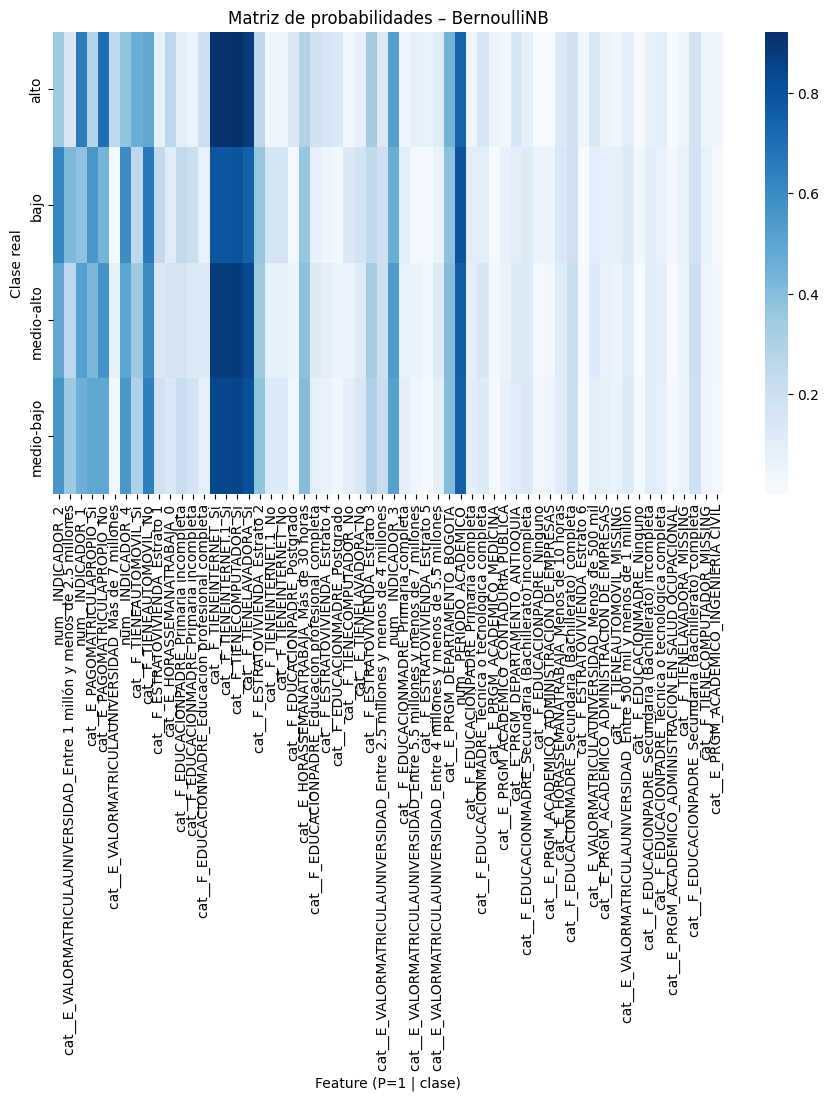

In [51]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, KBinsDiscretizer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import BernoulliNB

# 1) Datos
z = pd.read_csv("train.csv")
y_raw = z["RENDIMIENTO_GLOBAL"]
X_raw = z.drop(columns=["ID","RENDIMIENTO_GLOBAL"], errors="ignore")

le_y = LabelEncoder().fit(y_raw.astype(str).str.strip())
y = le_y.transform(y_raw.astype(str).str.strip())

Xtr, Xte, ytr, yte = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)

# 2) Preprocesamiento para Bernoulli (todo 0/1):
num_sel = selector(dtype_include=np.number)
cat_sel = selector(dtype_exclude=np.number)

pre = ColumnTransformer([
    # Numéricas: imputar y binarizar por cuantiles (2 bins ≈ mediana)
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("bin", KBinsDiscretizer(n_bins=2, encode="ordinal", strategy="quantile"))
    ]), num_sel),
    # Categóricas: imputar "MISSING" y OneHot (0/1)
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_sel)
], remainder="drop")

# 3) Modelo
bnb = BernoulliNB(alpha=1.0)
pipe = Pipeline([("pre", pre), ("clf", bnb)]).fit(Xtr, ytr)

# 4) Matriz de probabilidades: P(x_j=1 | clase=i)
logP = pipe.named_steps["clf"].feature_log_prob_   # shape: (n_clases, n_features)
P = np.exp(logP)

# Nombres de ejes
feat_names = pipe.named_steps["pre"].get_feature_names_out()
class_names = le_y.classes_

# (Opcional) Si hay MUCHAS features, muestra las más “discriminantes”
if P.shape[1] > 60:
    var_across_classes = P.var(axis=0)
    top_idx = np.argsort(var_across_classes)[::-1][:60]
    P_plot = P[:, top_idx]
    feat_plot = feat_names[top_idx]
else:
    P_plot, feat_plot = P, feat_names

# 5) Heatmap
plt.figure(figsize=(max(8, len(feat_plot)*0.18), 6))
sns.heatmap(P_plot, cmap="Blues", annot=False,
            xticklabels=feat_plot, yticklabels=class_names)
plt.xlabel("Feature (P=1 | clase)")
plt.ylabel("Clase real")
plt.title("Matriz de probabilidades – BernoulliNB")
plt.xticks(rotation=90); plt.tight_layout(); plt.show()

Se tiene ahora a Logistic Regression.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy Test: 0.4036


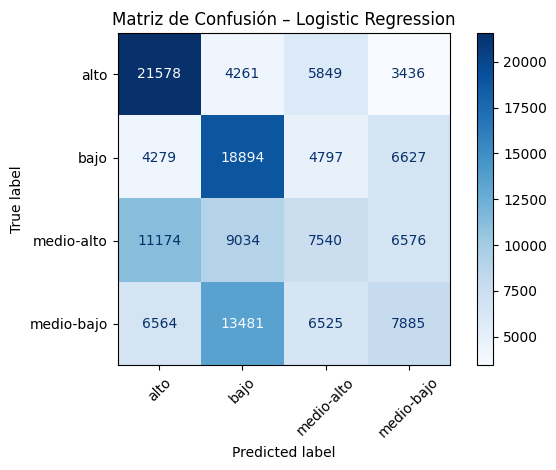

In [53]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# 1) Carga y split
z = pd.read_csv("train.csv")
y_raw = z["RENDIMIENTO_GLOBAL"]
X_raw = z.drop(columns=["ID","RENDIMIENTO_GLOBAL"], errors="ignore")

# y -> numérica si viene en texto (guardamos labels para ejes)
le_y = None
if not np.issubdtype(y_raw.dtype, np.number):
    le_y = LabelEncoder().fit(y_raw.astype(str).str.strip())
    y = le_y.transform(y_raw.astype(str).str.strip())
else:
    y = y_raw.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# 2) Preprocesamiento consistente (sparse):
#    num -> imputar + escalar (sin centrar); cat -> imputar "MISSING" + OneHot
num_sel = selector(dtype_include=np.number)
cat_sel = selector(dtype_exclude=np.number)

pre = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc",  StandardScaler(with_mean=False))  # compatible con sparse
    ]), num_sel),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))  # sparse por defecto
    ]), cat_sel)
], remainder="drop")

# 3) Modelo: multinomial con saga (soporta OHE grande)
logreg = LogisticRegression(
    solver="saga", multi_class="multinomial", max_iter=300, C=1.0
)

pipe = Pipeline([("pre", pre), ("clf", logreg)])
pipe.fit(X_train, y_train)

# 4) Métricas rápidas + Matriz de confusión
y_pred = pipe.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy Test: {acc:.4f}")

labels = le_y.classes_ if le_y is not None else np.unique(y)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d", cmap="Blues")
plt.title("Matriz de Confusión – Logistic Regression")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

Se crea una matriz de confusión para analizar las predicciones.

Como la matriz graficada presenta numeros con exponentes, se muestra la matriz con los datos numéricos.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


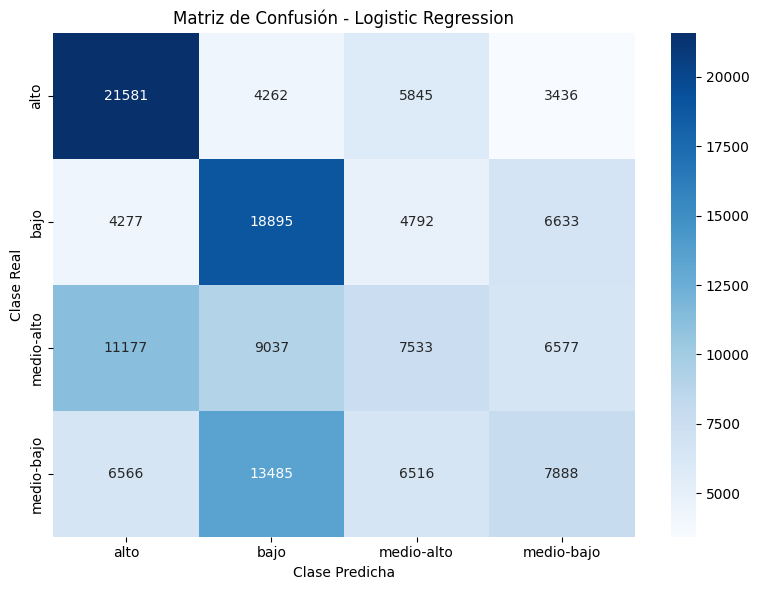


Matriz de confusión (valores enteros):
 [[21581  4262  5845  3436]
 [ 4277 18895  4792  6633]
 [11177  9037  7533  6577]
 [ 6566 13485  6516  7888]]


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# Usa tus splits si ya existen; si no, créalos desde train.csv
if not {'X_train','X_test','y_train','y_test'}.issubset(globals()):
    from sklearn.model_selection import train_test_split
    z = pd.read_csv("train.csv")
    y_raw = z["RENDIMIENTO_GLOBAL"]
    X_raw = z.drop(columns=["ID","RENDIMIENTO_GLOBAL"], errors="ignore")
    # y en numérico si viene en texto
    le_y = LabelEncoder().fit(y_raw.astype(str).str.strip())
    y = le_y.transform(y_raw.astype(str).str.strip())
    X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)
else:
    # normaliza y si es texto
    if not np.issubdtype(pd.Series(y_train).dtype, np.number):
        le_y = LabelEncoder().fit(pd.concat([pd.Series(y_train), pd.Series(y_test)]).astype(str).str.strip())
        y_train = le_y.transform(pd.Series(y_train).astype(str).str.strip())
        y_test  = le_y.transform(pd.Series(y_test ).astype(str).str.strip())
    else:
        le_y = None

# Preprocesamiento consistente (sparse-friendly)
num_sel = selector(dtype_include=np.number)
cat_sel = selector(dtype_exclude=np.number)
pre = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc",  StandardScaler(with_mean=False))  # compatible con matrices dispersas
    ]), num_sel),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))  # sparse por defecto
    ]), cat_sel)
], remainder="drop")

# Logística multinomial robusta
logreg = LogisticRegression(solver="saga", multi_class="multinomial", max_iter=300)
pipe = Pipeline([("pre", pre), ("clf", logreg)]).fit(X_train, y_train)

# Predicciones + matriz de confusión en enteros
y_pred = pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred).astype(int)  # fuerza enteros

plt.figure(figsize=(8,6))
labels = le_y.classes_ if le_y is not None else np.unique(y_train)
sns.heatmap(cm, annot=True, cmap="Blues", fmt='d',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Clase Predicha'); plt.ylabel('Clase Real')
plt.title('Matriz de Confusión - Logistic Regression')
plt.tight_layout(); plt.show()

print("\nMatriz de confusión (valores enteros):\n", cm)

Por último se tiene el clasificador Adaboost, este es el de menor puntaje.

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Accuracy (Test) AdaBoost: 0.3743


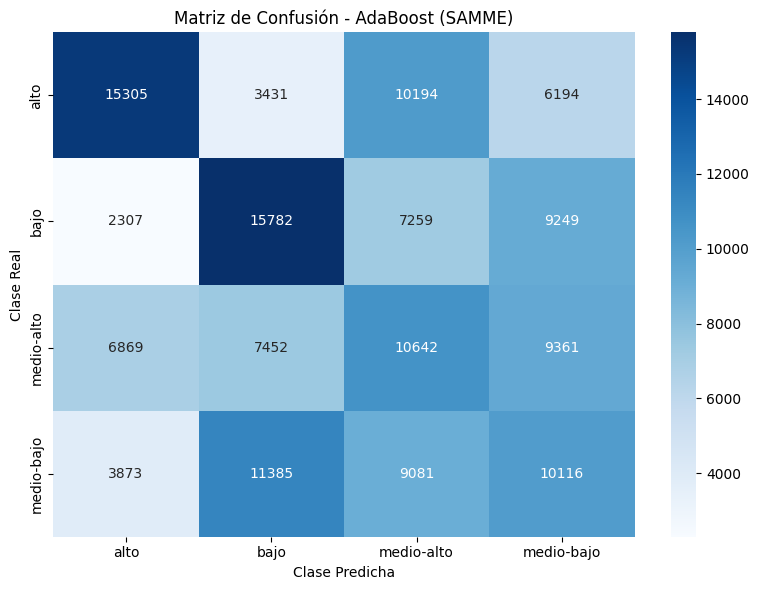

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

base = DecisionTreeClassifier(max_depth=1, random_state=42)

ada = AdaBoostClassifier(
    estimator=base,
    n_estimators=200,      # si quieres más señal, súbelo
    learning_rate=0.5,     # puedes tunear 0.1–0.5
    algorithm="SAMME",     # <— FIX: nada de 'SAMME.R' en tu versión
    random_state=42
)

pipe = Pipeline([("pre", pre), ("clf", ada)]).fit(X_train, y_train)

y_pred = pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred).astype(int)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy (Test) AdaBoost: {acc:.4f}")

labels = le_y.classes_ if le_y is not None else np.unique(y_train)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt='d',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Clase Predicha'); plt.ylabel('Clase Real')
plt.title('Matriz de Confusión - AdaBoost (SAMME)'); plt.tight_layout(); plt.show()

Se crea una gráfica de las 10 características más importantes.

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


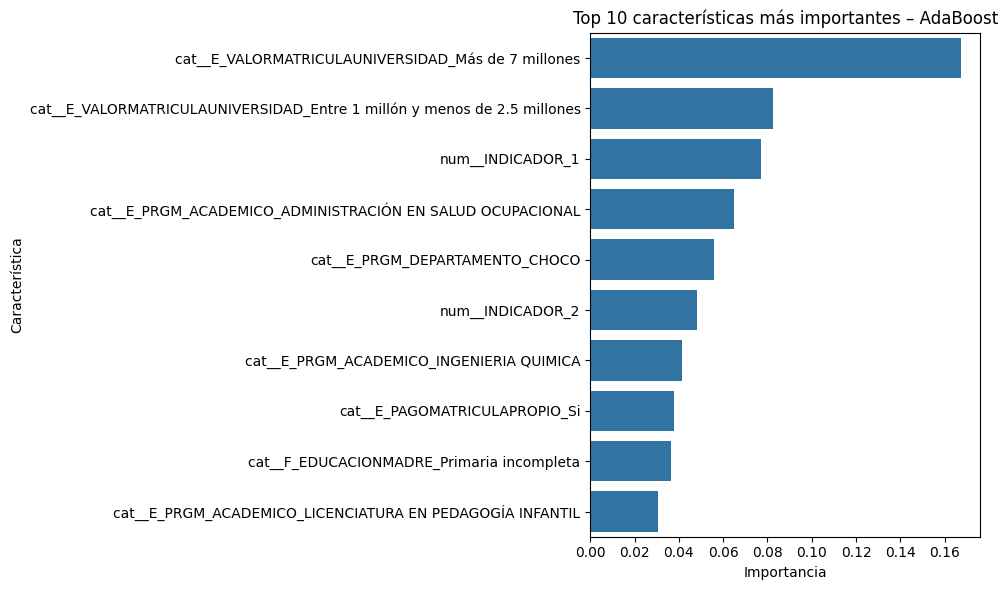

In [6]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

# Si ya tienes X_train, X_test, y_train, y_test, los usamos tal cual.
# Si y es texto, codifícala para entrenar (solo para el modelo; las etiquetas bonitas son opcionales):
if not np.issubdtype(pd.Series(y_train).dtype, np.number):
    le_y = LabelEncoder().fit(pd.concat([pd.Series(y_train), pd.Series(y_test)]).astype(str).str.strip())
    y_train_enc = le_y.transform(pd.Series(y_train).astype(str).str.strip())
    y_test_enc  = le_y.transform(pd.Series(y_test ).astype(str).str.strip())
else:
    le_y = None
    y_train_enc, y_test_enc = y_train, y_test

# Preprocesamiento consistente (imputa NaN y OHE para categóricas)
num_sel = selector(dtype_include=np.number)
cat_sel = selector(dtype_exclude=np.number)
pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_sel),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))  # sparse por defecto (mejor RAM)
    ]), cat_sel)
], remainder="drop")

# AdaBoost con árboles débiles (stumps) — usa 'SAMME' en tu versión
base = DecisionTreeClassifier(max_depth=1, random_state=42)
ada  = AdaBoostClassifier(estimator=base, n_estimators=200, learning_rate=0.5,
                          algorithm="SAMME", random_state=42)

pipe = Pipeline([("pre", pre), ("clf", ada)]).fit(X_train, y_train_enc)

# Importancias y nombres de features post-OHE (correctos)
feat_names = pipe.named_steps["pre"].get_feature_names_out()
importances = pipe.named_steps["clf"].feature_importances_
top = (pd.Series(importances, index=feat_names)
         .sort_values(ascending=False)
         .head(10))

# Plot Top-10 bien ordenado
plt.figure(figsize=(10,6))
sns.barplot(x=top.values, y=top.index)
plt.xlabel("Importancia"); plt.ylabel("Característica")
plt.title("Top 10 características más importantes – AdaBoost")
plt.tight_layout(); plt.show()

Ahora se muestra el primer árbol de decisión para el clasificador (son 50 árbles de decisión)

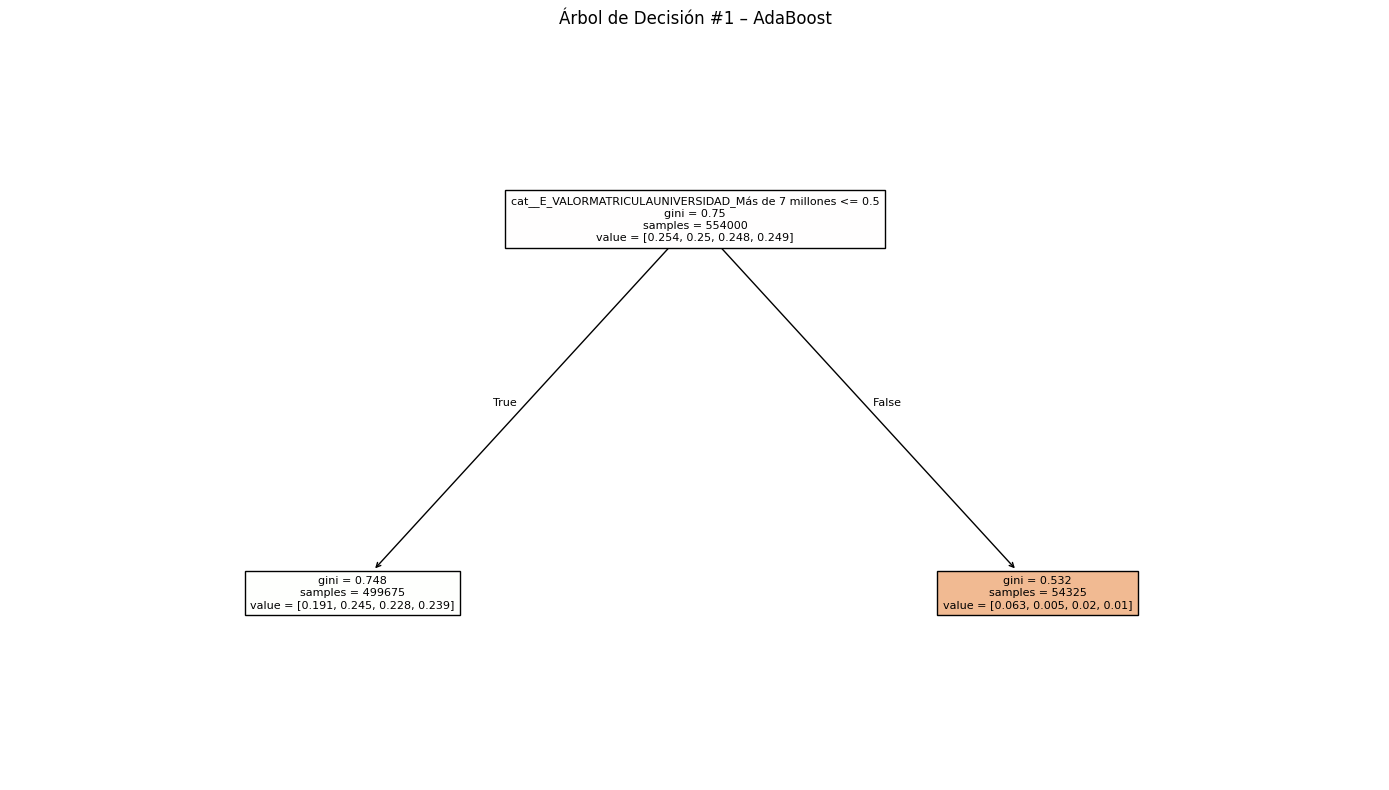

In [8]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# 1) Toma el primer árbol entrenado dentro del pipeline
tree = pipe.named_steps["clf"].estimators_[0]

# 2) Nombres de features ya transformados (post-OHE)
feat_names = pipe.named_steps["pre"].get_feature_names_out()

# 3) Plot (limito profundidad para que sea legible; quita max_depth para verlo completo)
plt.figure(figsize=(14, 8))
plot_tree(tree, feature_names=feat_names, filled=True, max_depth=2, fontsize=8)
plt.title("Árbol de Decisión #1 – AdaBoost")
plt.tight_layout(); plt.show()

Para ver los 50 árboles de decisión se ejecuta la siguiente celda.

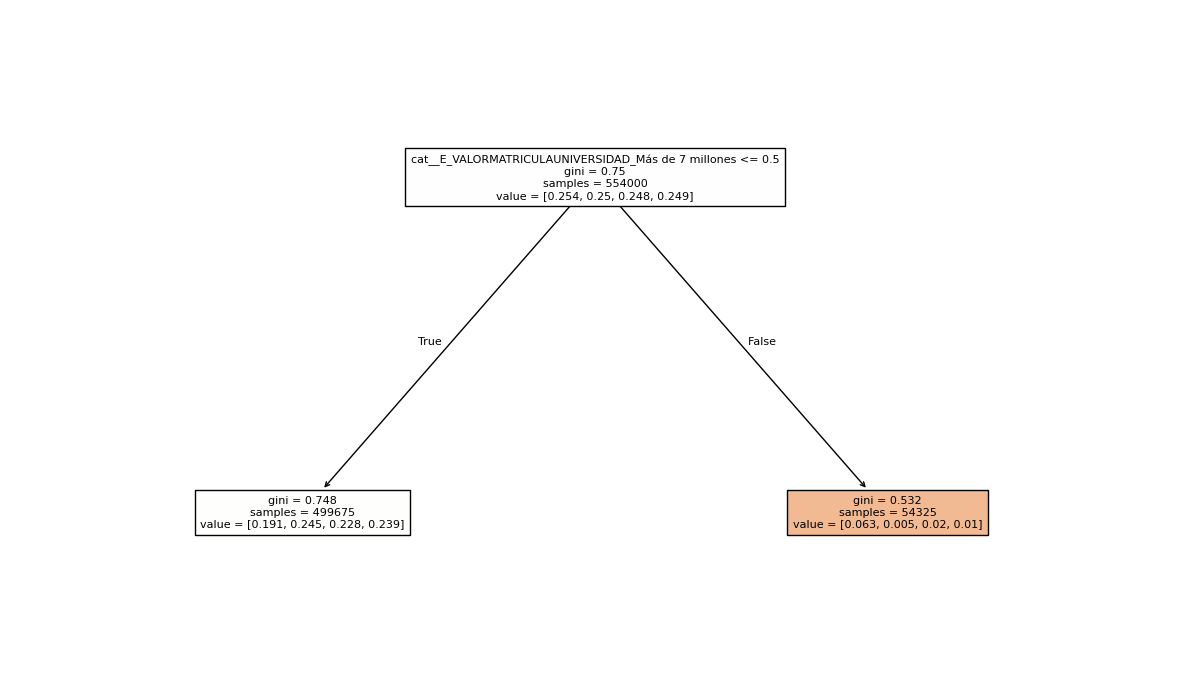

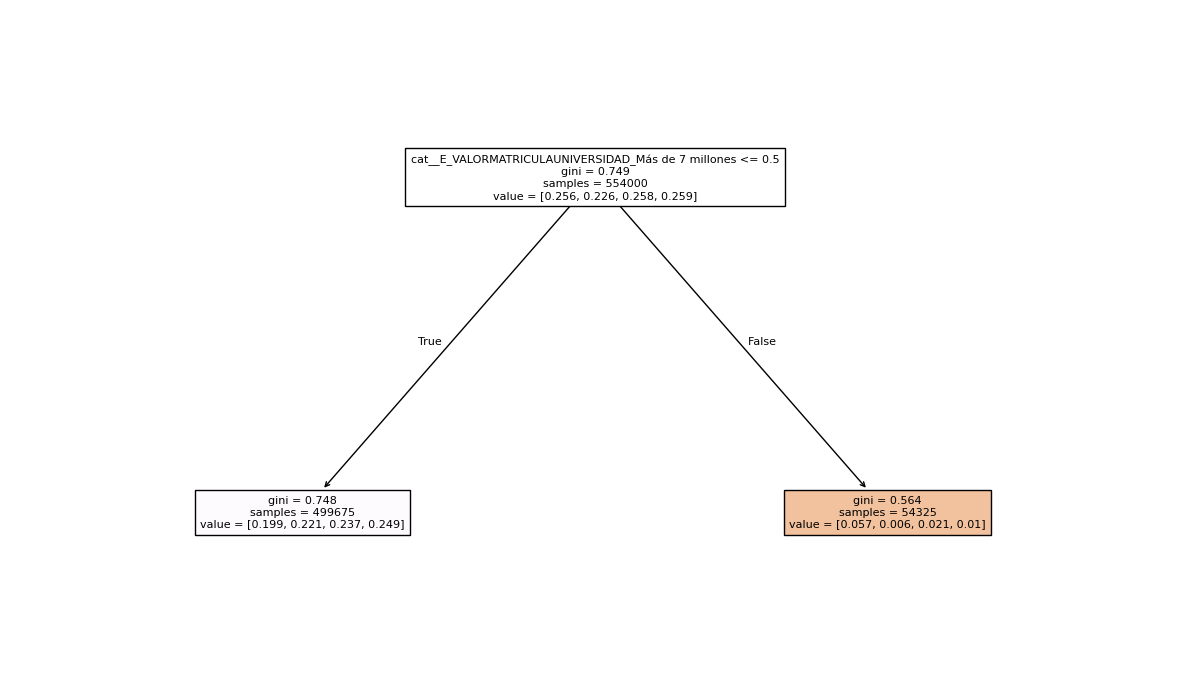

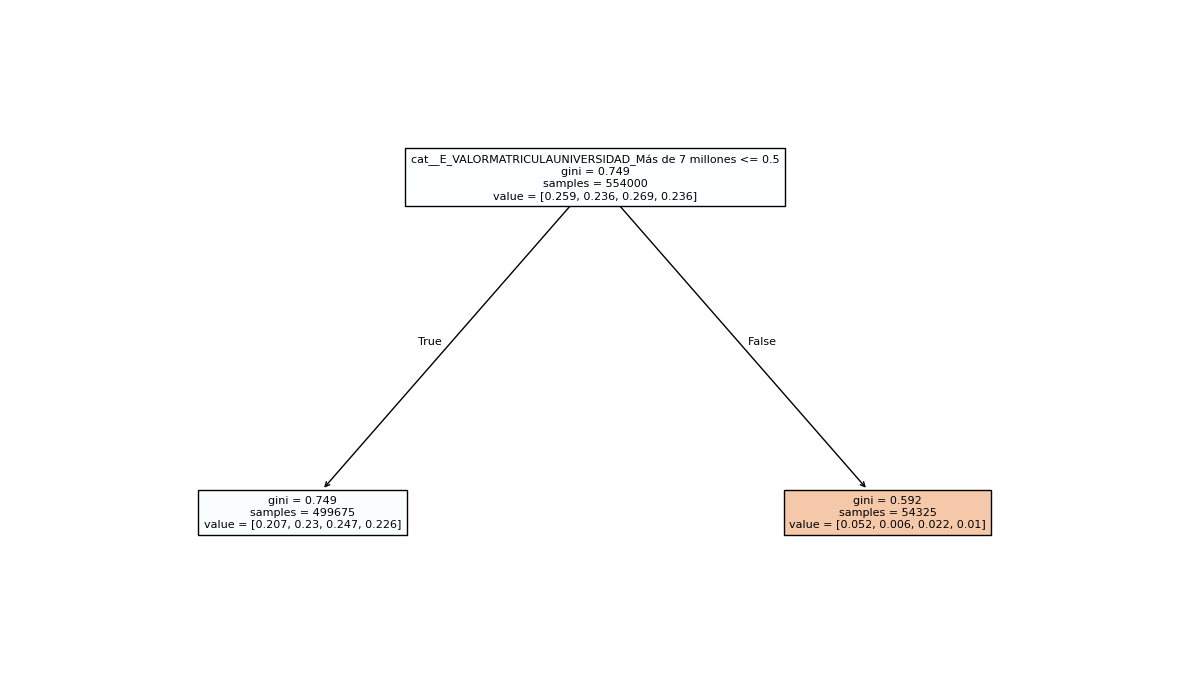

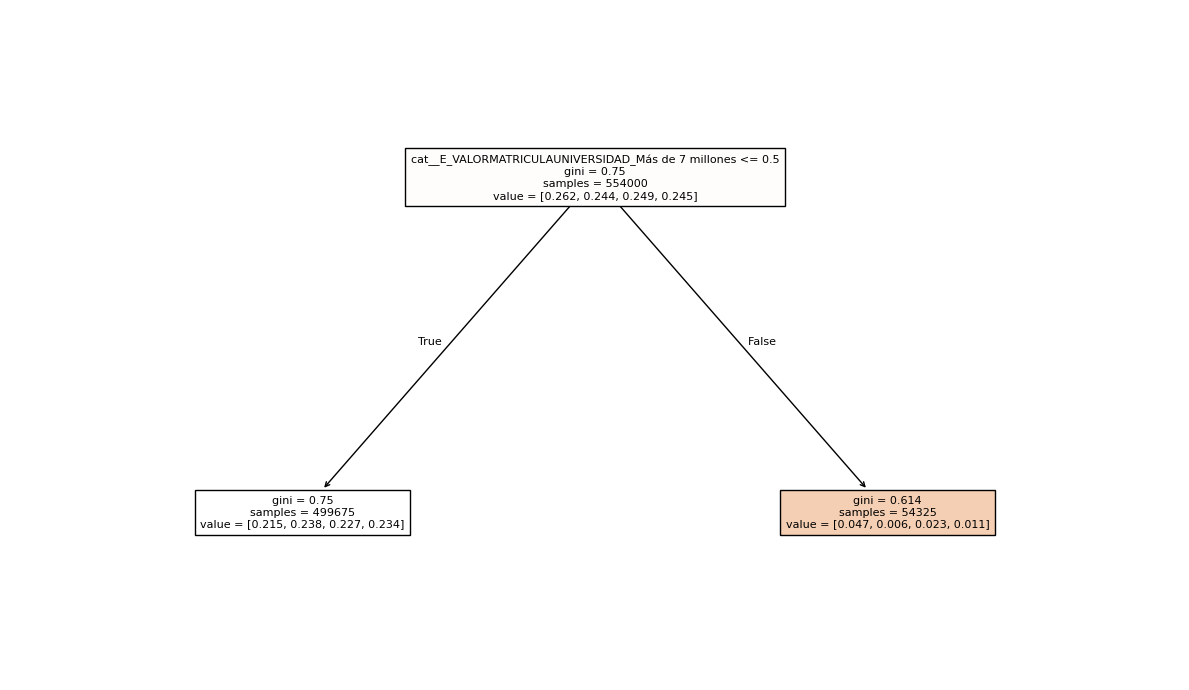

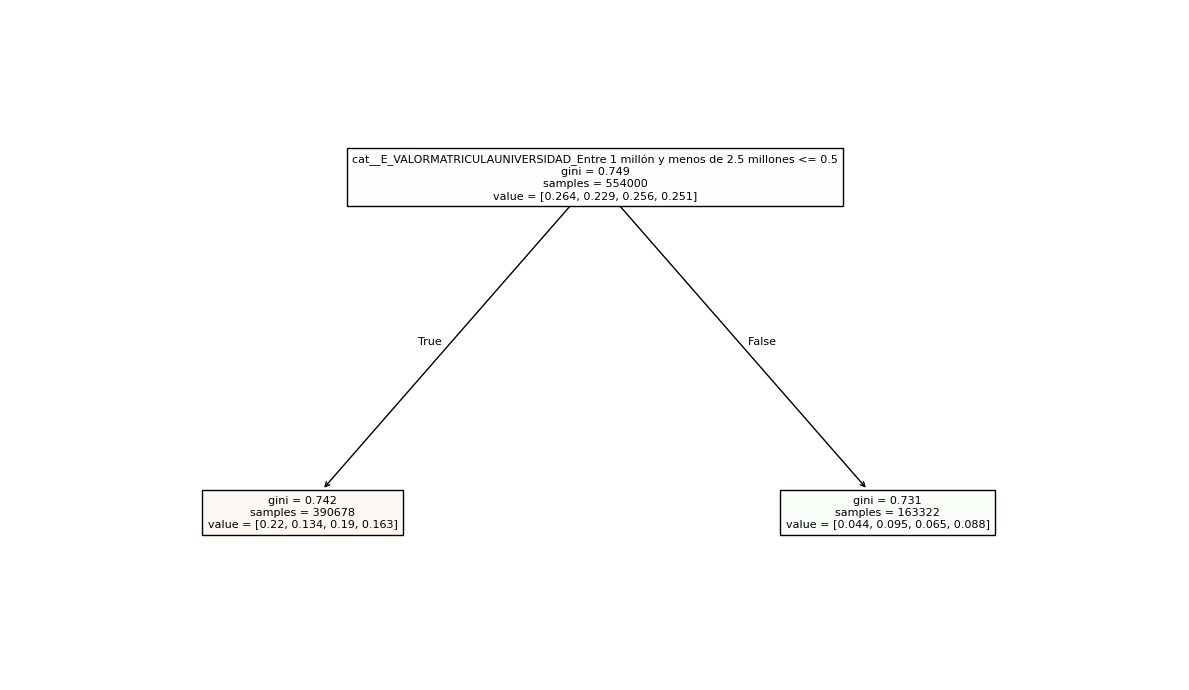

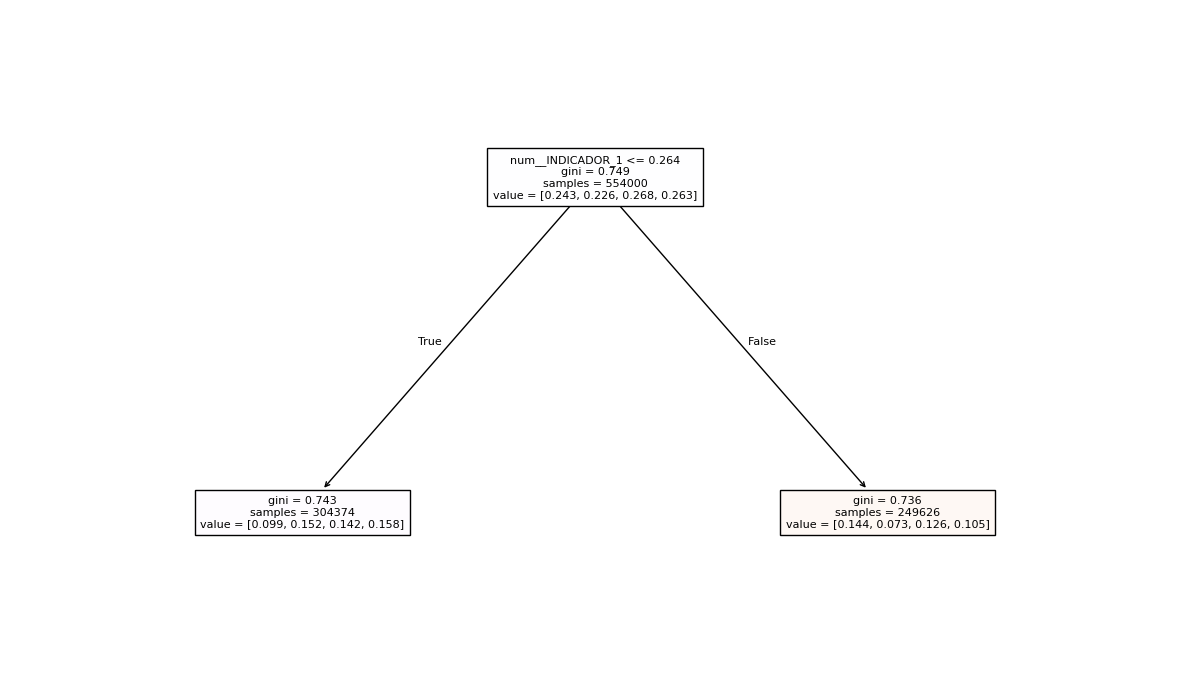

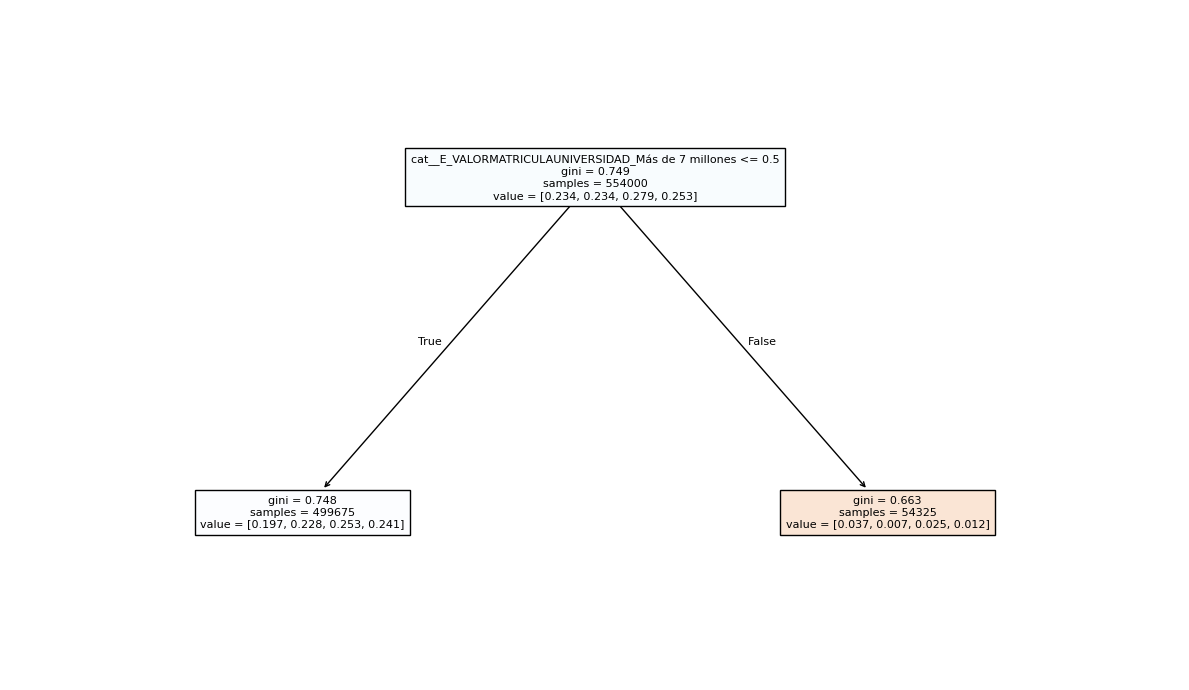

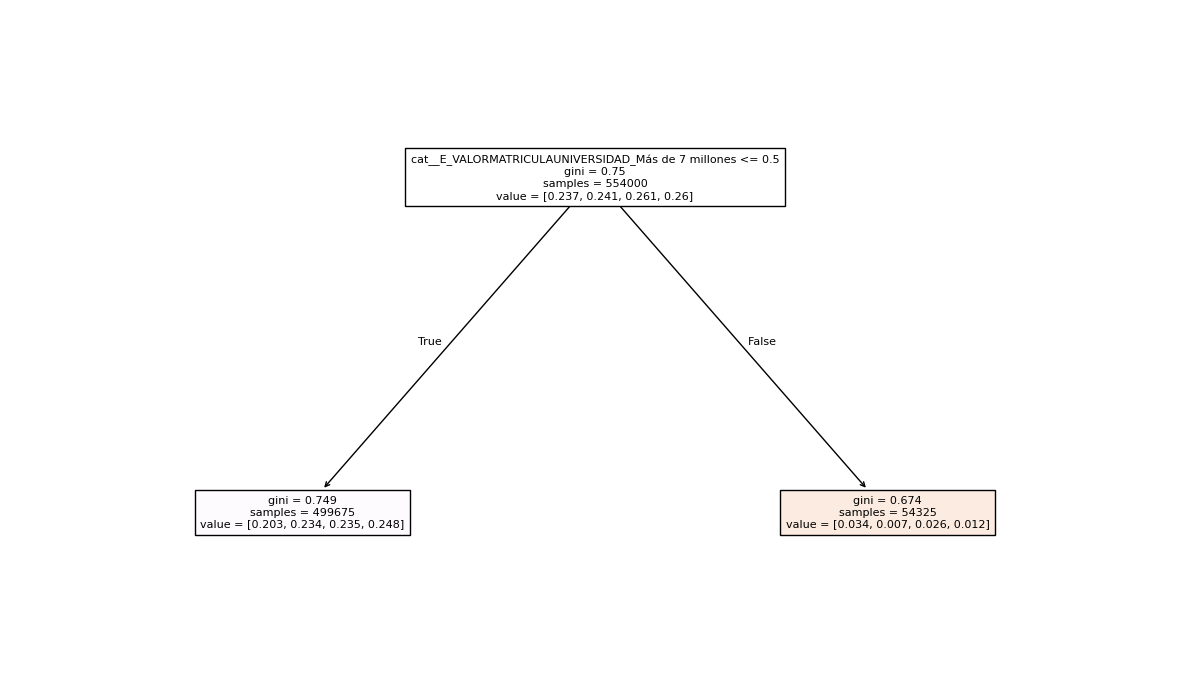

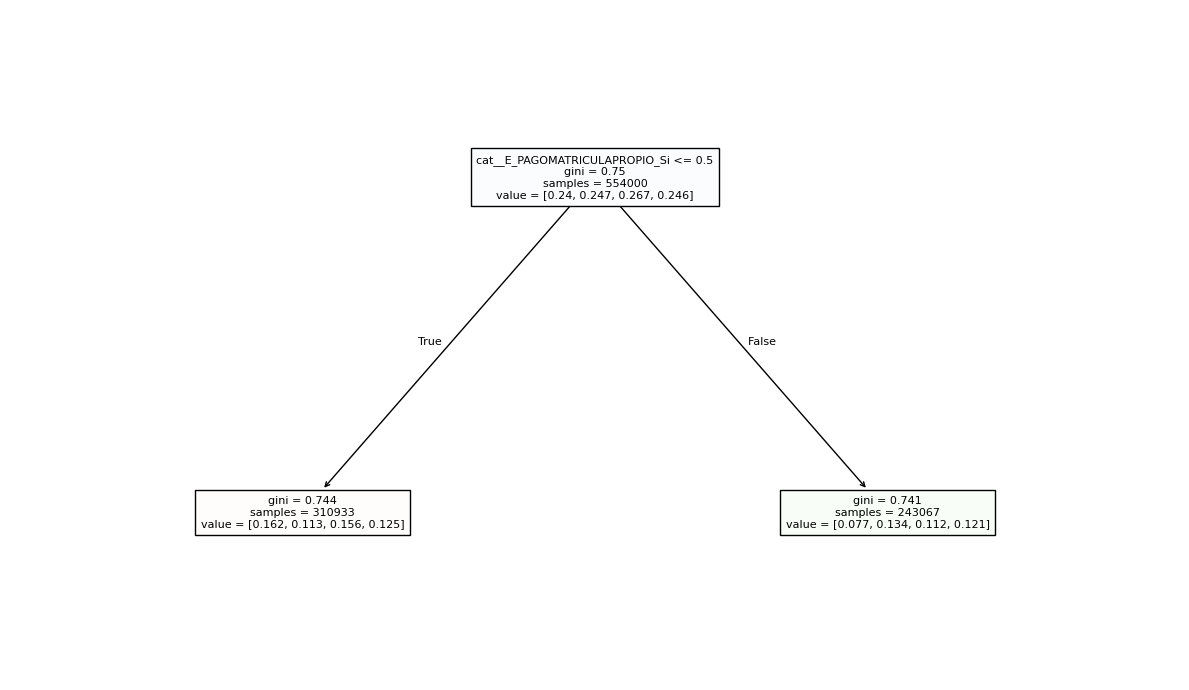

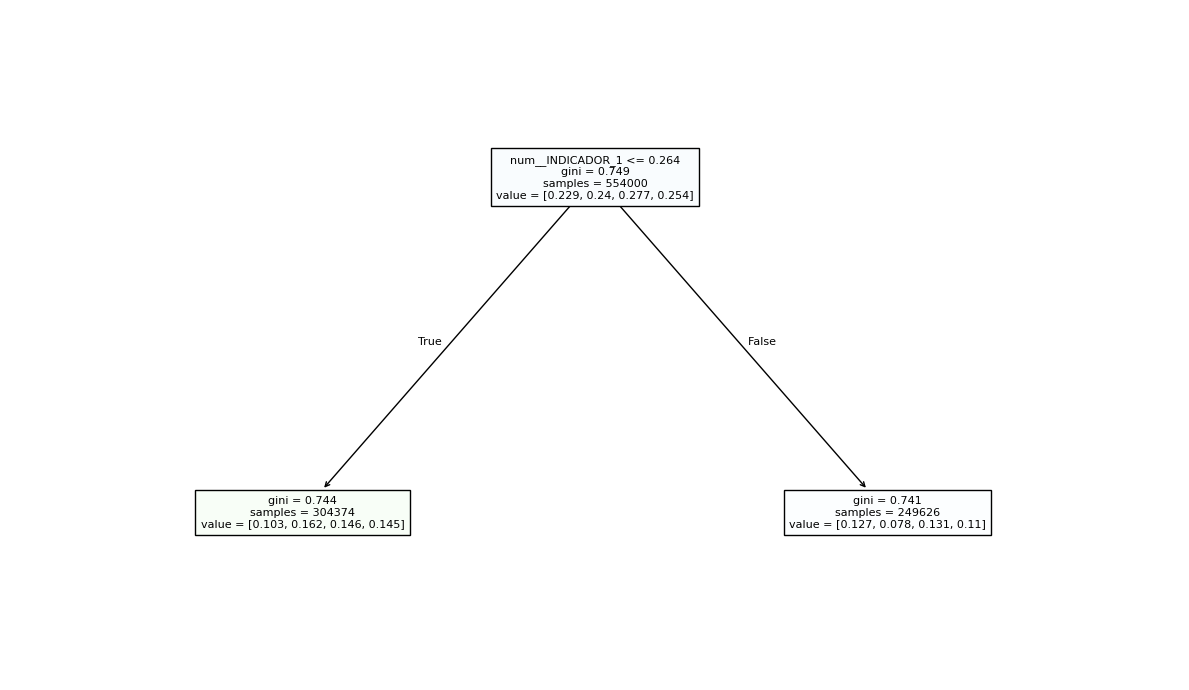

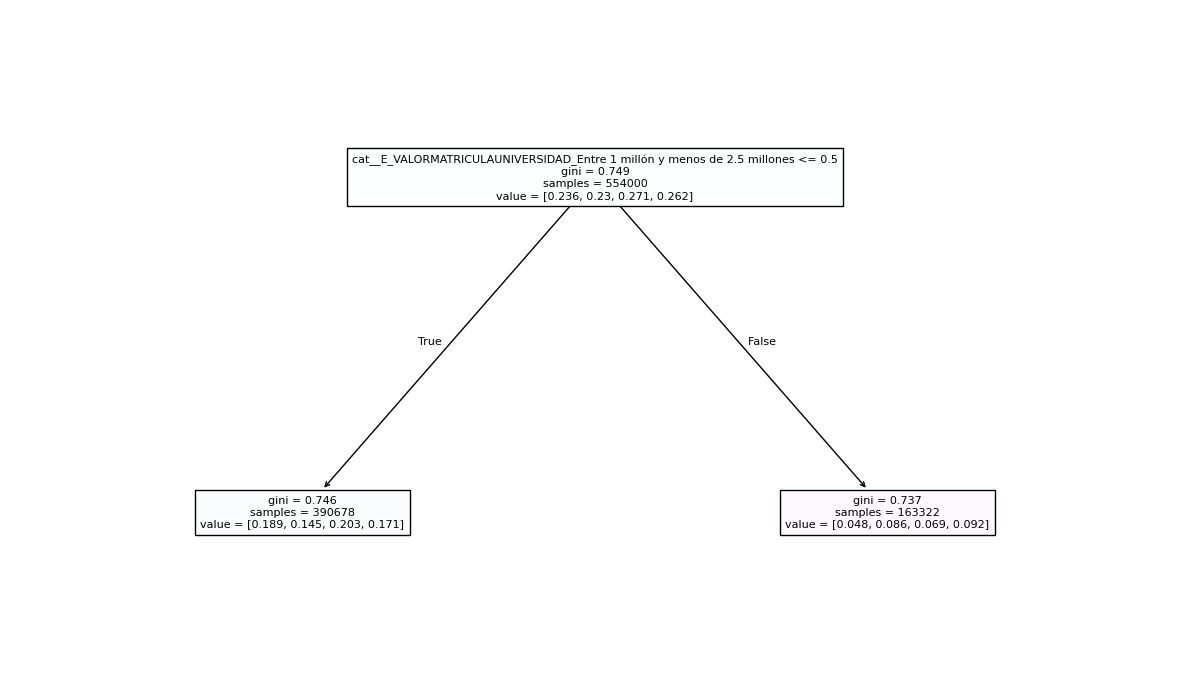

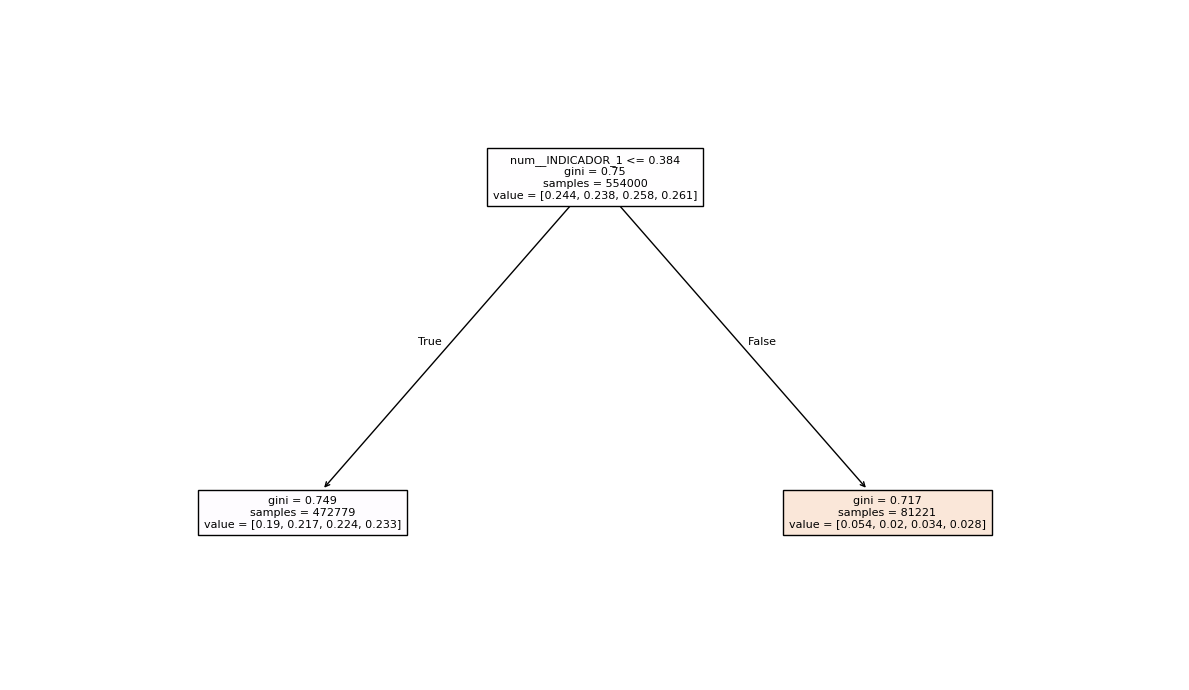

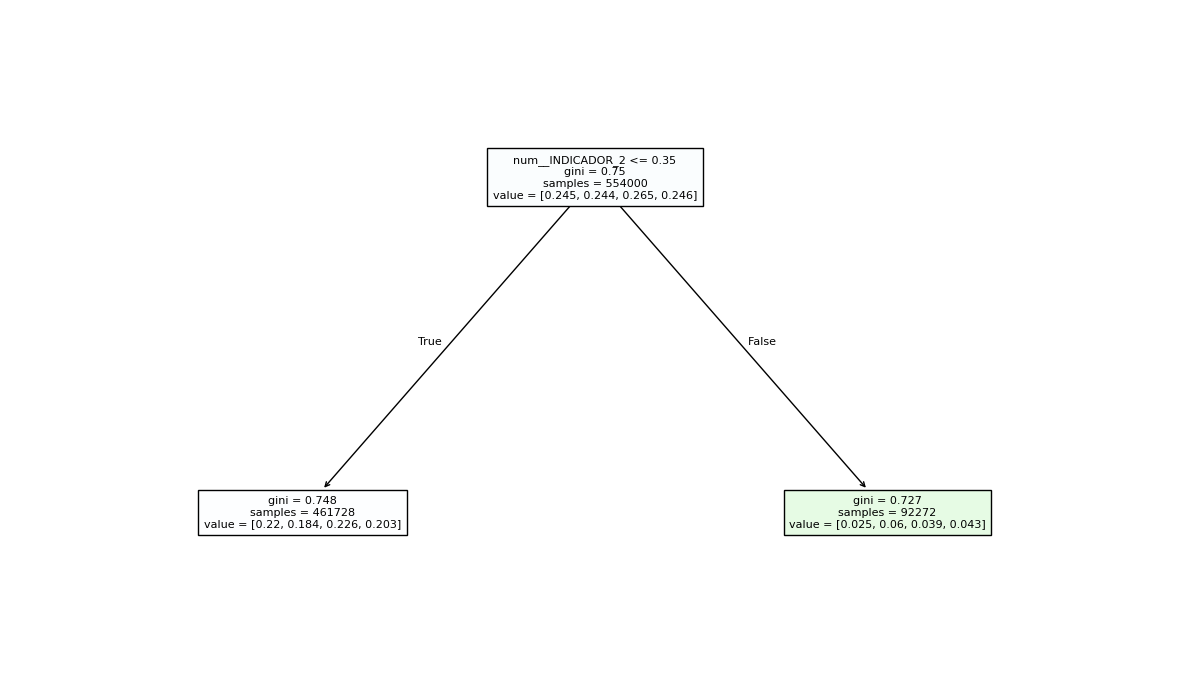

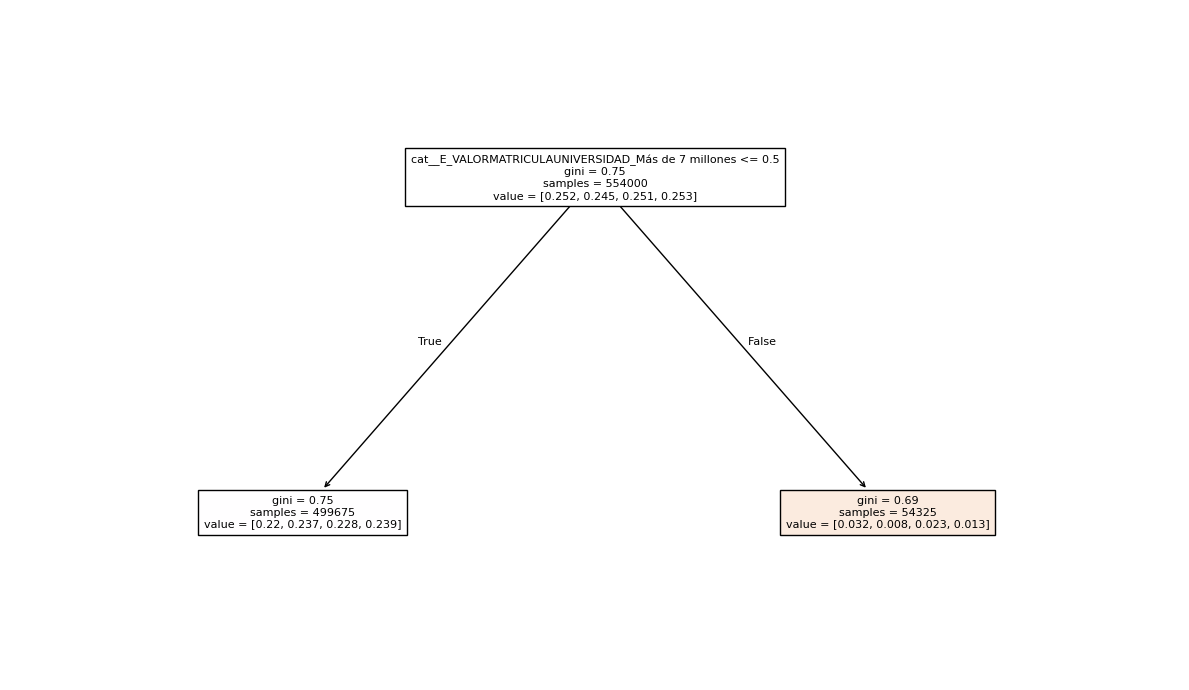

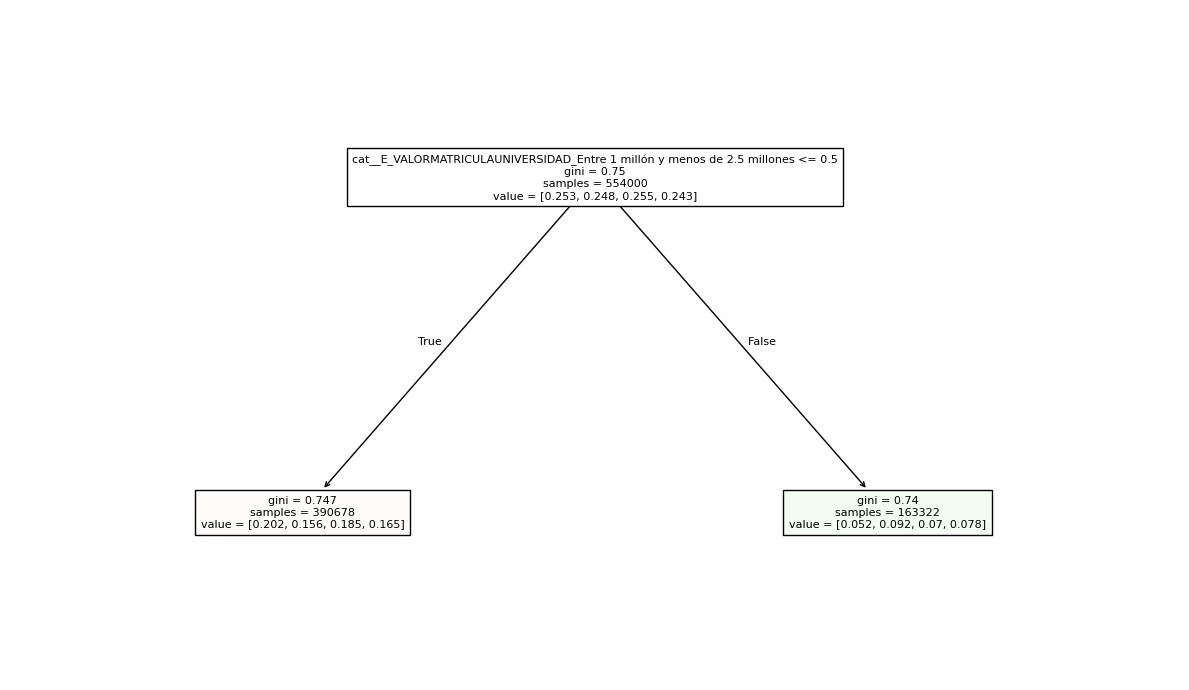

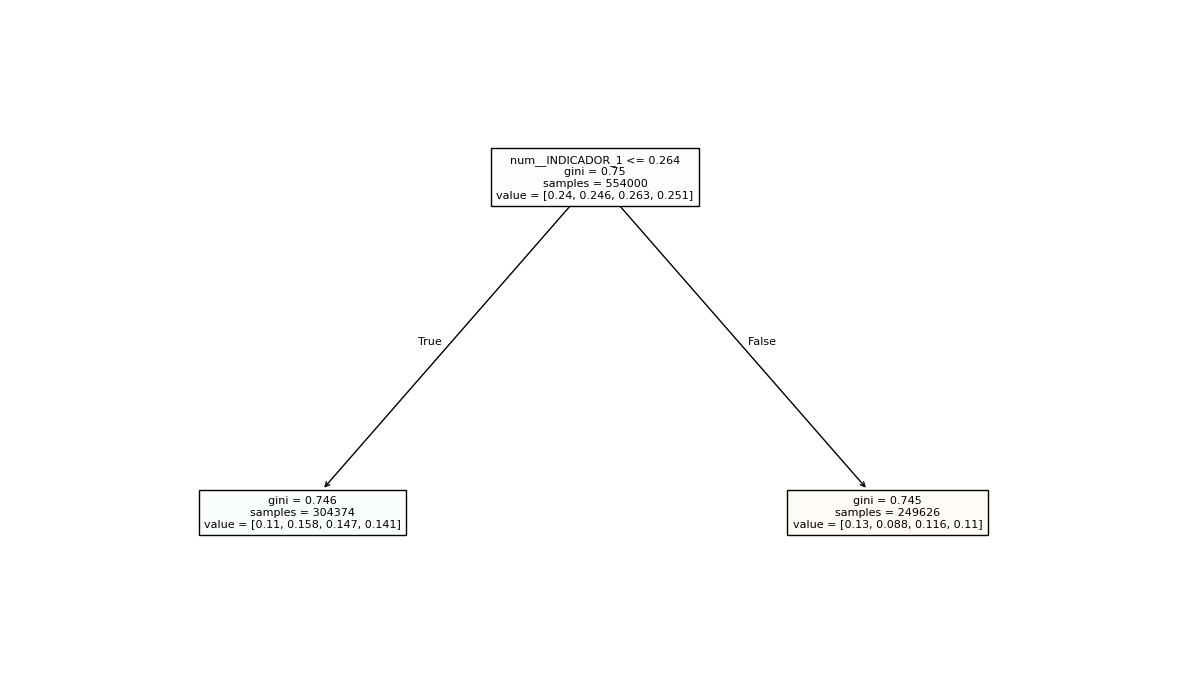

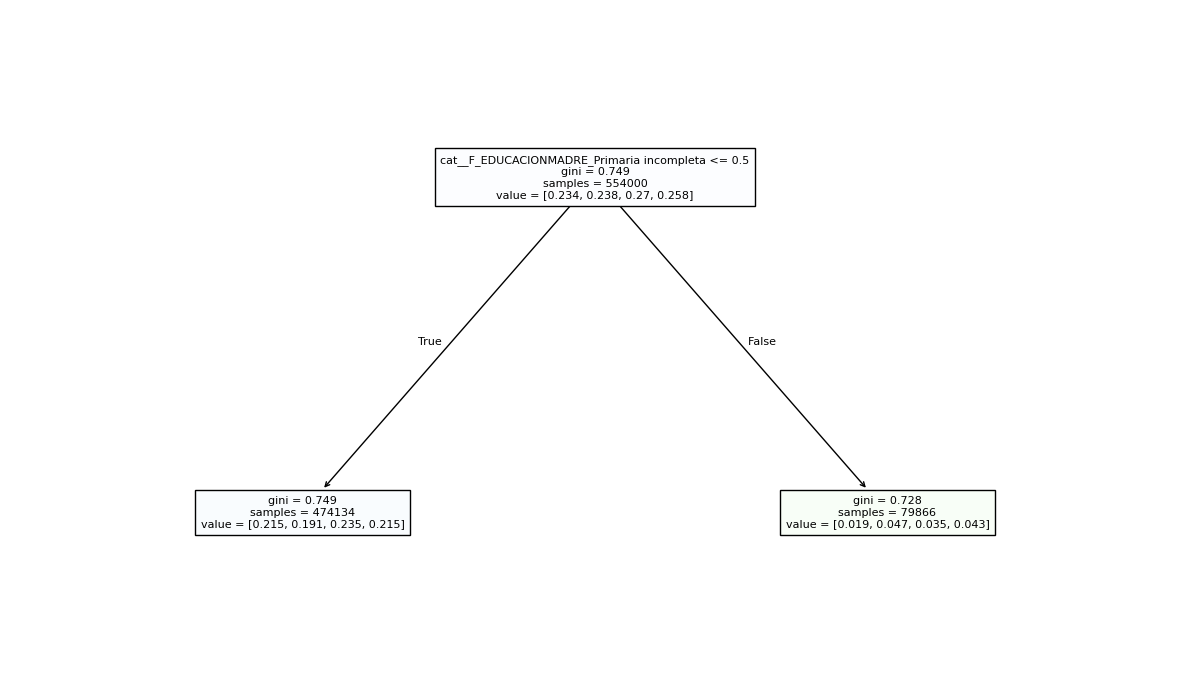

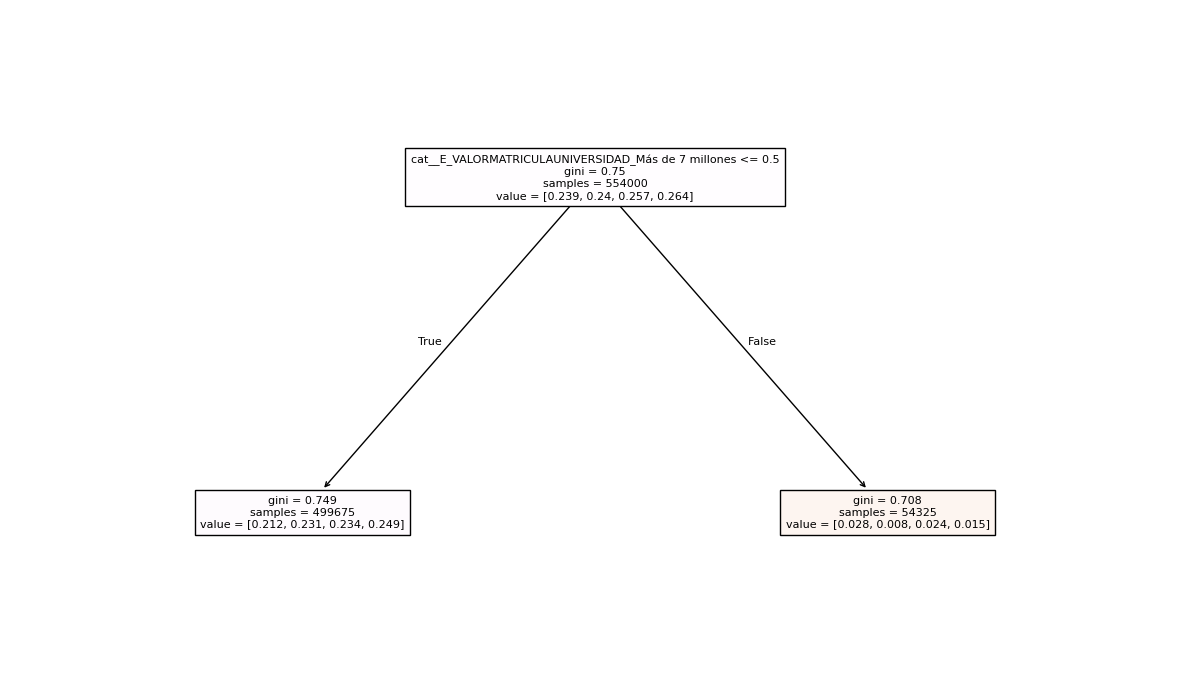

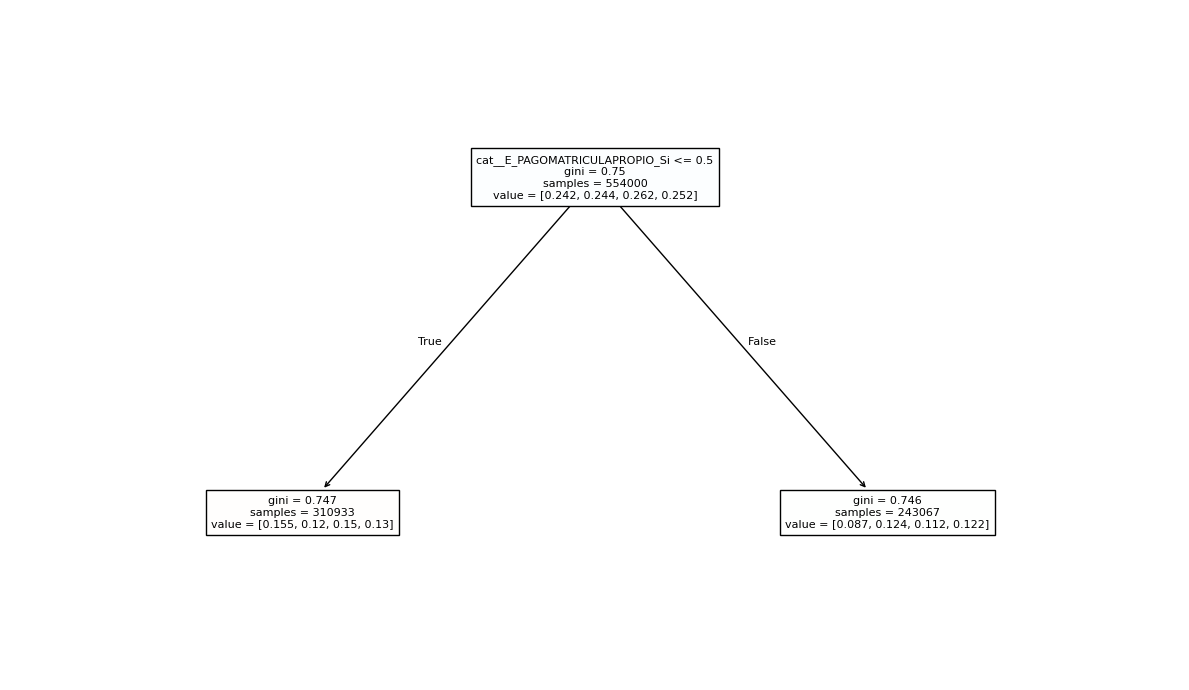

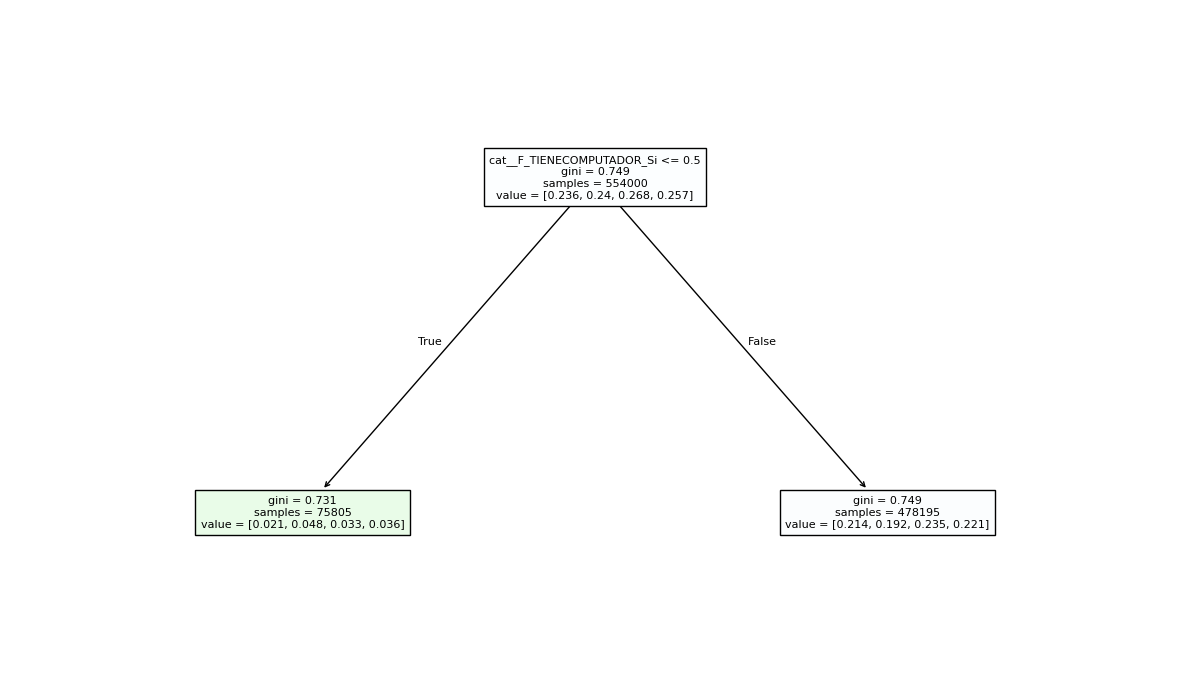

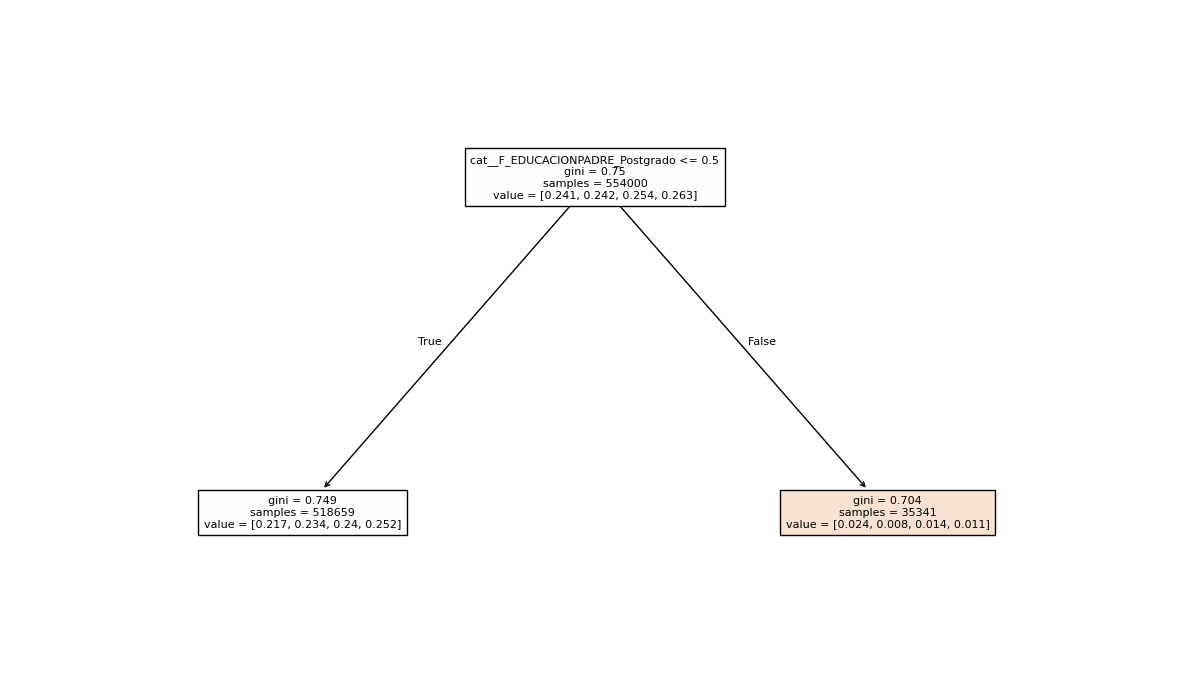

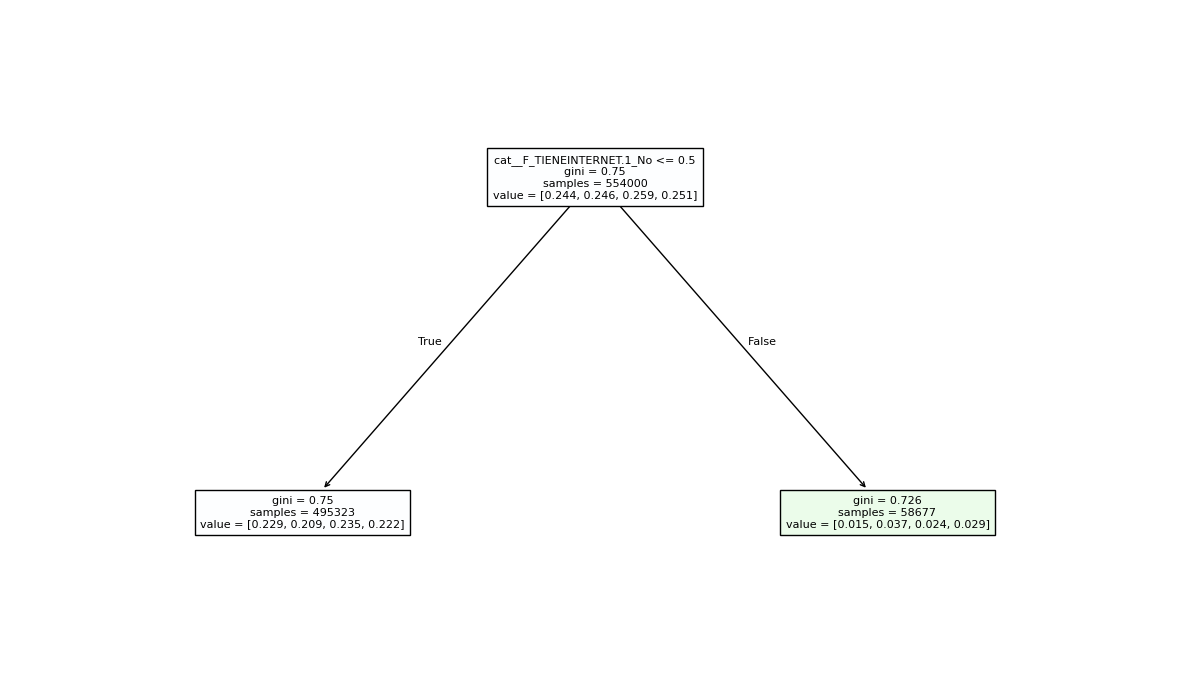

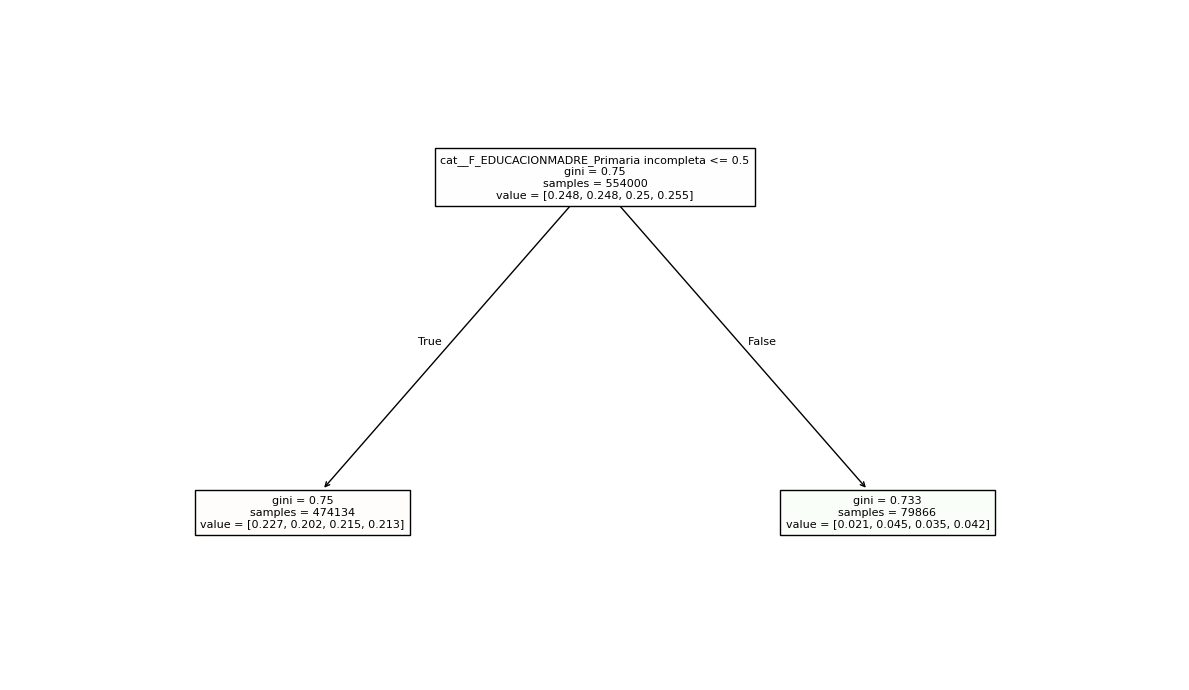

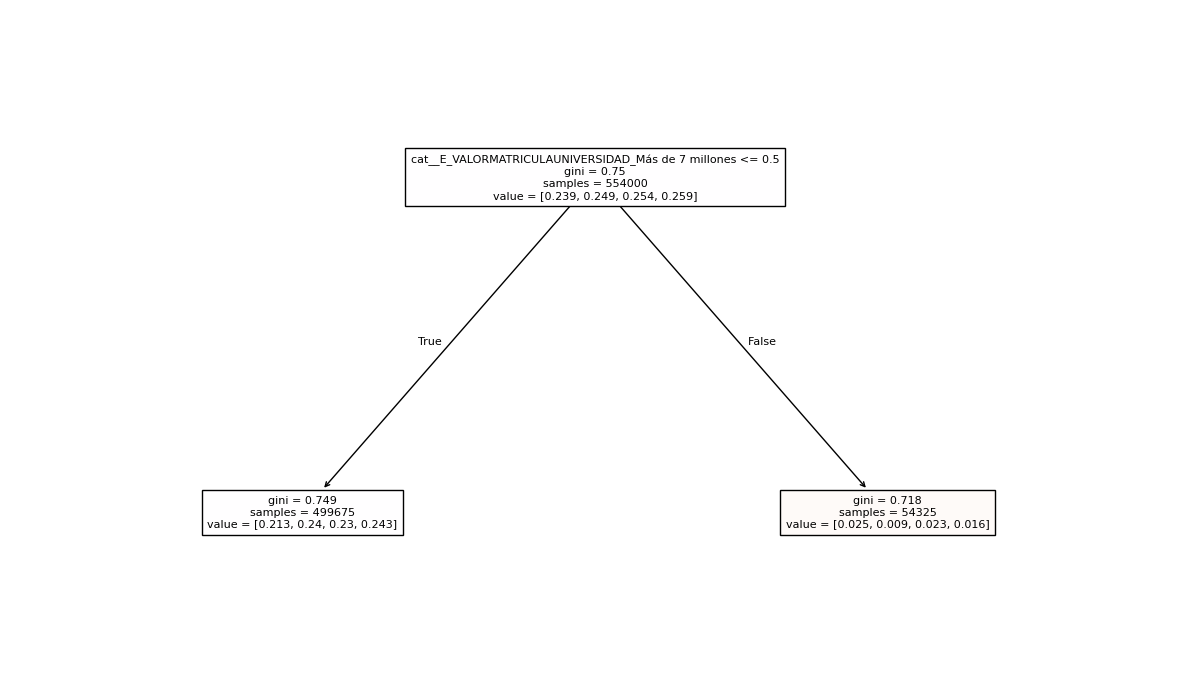

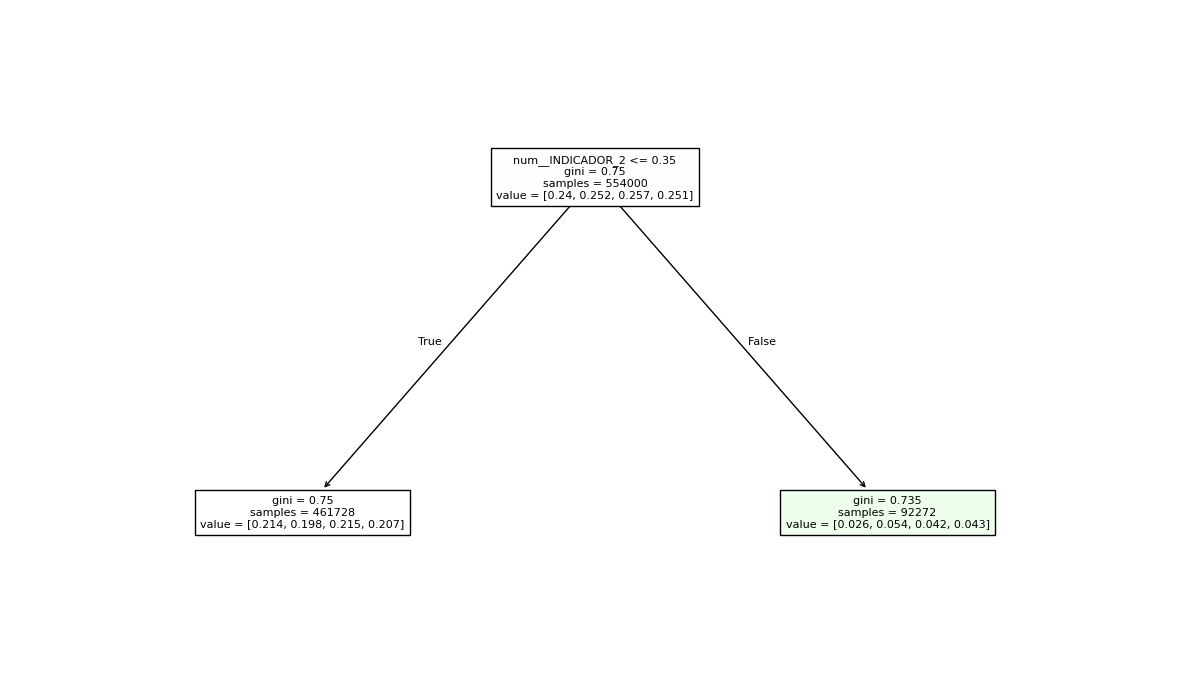

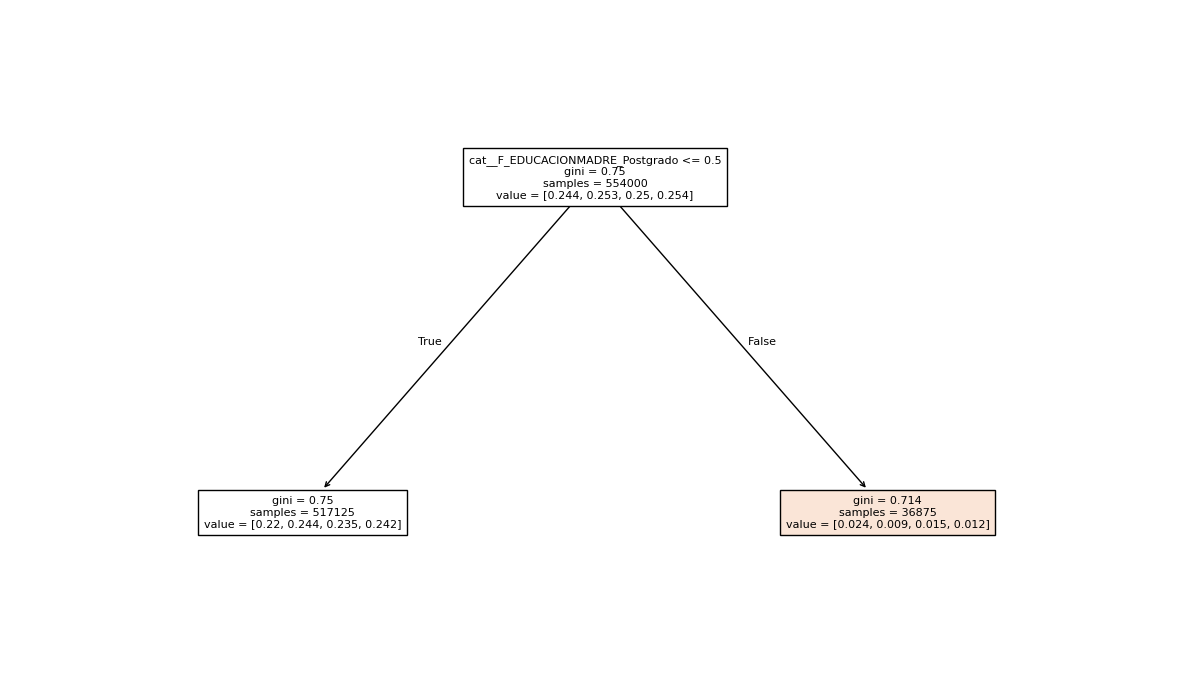

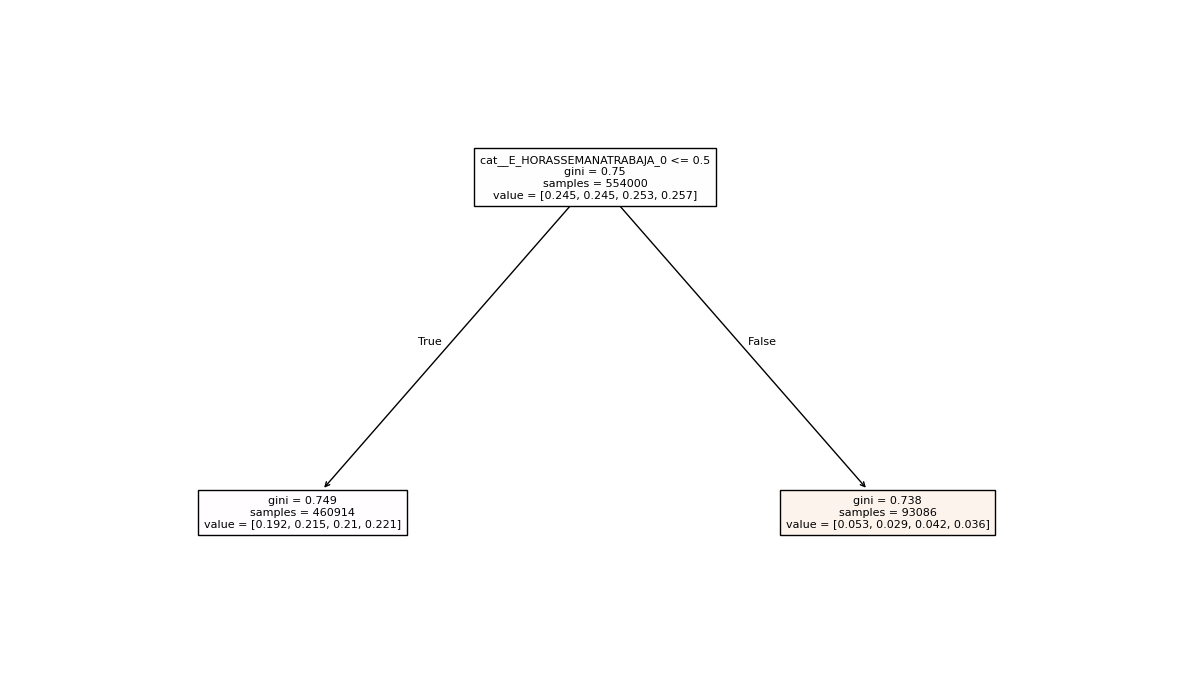

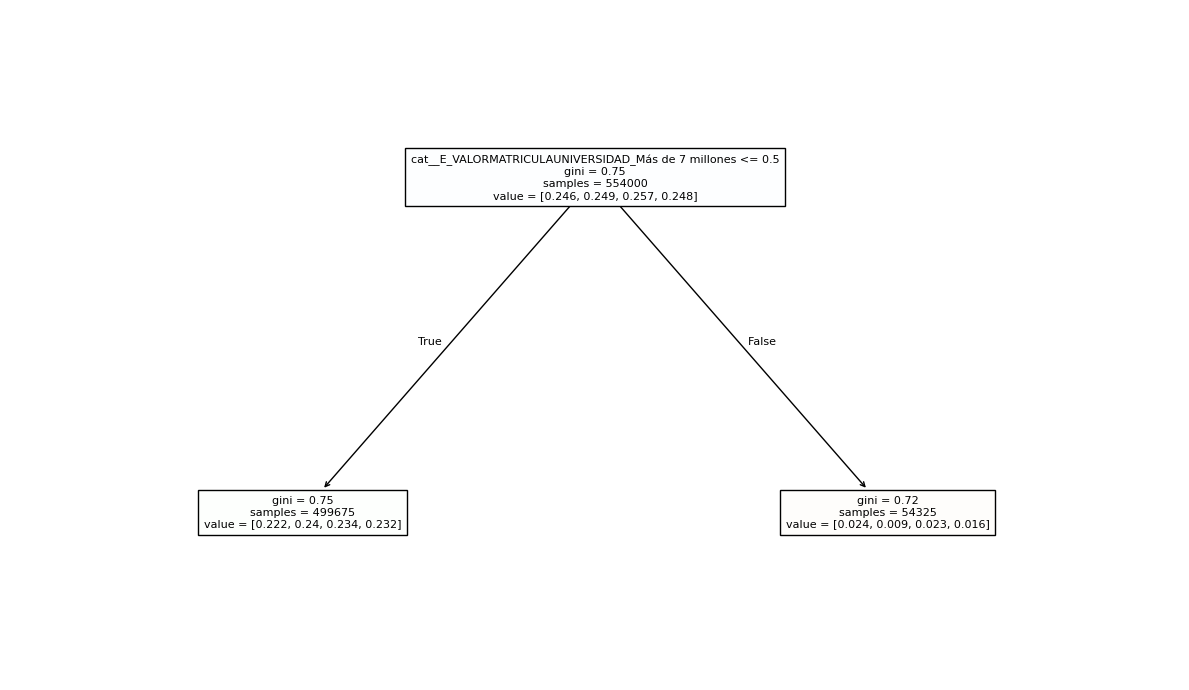

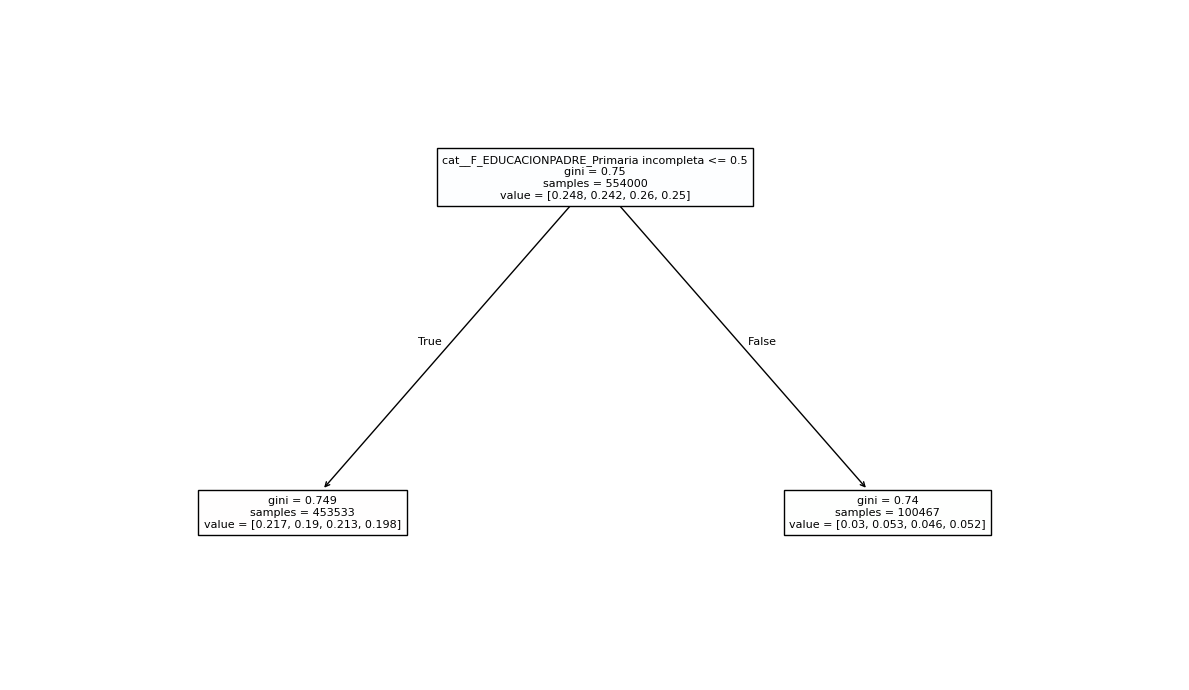

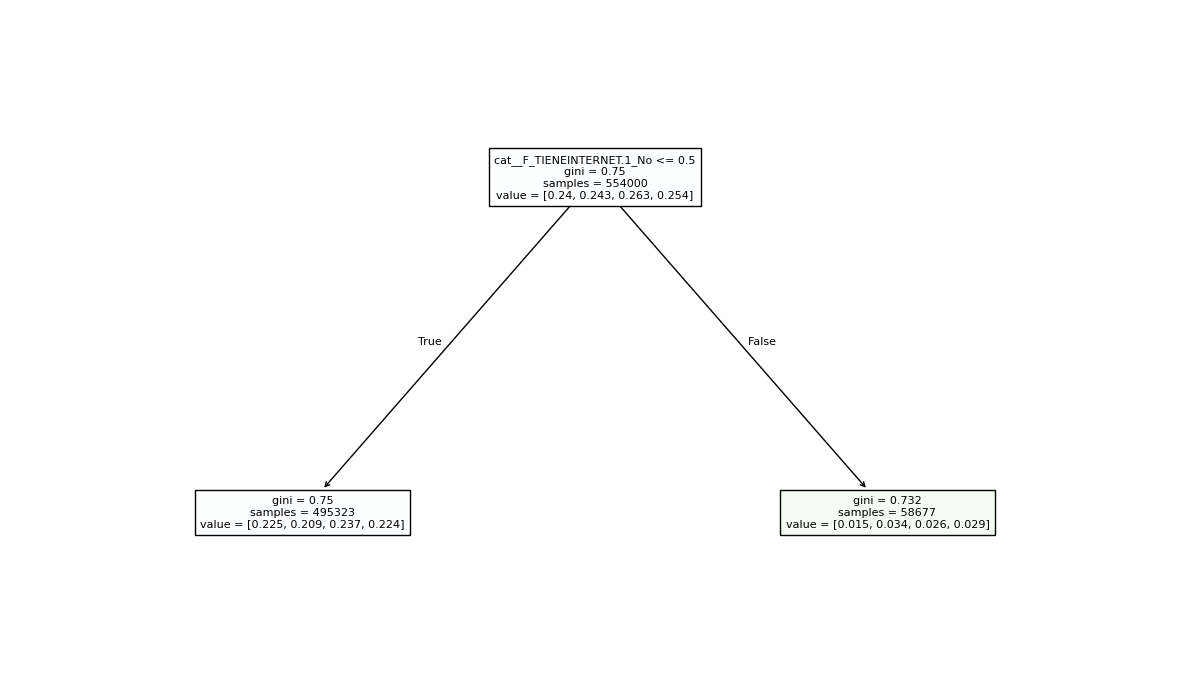

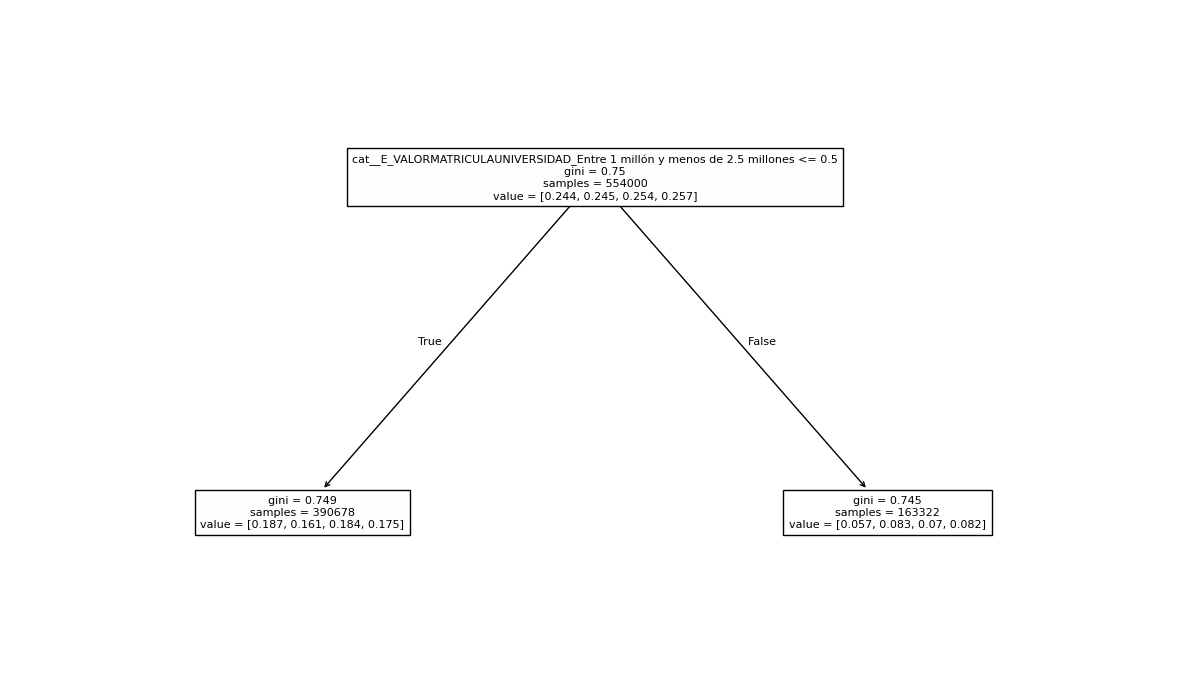

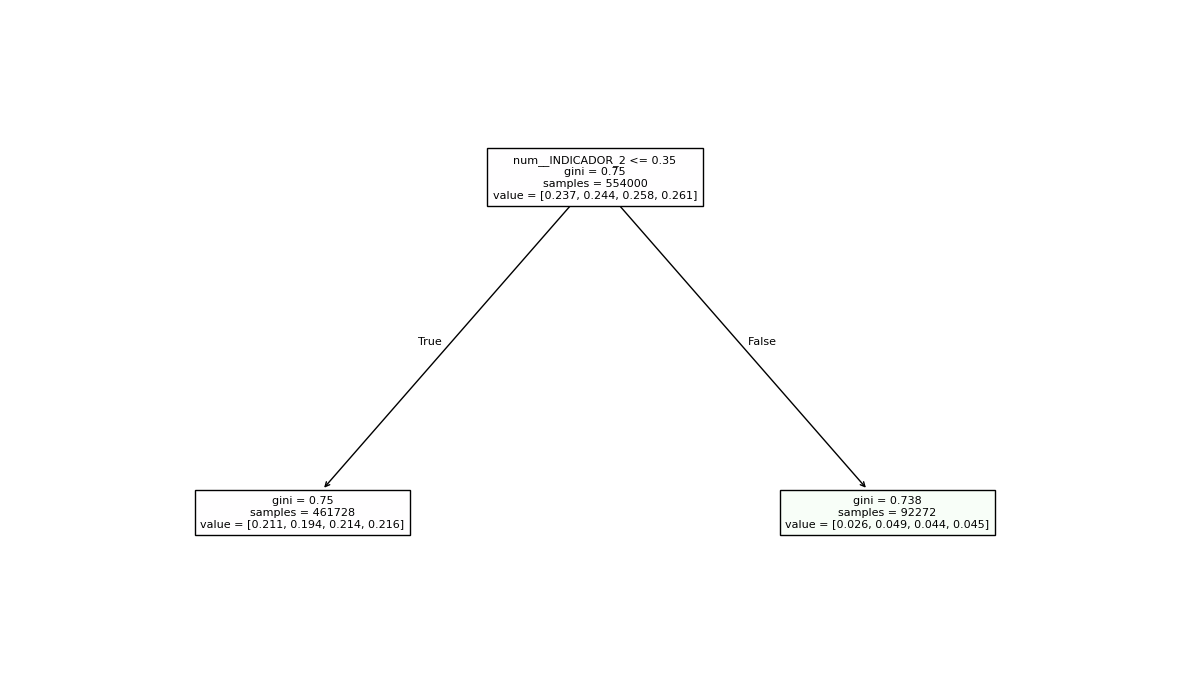

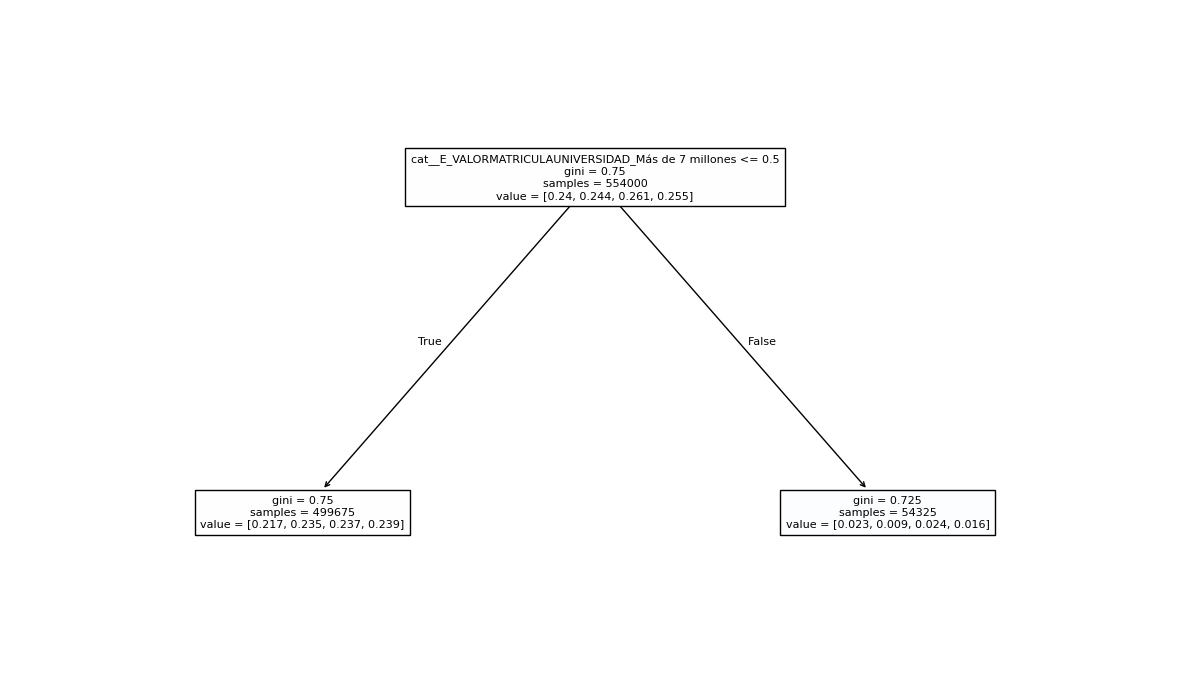

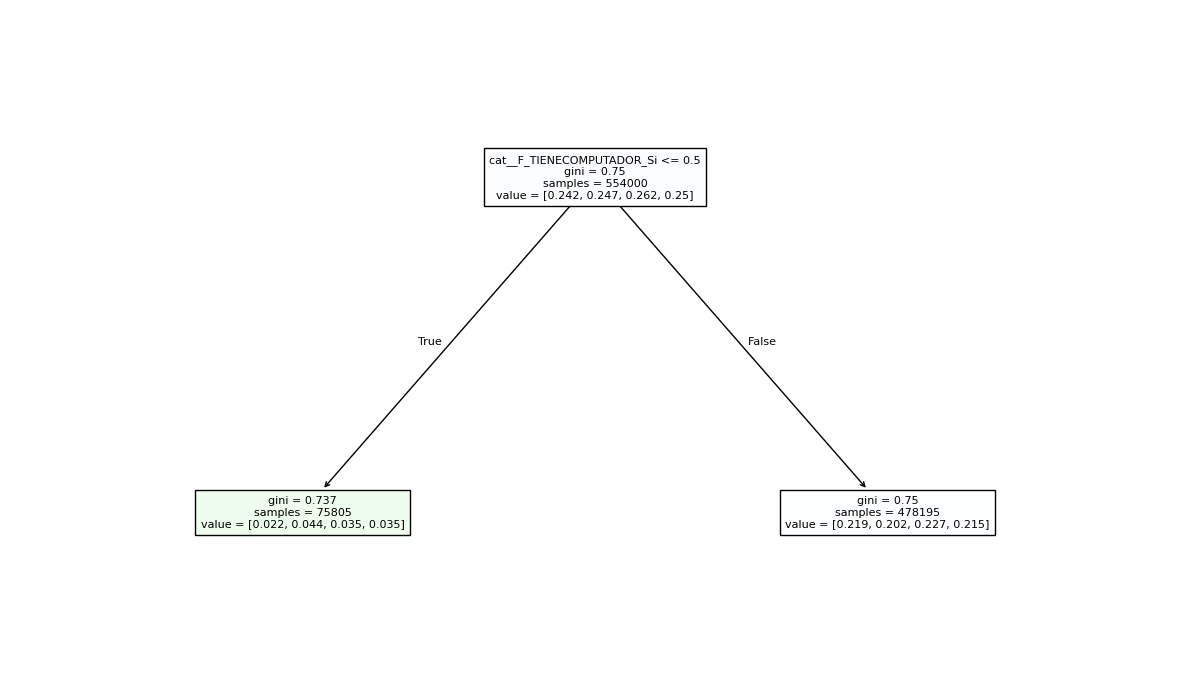

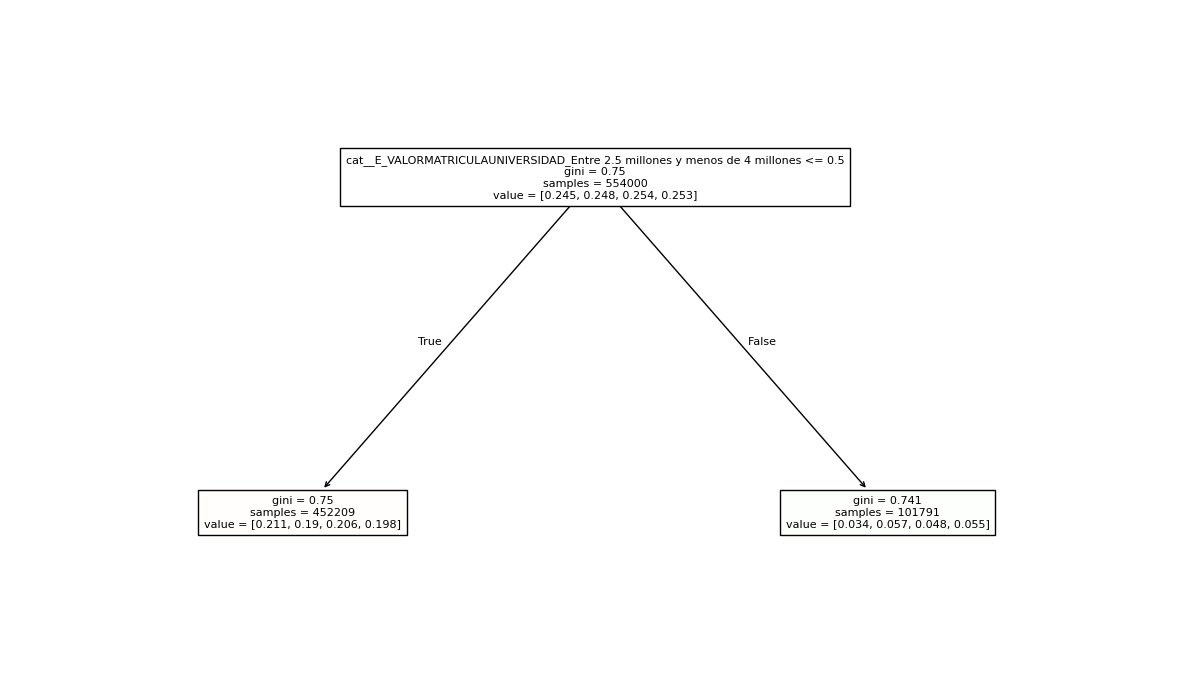

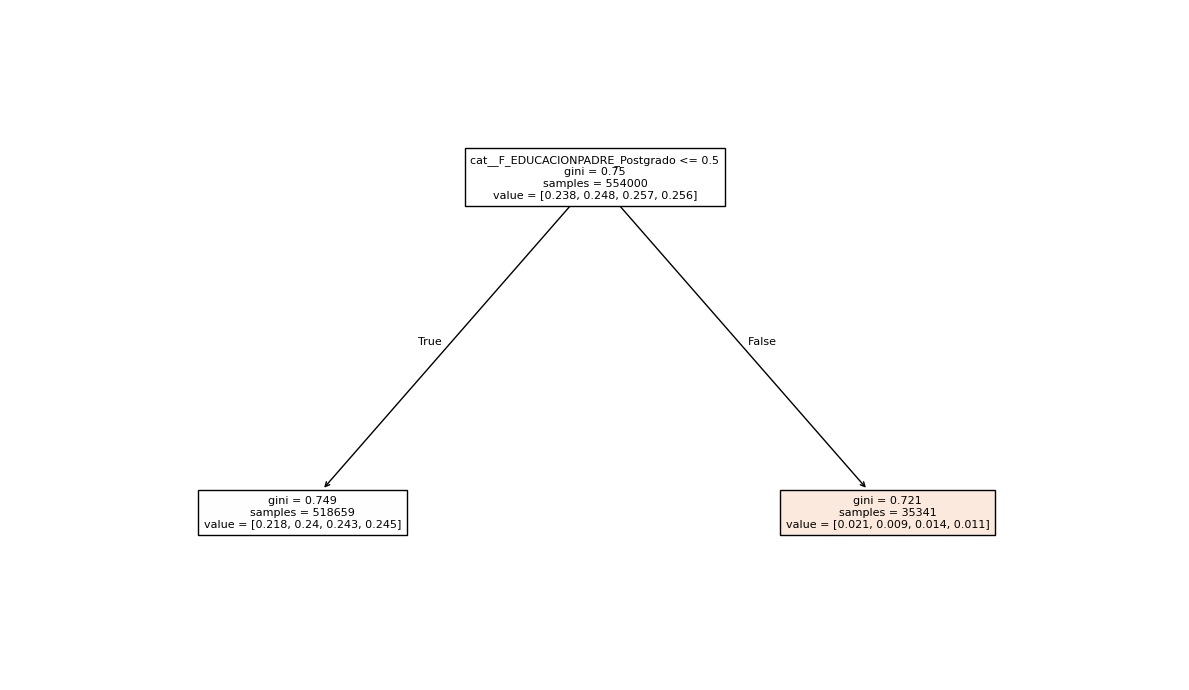

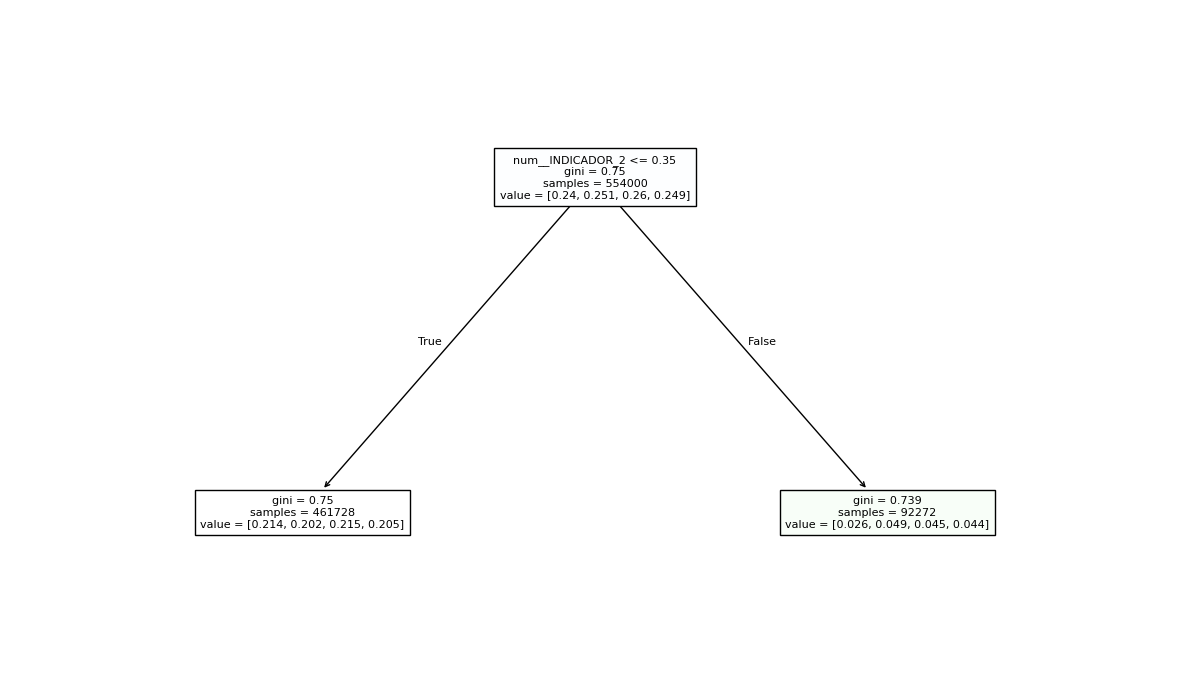

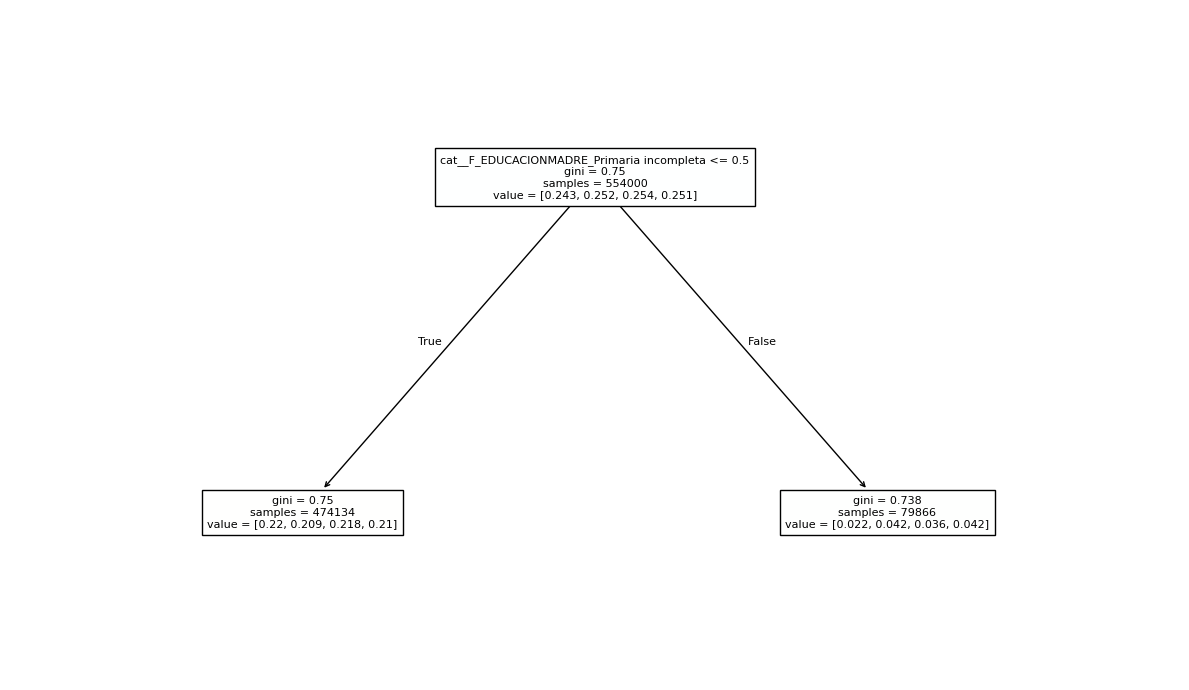

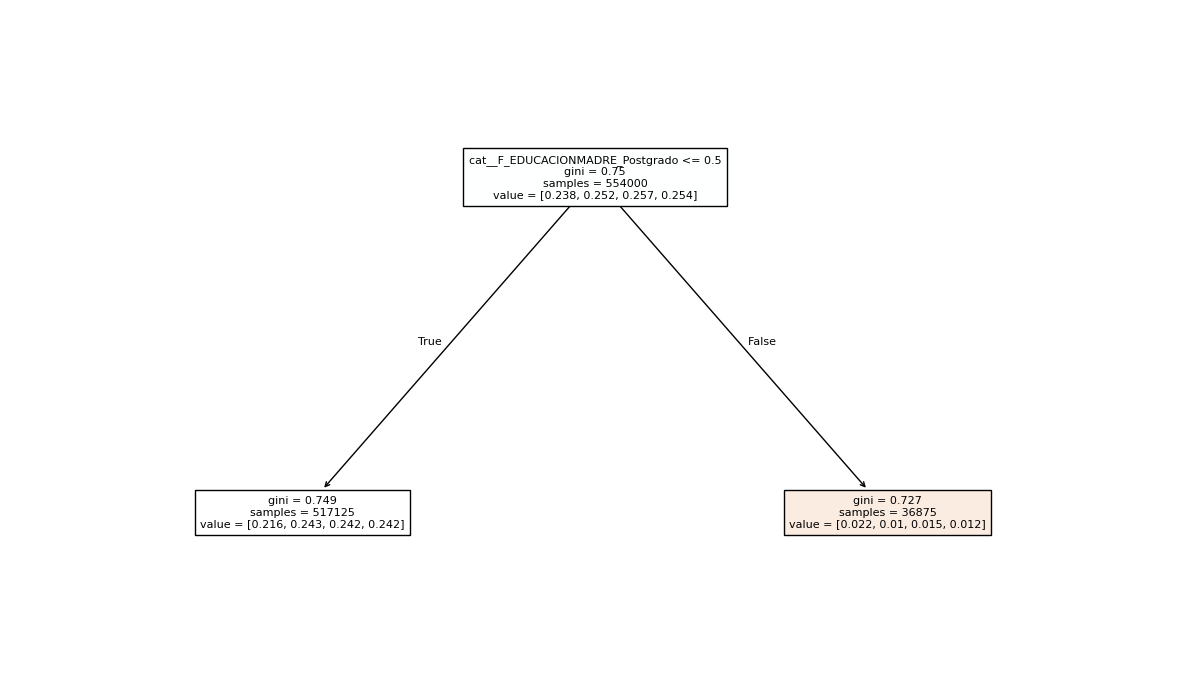

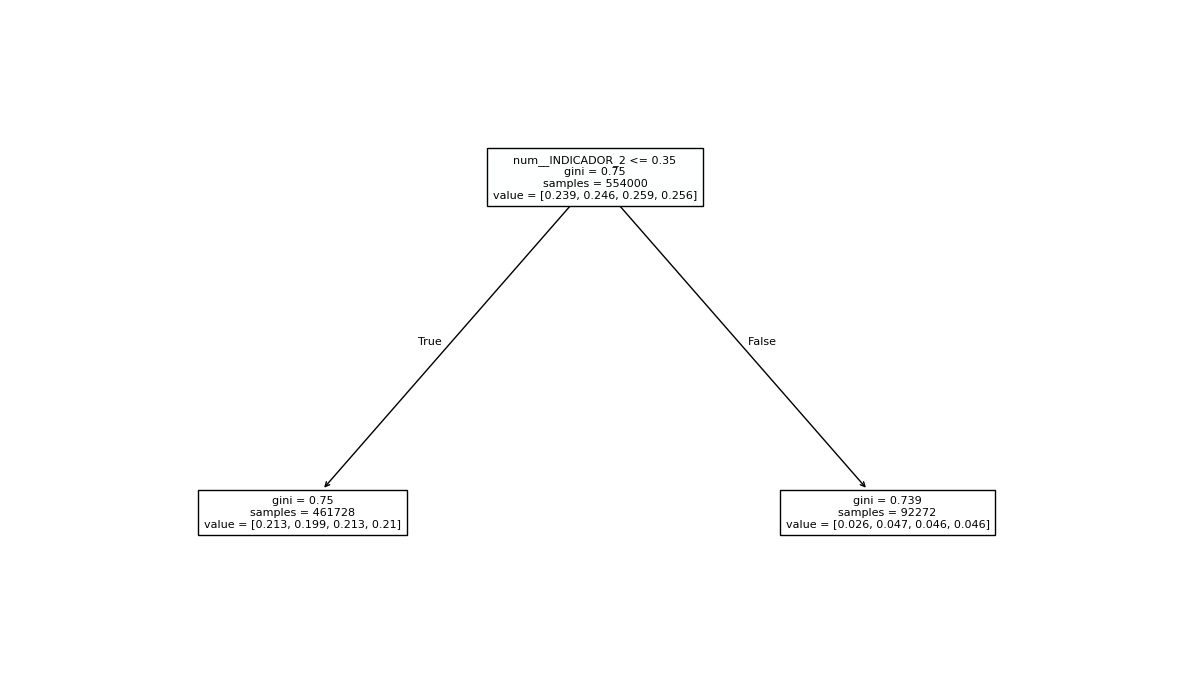

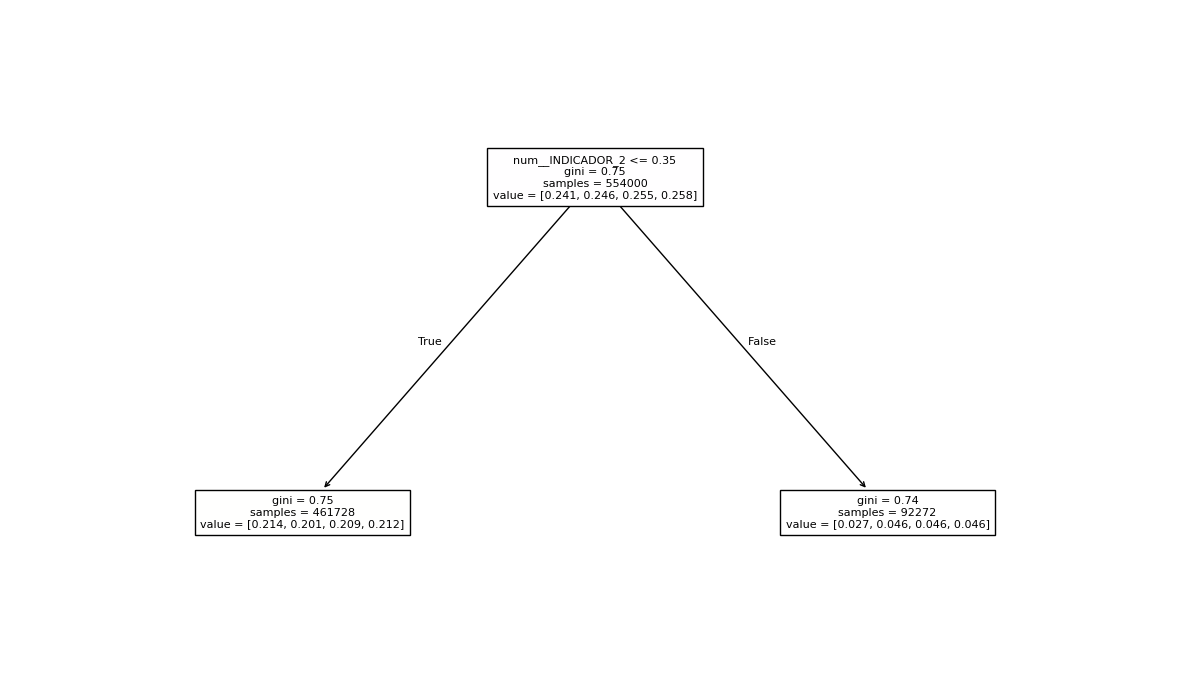

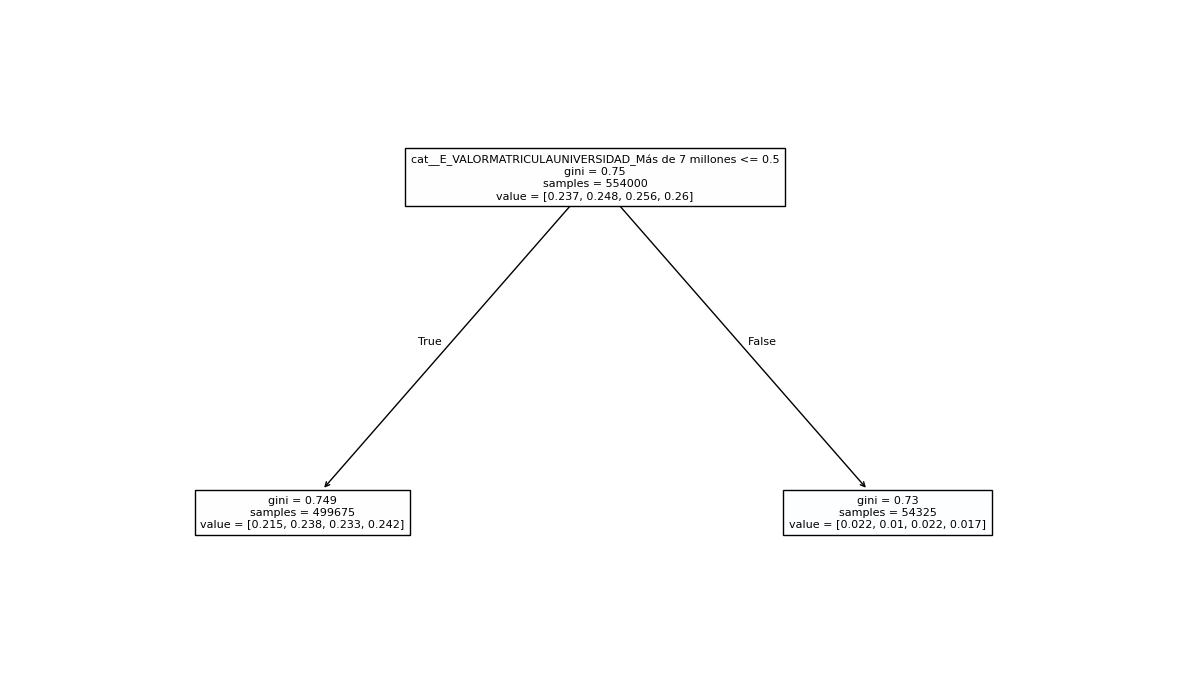

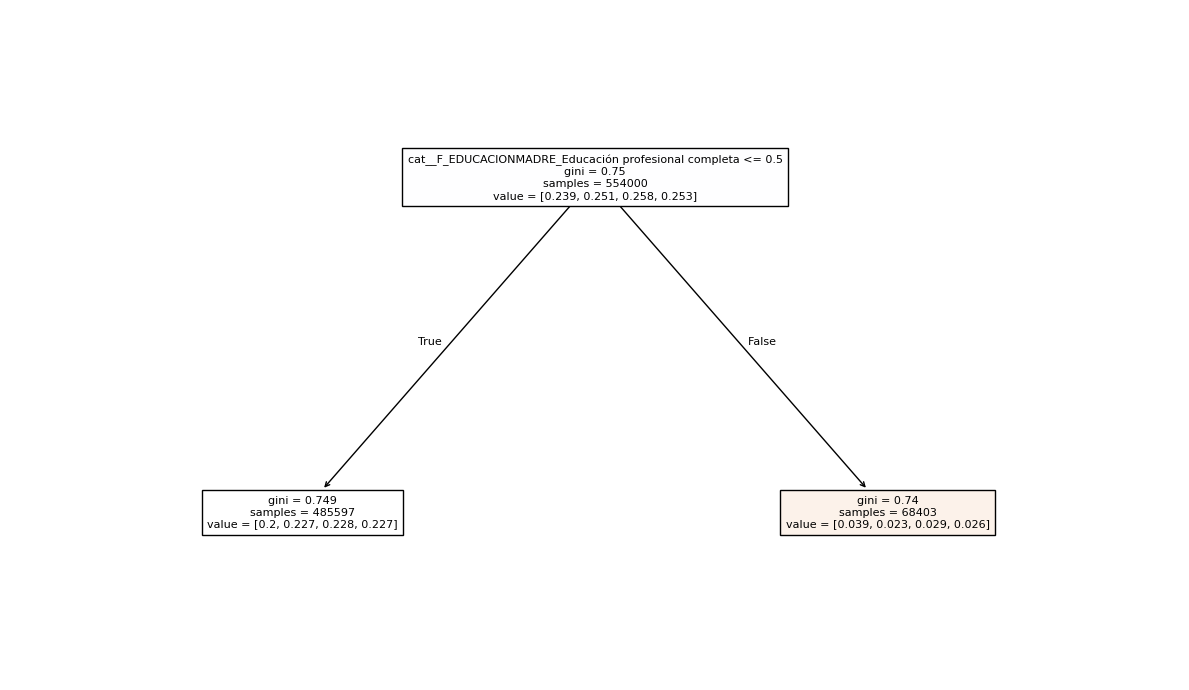

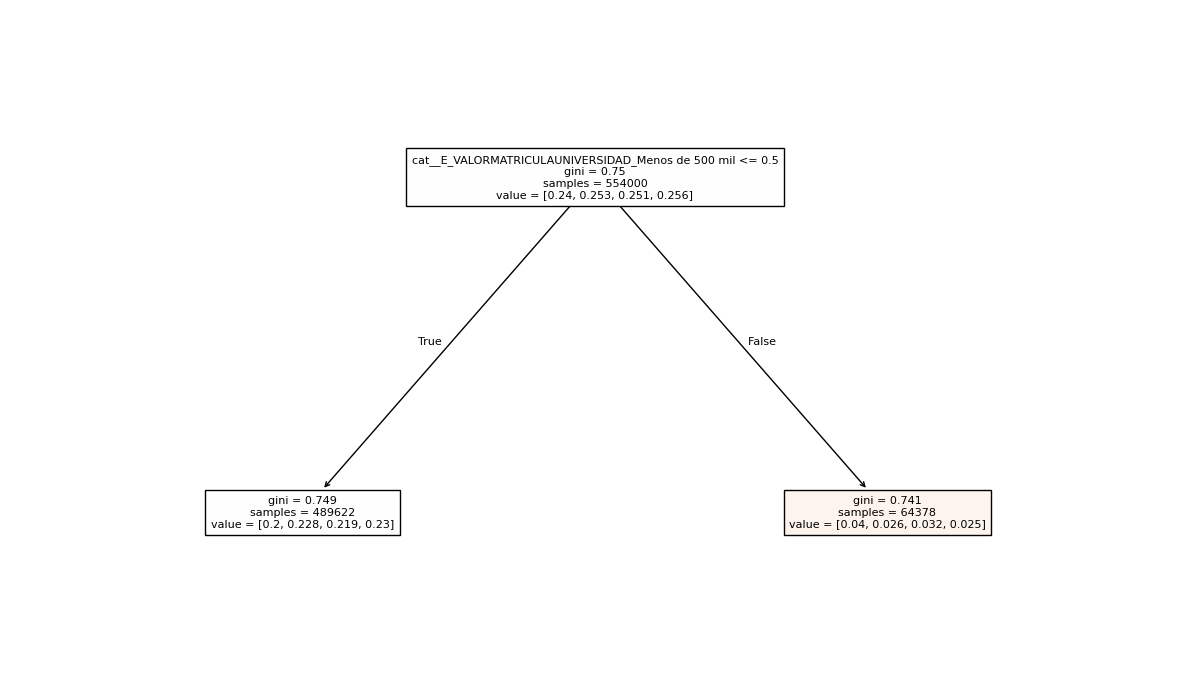

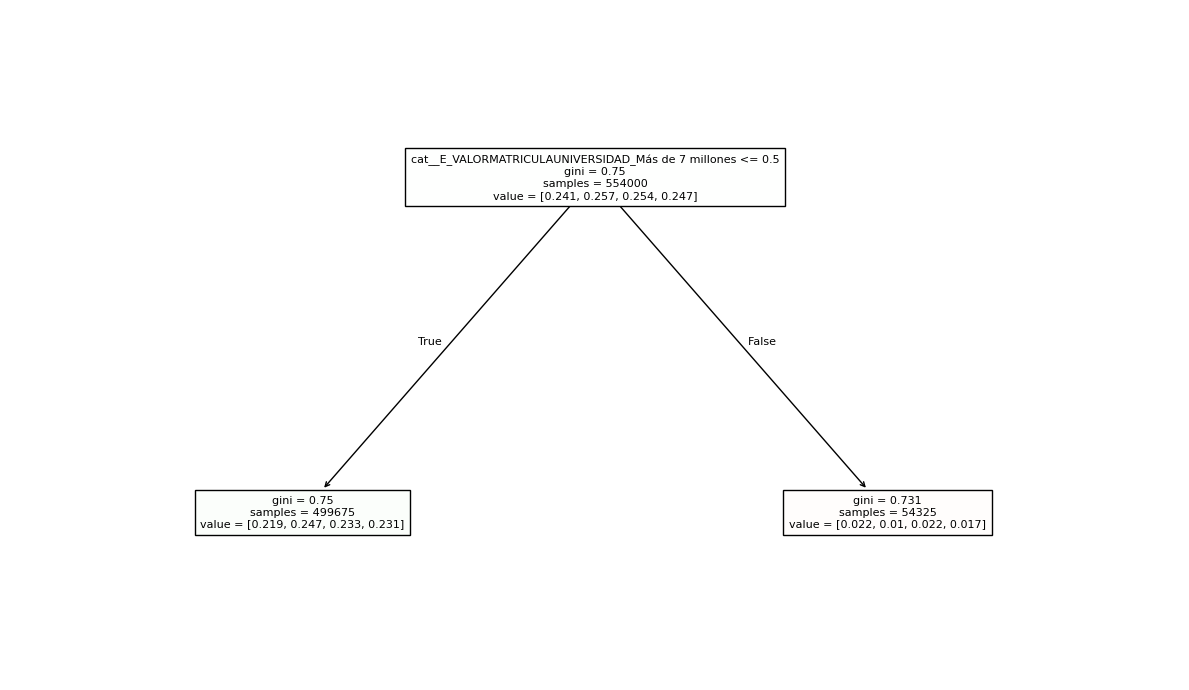

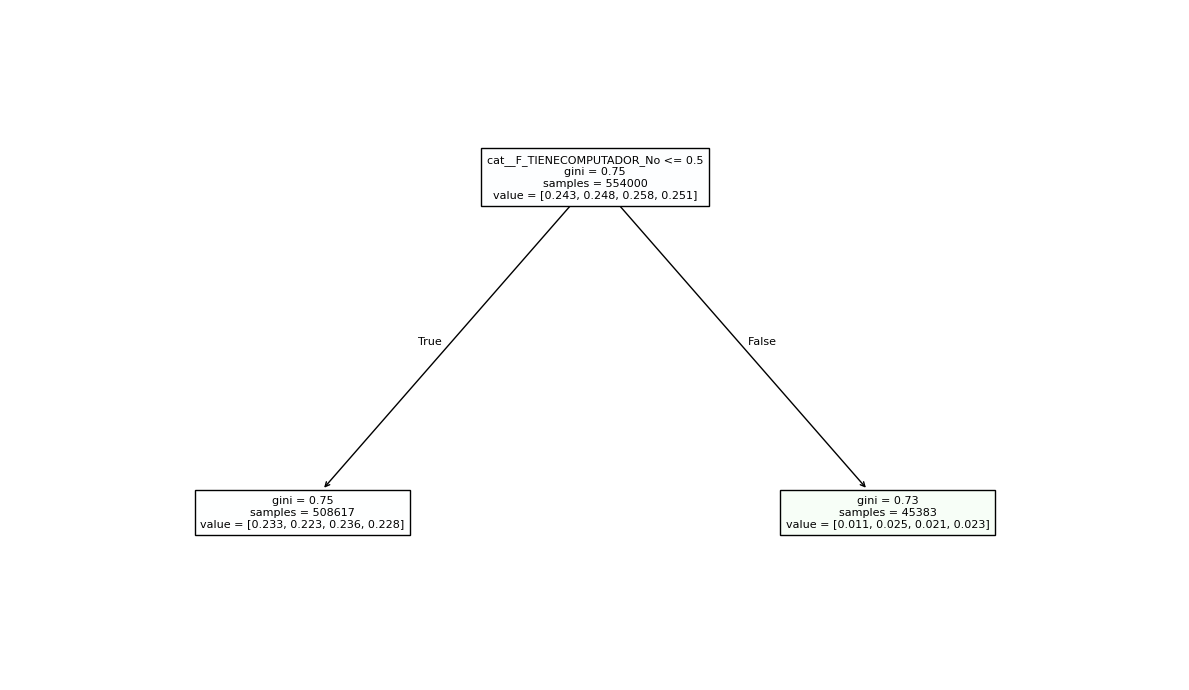

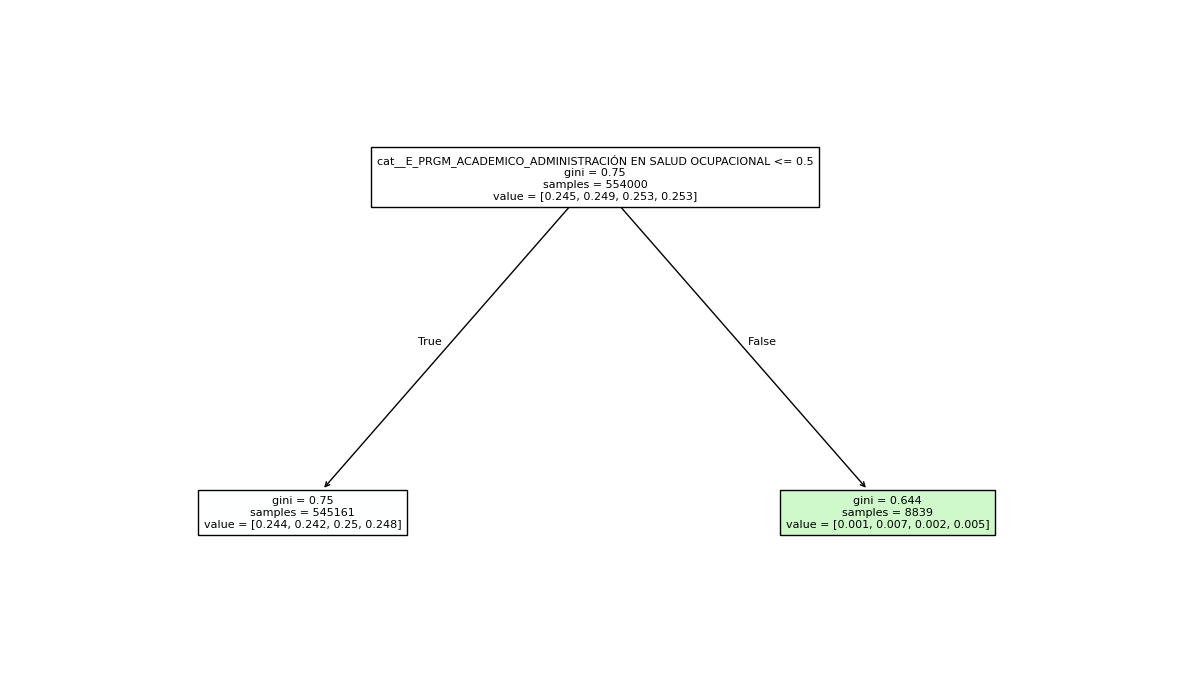

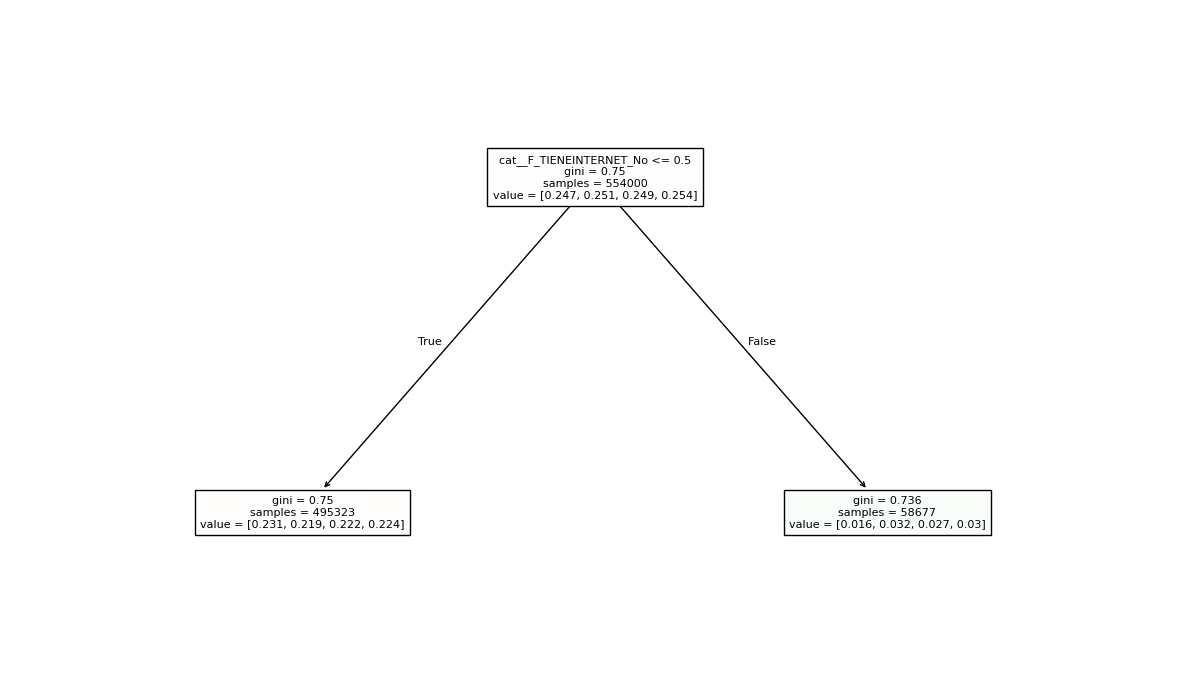

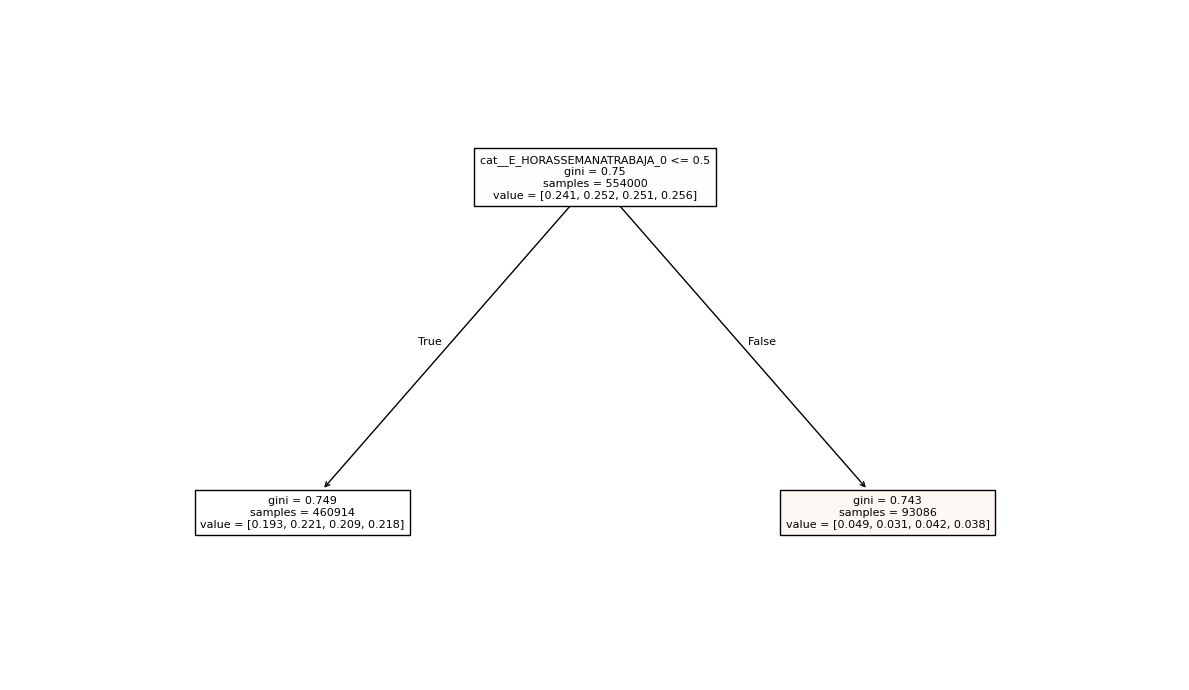

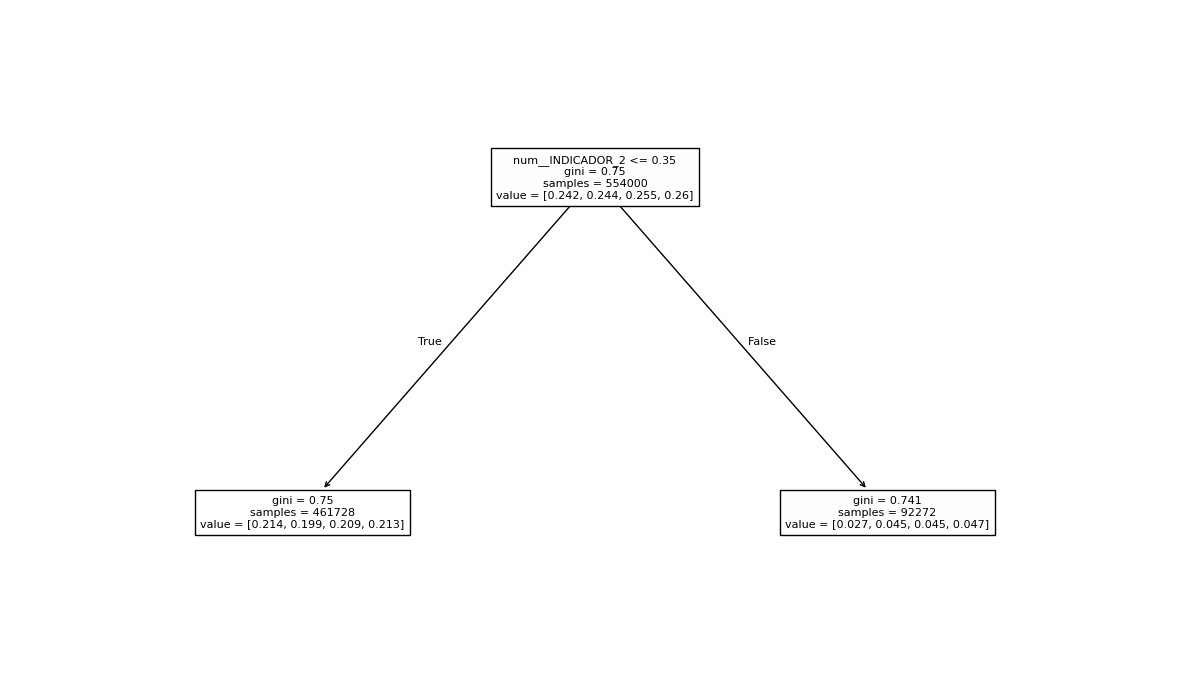

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

ada = pipe.named_steps["clf"]                 # AdaBoost ya entrenado
feat_names = pipe.named_steps["pre"].get_feature_names_out()

for i, stump in enumerate(ada.estimators_[:50], start=1):
    plt.figure(figsize=(12, 7))
    plt.title(f'Árbol de decisión {i}')
    plot_tree(stump, feature_names=feat_names, filled=True, max_depth=2, fontsize=8)
    plt.tight_layout(); plt.show(); plt.close()

In [16]:
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

z = pd.read_csv("train.csv")
y_raw = z["RENDIMIENTO_GLOBAL"]
X_raw = z.drop(columns=["ID","RENDIMIENTO_GLOBAL"], errors="ignore")

# y → numérica si es texto
le_y = None
if not np.issubdtype(y_raw.dtype, np.number):
    le_y = LabelEncoder().fit(y_raw.astype(str).str.strip())
    y = le_y.transform(y_raw.astype(str).str.strip())
else:
    y = y_raw.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)

num_sel = selector(dtype_include=np.number)
cat_sel = selector(dtype_exclude=np.number)

pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_sel),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))  # sparse por defecto
    ]), cat_sel)
], remainder="drop")

# Ejemplo de uso con AdaBoost (o el modelo que quieras)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.pipeline import Pipeline

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=200, learning_rate=0.5, algorithm="SAMME", random_state=42
)

pipe = Pipeline([("pre", pre), ("clf", ada)]).fit(X_train, y_train)

# Árboles:
first_tree = pipe.named_steps["clf"].estimators_[0]
feat_names = pipe.named_steps["pre"].get_feature_names_out()

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Se reduce el tamaño de los datos, se definen los 2 algoritmos predictivos y los parámetros a encontrar, se realiza la búsqueda y se imprimen los mejores hiperparámetros de cada algoritmo.

In [20]:
import numpy as np, pandas as pd, tempfile
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.experimental import enable_hist_gradient_boosting  # no-op si ya está
from sklearn.ensemble import HistGradientBoostingClassifier
from scipy.stats import randint, uniform

# 1) Carga
z = pd.read_csv("train.csv")
y_raw = z["RENDIMIENTO_GLOBAL"]
X_raw = z.drop(columns=["ID","RENDIMIENTO_GLOBAL"], errors="ignore")

# 2) y numérica (guardamos labels si quieres mostrarlos luego)
if not np.issubdtype(y_raw.dtype, np.number):
    le_y = LabelEncoder().fit(y_raw.astype(str).str.strip())
    y = le_y.transform(y_raw.astype(str).str.strip())
else:
    le_y = None
    y = y_raw.to_numpy()

# 3) Prepro ligero (Ordinal: rápido y RAM-friendly)
num_sel = selector(dtype_include=np.number)
cat_sel = selector(dtype_exclude=np.number)
pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_sel),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]), cat_sel)
], remainder="drop")

# 4) Submuestra estratificada (ajusta N_TARGET a tu RAM)
N_TARGET = min(50_000, len(X_raw))
sss = StratifiedShuffleSplit(n_splits=1, train_size=N_TARGET, random_state=42)
idx, _ = next(sss.split(X_raw, y))
X_small = X_raw.iloc[idx]
y_small = y[idx]

# 5) Cache del pipeline (evita recalcular transformaciones en cada fold)
cachedir = tempfile.mkdtemp()

# 6) Modelos + espacios de búsqueda (compactos)
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_space = {
    "clf__n_estimators": randint(80, 201),
    "clf__max_depth": randint(6, 21),
    "clf__min_samples_leaf": randint(1, 6),
    "clf__max_features": ["sqrt"]
}

hgb = HistGradientBoostingClassifier(random_state=42)  # mucho más rápido que GBC
hgb_space = {
    "clf__learning_rate": uniform(0.03, 0.12),   # ~0.03–0.15
    "clf__max_depth": randint(3, 13),
    "clf__max_leaf_nodes": randint(16, 64),
    "clf__l2_regularization": uniform(0.0, 1.0)
}

candidates = {
    "Random Forest": (rf, rf_space, 20),   # n_iter: sube/baja según prisa
    "HistGB":        (hgb, hgb_space, 20),
}

# 7) RandomizedSearchCV rápido (cv=2, n_jobs=-1)
for name, (est, space, n_iter) in candidates.items():
    pipe = Pipeline([("pre", pre), ("clf", est)], memory=cachedir)
    rs = RandomizedSearchCV(
        pipe, space, n_iter=n_iter, cv=2, n_jobs=-1,
        verbose=1, random_state=42
    )
    rs.fit(X_small, y_small)
    print(f"\n{name}")
    print("Mejores hiperparámetros:", rs.best_params_)
    print("Mejor accuracy (CV):   ", round(rs.best_score_, 4))

/usr/local/lib/python3.12/dist-packages/sklearn/experimental/enable_hist_gradient_boosting.py:19: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


Fitting 2 folds for each of 20 candidates, totalling 40 fits

Random Forest
Mejores hiperparámetros: {'clf__max_depth': 17, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 112}
Mejor accuracy (CV):    0.3943
Fitting 2 folds for each of 20 candidates, totalling 40 fits

HistGB
Mejores hiperparámetros: {'clf__l2_regularization': np.float64(0.7722447692966574), 'clf__learning_rate': np.float64(0.053845881784100685), 'clf__max_depth': 10, 'clf__max_leaf_nodes': 26}
Mejor accuracy (CV):    0.4081


Se reduce el tamaño de los datos mediante división en conjuntos de entrenamiento y prueba, se definen los algoritmos predictivos con mejores hiperparámetros encontrados en la celda anterior, se realizan las curvas de aprendizaje de los 2 algoritmos y se grafican las curvas.

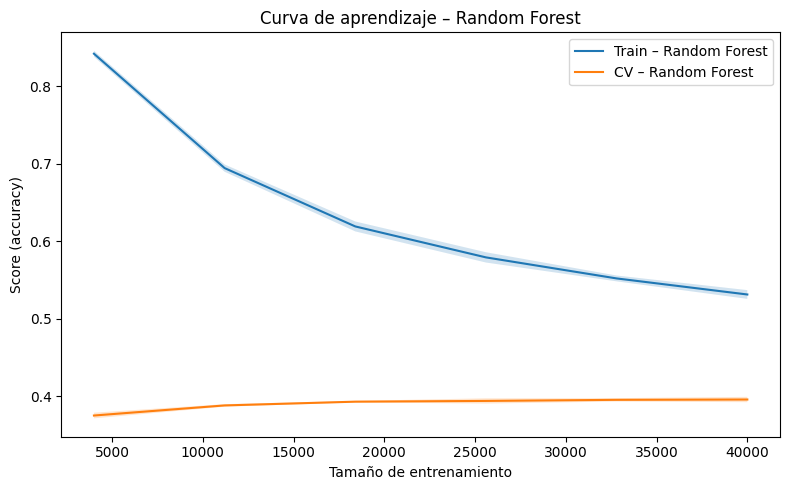

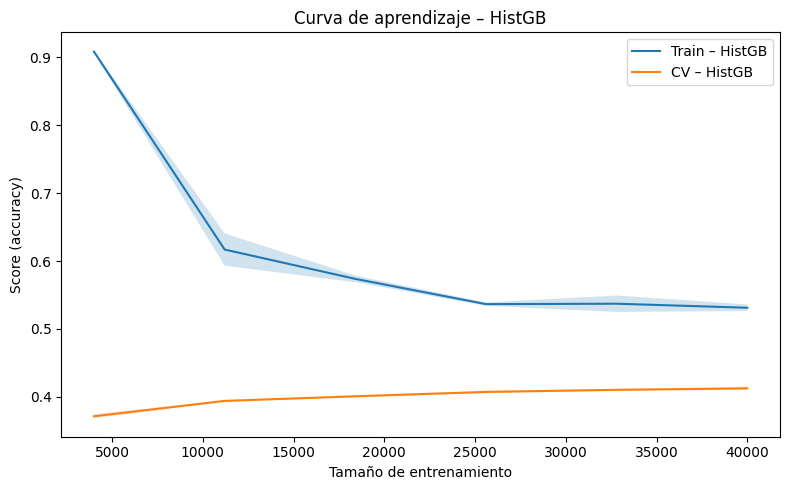

In [22]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, tempfile
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, learning_curve
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# 1) Carga y target
z = pd.read_csv("train.csv")
y_raw = z["RENDIMIENTO_GLOBAL"]
X_raw = z.drop(columns=["ID","RENDIMIENTO_GLOBAL"], errors="ignore")

# y numérica (guardamos encoder por si luego quieres labels bonitos)
if not np.issubdtype(y_raw.dtype, np.number):
    le_y = LabelEncoder().fit(y_raw.astype(str).str.strip())
    y = le_y.transform(y_raw.astype(str).str.strip())
else:
    le_y = None
    y = y_raw.to_numpy()

# 2) Preprocesamiento consistente y ligero (OrdinalEncoder ≈ turbo)
num_sel = selector(dtype_include=np.number)
cat_sel = selector(dtype_exclude=np.number)
pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_sel),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]), cat_sel)
], remainder="drop")

# 3) Submuestra estratificada para acelerar (ajusta N_TARGET si hace falta)
N_TARGET = min(60_000, len(X_raw))
sss = StratifiedShuffleSplit(n_splits=1, train_size=N_TARGET, random_state=42)
idx, _ = next(sss.split(X_raw, y))
X_small = X_raw.iloc[idx]
y_small = y[idx]

# 4) Modelos con mejores ranges “sanos”
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=150, max_depth=10, min_samples_leaf=2, max_features="sqrt",
        random_state=42, n_jobs=-1
    ),
    "HistGB": HistGradientBoostingClassifier(
        learning_rate=0.08, max_depth=8, max_leaf_nodes=31, l2_regularization=0.1,
        random_state=42
    ),
}

# 5) Curvas de aprendizaje (cv estratificado, cache para no recalcular prepro)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 6)
cachedir = tempfile.mkdtemp()

for name, clf in models.items():
    pipe = Pipeline([("pre", pre), ("clf", clf)], memory=cachedir)
    ts, tr_scores, te_scores = learning_curve(
        pipe, X_small, y_small,
        train_sizes=train_sizes, cv=cv, n_jobs=-1, shuffle=True, random_state=42
    )
    tr_mean, tr_std = tr_scores.mean(axis=1), tr_scores.std(axis=1)
    te_mean, te_std = te_scores.mean(axis=1), te_scores.std(axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(ts, tr_mean, label=f"Train – {name}")
    plt.fill_between(ts, tr_mean-tr_std, tr_mean+tr_std, alpha=0.2)
    plt.plot(ts, te_mean, label=f"CV – {name}")
    plt.fill_between(ts, te_mean-te_std, te_mean+te_std, alpha=0.2)
    plt.xlabel("Tamaño de entrenamiento"); plt.ylabel("Score (accuracy)")
    plt.title(f"Curva de aprendizaje – {name}")
    plt.legend(); plt.tight_layout(); plt.show()

Hiperparámetros para dos combinaciones de: algoritmo no supervisado + algoritmo predictivo

In [25]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe_pca_log = Pipeline([
    ("pre", pre),
    ("sc",  StandardScaler(with_mean=True)),
    ("pca", PCA(random_state=42)),
    ("clf", LogisticRegression(solver="saga", multi_class="multinomial", max_iter=300, n_jobs=-1))
], memory=cachedir)

space_pca_log = {
    # fracción de varianza explicada objetivo (sin pelearte con el nº de features)
    "pca__n_components": [0.80, 0.90, 0.95, 0.99],
    "clf__penalty": ["elasticnet"],
    "clf__C": uniform(0.2, 2.0),
    "clf__l1_ratio": uniform(0.0, 1.0),
}

rs_pca_log = RandomizedSearchCV(
    pipe_pca_log, space_pca_log, n_iter=20, cv=2,
    n_jobs=-1, verbose=1, random_state=42
)
rs_pca_log.fit(X_small, y_small)
print("\n[Combo B] PCA -> LogisticRegression")
print("Mejores hiperparámetros:", rs_pca_log.best_params_)
print("Mejor accuracy (CV):    ", round(rs_pca_log.best_score_, 4))

Fitting 2 folds for each of 20 candidates, totalling 40 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



[Combo B] PCA -> LogisticRegression
Mejores hiperparámetros: {'clf__C': np.float64(0.8674172222780436), 'clf__l1_ratio': np.float64(0.14286681792194078), 'clf__penalty': 'elasticnet', 'pca__n_components': 0.95}
Mejor accuracy (CV):     0.3766


Se define el modelo de PCA y Logistic Regression como un pipeline, se calculan las curvas de aprendizaje, se calculan las medias y desviaciones estándar de los puntajes y finalmente se grafica la curva de aprendizaje.

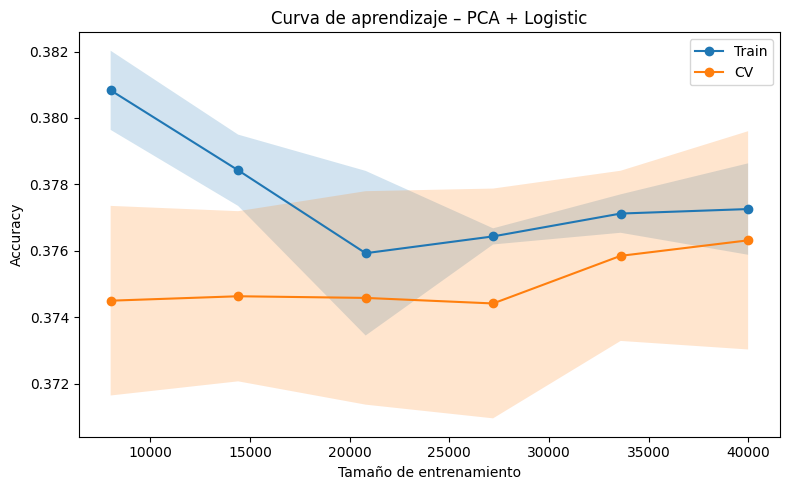

Max gap (overfitting): 0.0063
Promedio CV: 0.3751


In [28]:
# PCA + Logistic en Pipeline, con curva de aprendizaje

import numpy as np, pandas as pd, matplotlib.pyplot as plt, tempfile
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, learning_curve
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# 1) Carga
z = pd.read_csv("train.csv")
y_raw = z["RENDIMIENTO_GLOBAL"]
X_raw = z.drop(columns=["ID","RENDIMIENTO_GLOBAL"], errors="ignore")

# 2) y → numérico
if not np.issubdtype(y_raw.dtype, np.number):
    le_y = LabelEncoder().fit(y_raw.astype(str).str.strip())
    y = le_y.transform(y_raw.astype(str).str.strip())
else:
    le_y = None
    y = y_raw.to_numpy()

# 3) Preprocesamiento consistente (sin que “desaparezcan” columnas)
num_sel = selector(dtype_include=np.number)
cat_sel = selector(dtype_exclude=np.number)

pre = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value=-1))  # seguro incluso si toda la columna es NaN
    ]), num_sel),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]), cat_sel)
], remainder="drop")

# 4) Submuestra estratificada para acelerar la curva (ajusta N_TARGET si quieres)
N_TARGET = min(60_000, len(X_raw))
sss = StratifiedShuffleSplit(n_splits=1, train_size=N_TARGET, random_state=42)
idx, _ = next(sss.split(X_raw, y))
X_small = X_raw.iloc[idx]
y_small = y[idx]

# 5) Pipeline: Pre → Escalado → PCA(0.95 varianza) → Logistic multinomial
pipe = Pipeline([
    ("pre", pre),
    ("sc", StandardScaler(with_mean=True)),
    ("pca", PCA(n_components=0.95, random_state=42)),      # fracción de varianza ⇒ jamás fuera de rango
    ("clf", LogisticRegression(solver="saga", multi_class="multinomial",
                               max_iter=1000, n_jobs=-1, C=1.0, penalty="l2"))
], memory=tempfile.mkdtemp())

# 6) Curva de aprendizaje (cv=3 estratificado, tamaños moderados)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
train_sizes = np.linspace(0.2, 1.0, 6)

ts, tr_scores, te_scores = learning_curve(
    pipe, X_small, y_small,
    train_sizes=train_sizes, cv=cv, n_jobs=-1, shuffle=True, random_state=42
)

tr_mean, tr_std = tr_scores.mean(axis=1), tr_scores.std(axis=1)
te_mean, te_std = te_scores.mean(axis=1), te_scores.std(axis=1)

plt.figure(figsize=(8,5))
plt.plot(ts, tr_mean, "o-", label="Train")
plt.fill_between(ts, tr_mean-tr_std, tr_mean+tr_std, alpha=0.2)
plt.plot(ts, te_mean, "o-", label="CV")
plt.fill_between(ts, te_mean-te_std, te_mean+te_std, alpha=0.2)
plt.xlabel("Tamaño de entrenamiento"); plt.ylabel("Accuracy")
plt.title("Curva de aprendizaje – PCA + Logistic")
plt.legend(); plt.tight_layout(); plt.show()

gap = (tr_mean - te_mean).max()
print("Max gap (overfitting):", round(float(gap), 4))
print("Promedio CV:", round(float(te_mean.mean()), 4))

Ahora se utiliza PCA con SVC.

Accuracy holdout: 0.3841
Matriz de confusión:
 [[1702  423  500  418]
 [ 377 1435  407  779]
 [ 864  724  587  799]
 [ 587 1041  472  885]]


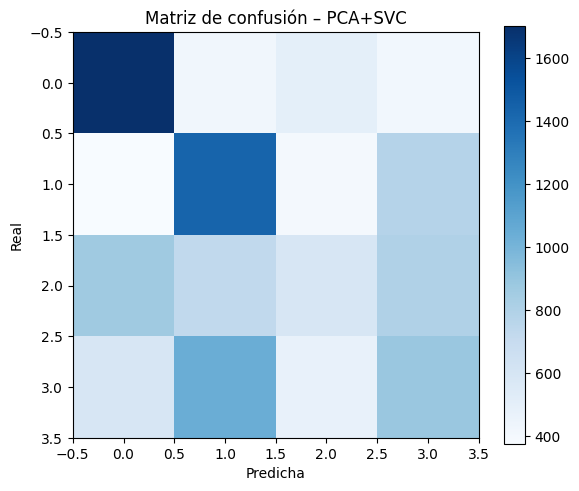

In [30]:
# PCA + SVC en Pipeline

import numpy as np, pandas as pd, matplotlib.pyplot as plt, tempfile
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# 1) Carga
z = pd.read_csv("train.csv")
y_raw = z["RENDIMIENTO_GLOBAL"]
X_raw = z.drop(columns=["ID","RENDIMIENTO_GLOBAL"], errors="ignore")

# 2) y → numérica estable
if not np.issubdtype(y_raw.dtype, np.number):
    le_y = LabelEncoder().fit(y_raw.astype(str).str.strip())
    y = le_y.transform(y_raw.astype(str).str.strip())
else:
    le_y = None
    y = y_raw.to_numpy()

# 3) Preprocesamiento consistente (sin perder columnas)
num_sel = selector(dtype_include=np.number)
cat_sel = selector(dtype_exclude=np.number)

pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="constant", fill_value=-1), num_sel),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ]), cat_sel),
], remainder="drop")

# 4) Submuestra estratificada para velocidad (ajusta N_TARGET si quieres)
N_TARGET = min(60_000, len(X_raw))
sss = StratifiedShuffleSplit(n_splits=1, train_size=N_TARGET, random_state=42)
idx, _ = next(sss.split(X_raw, y))
X = X_raw.iloc[idx]
y = y[idx]

# 5) Holdout
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 6) Pipeline: Pre → Escalado → PCA(0.95 varianza) → SVC RBF
pipe = Pipeline([
    ("pre", pre),
    ("sc",  StandardScaler(with_mean=True)),
    ("pca", PCA(n_components=0.95, random_state=42)),  # fracción de varianza => jamás fuera de rango
    ("svc", SVC(kernel="rbf", C=2.0, gamma="scale", class_weight="balanced")),  # sólido en clases desbalanceadas
], memory=tempfile.mkdtemp())

pipe.fit(X_tr, y_tr)
pred = pipe.predict(X_te)

acc = accuracy_score(y_te, pred)
cm  = confusion_matrix(y_te, pred)

print(f"Accuracy holdout: {acc:.4f}")
print("Matriz de confusión:\n", cm)

# (Plot sencillo para no cargar seaborn)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de confusión – PCA+SVC")
plt.xlabel("Predicha"); plt.ylabel("Real")
plt.colorbar(); plt.tight_layout(); plt.show()

Se buscan los mejores hiperparámetros para PCA, se aplica PCA para reducir la dimensionalidad, se utiliza SVM para la clasificación y se evalúa el modelo en el conjunto de prueba.

/usr/local/lib/python3.12/dist-packages/sklearn/experimental/enable_hist_gradient_boosting.py:19: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


Accuracy holdout: 0.4055
Matriz de confusión:
 [[622  96 184 113]
 [118 469 144 268]
 [289 214 255 233]
 [155 356 208 276]]


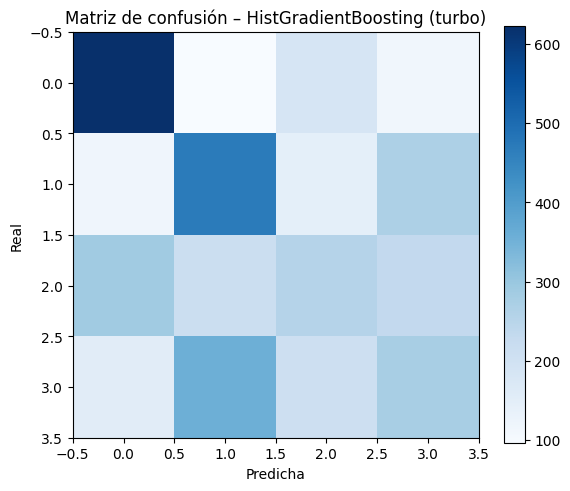

Tiempo total: 22.8 s


In [1]:
# Modo turbo: HGB + Pipeline + submuestreo estratificado
import numpy as np, pandas as pd, matplotlib.pyplot as plt, tempfile, time
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_hist_gradient_boosting  # no-op en versiones nuevas
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

t0 = time.time()

# 1) Carga
z = pd.read_csv("train.csv")
y_raw = z["RENDIMIENTO_GLOBAL"]
X_raw = z.drop(columns=["ID","RENDIMIENTO_GLOBAL"], errors="ignore")

# 2) y → numérica estable
if not np.issubdtype(y_raw.dtype, np.number):
    le_y = LabelEncoder().fit(y_raw.astype(str).str.strip())
    y = le_y.transform(y_raw.astype(str).str.strip())
else:
    le_y = None
    y = y_raw.to_numpy()

# 3) Submuestra estratificada para acelerar
N_TARGET = min(20_000, len(X_raw))  # súbelo a 50k si Colab va fluido
sss = StratifiedShuffleSplit(n_splits=1, train_size=N_TARGET, random_state=42)
idx, _ = next(sss.split(X_raw, y))
X = X_raw.iloc[idx].copy()
y = y[idx]

# 4) Reducir memoria (opcional)
for c in X.select_dtypes(include=["float64"]).columns:
    X[c] = X[c].astype("float32")

# 5) Split holdout
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 6) Preprocesamiento: num→impute(-1), cat→impute("MISSING") + OrdinalEncoder(unknown=-1)
num_sel = selector(dtype_include=np.number)
cat_sel = selector(dtype_exclude=np.number)

pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="constant", fill_value=-1), num_sel),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ]), cat_sel),
], remainder="drop", n_jobs=-1)

# 7) Modelo rápido con early stopping interno
hgb = HistGradientBoostingClassifier(
    max_depth=6, learning_rate=0.1, max_iter=300,  # max_iter alto, pero con early_stopping
    early_stopping=True, validation_fraction=0.1,
    random_state=42
)

pipe = Pipeline([
    ("pre", pre),
    ("clf", hgb)
], memory=tempfile.mkdtemp())

pipe.fit(X_tr, y_tr)
y_pred = pipe.predict(X_te)

acc = accuracy_score(y_te, y_pred)
cm  = confusion_matrix(y_te, y_pred)

print(f"Accuracy holdout: {acc:.4f}")
print("Matriz de confusión:\n", cm)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de confusión – HistGradientBoosting (turbo)")
plt.xlabel("Predicha"); plt.ylabel("Real")
plt.colorbar(); plt.tight_layout(); plt.show()

print(f"Tiempo total: {time.time()-t0:.1f} s")

In [3]:
# Unsupervised (MiniBatchKMeans) + Supervised (Linear SVC) sin fugas ni NameError
import numpy as np, pandas as pd, time
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.cluster import MiniBatchKMeans
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix

t0 = time.time()

# 1) Carga
z = pd.read_csv("train.csv")
X_raw = z.drop(columns=["ID","RENDIMIENTO_GLOBAL"], errors="ignore")

# 2) Partición antes de cualquier aprendizaje (evita leakage)
X_train_raw, X_test_raw = train_test_split(X_raw, test_size=0.2, random_state=42)

# 3) Preprocesamiento robusto (num: impute=-1; cat: impute "MISSING" + OrdinalEncoder(unknown=-1))
num_sel = selector(dtype_include=np.number)
cat_sel = selector(dtype_exclude=np.number)

pre = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="constant", fill_value=-1), num_sel),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value="MISSING")),
            ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]), cat_sel),
    ],
    remainder="drop",
    n_jobs=-1
)

# 4) Ajusta preprocesamiento en TRAIN y transforma ambos (sin tocar pandas a mano)
X_train = pre.fit_transform(X_train_raw)
X_test  = pre.transform(X_test_raw)

# (Opcional) bajar precisión para ahorrar RAM/CPU
X_train = X_train.astype(np.float32, copy=False)
X_test  = X_test.astype(np.float32,  copy=False)

# 5) Unsupervised: clústeres SOLO con train (MiniBatchKMeans es mucho más rápido que KMeans)
k = 3
km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048, n_init="auto")
km.fit(X_train)
y_train_cluster = km.labels_
y_test_cluster  = km.predict(X_test)  # etiquetas "teacher" para el test (sin fuga)

# 6) Supervised: el SVC aprende a replicar las etiquetas de clúster
clf = LinearSVC(C=1.0, class_weight="balanced", random_state=42)
clf.fit(X_train, y_train_cluster)
y_pred = clf.predict(X_test)

# 7) Métrica: qué tan bien el SVC imita al KMeans en test
acc = accuracy_score(y_test_cluster, y_pred)
print(f"Exactitud (SVC ≈ KMeans) en test: {acc:.4f}")
print("Matriz de confusión:\n", confusion_matrix(y_test_cluster, y_pred))
print(f"Tiempo total: {time.time()-t0:.1f} s")

Exactitud (SVC ≈ KMeans) en test: 0.9941
Matriz de confusión:
 [[58218     0     0]
 [    0 37894     0]
 [  552   272 41564]]
Tiempo total: 32.8 s
